## This is the notebook for all of our models and evaluations


These are the helper functions for modeling

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

data = pd.read_csv("./feeds.csv")
data_5 = pd.read_csv("./feeds_5.csv")
data_30 = pd.read_csv("./feeds_30.csv")


def pickfield(data, field_nr):
    field = data[data[field_nr]>10]
    return field

#Start and end are the entry ids for the starting and end points of the cycle
def select_range(data, field_nr, start, end):
    field = pickfield(data, field_nr)
    field = field[field["entry_id"] > start]
    field = field[field["entry_id"] < end]
    return field

## Models

Below are our models, which try to predict when a plant should be watered. They work by looking through a watering cycle point by point, almost simulating how the points would actually be flowing in one by one. The approaches presented here usually revolve around analysing the residuals of a linear regression fit for the weight curve, but there are a few more mathematical approaches as well

**This model is where we did a lot of testing of different hyperparameters, which we have commented out. The approach is looking at the mean of the residuals and waiting for a big rise in it, comparing it to the previously found highest residual**

35273 HERE 1472 545.6


35275

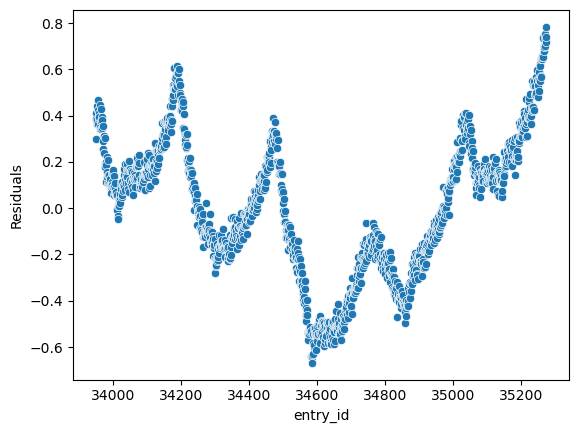

In [ ]:


import statsmodels.api as sm
import statsmodels.formula.api as smf
data_5 = pd.read_csv("feeds_5.csv")

def model_avg_residual(data, lower_bound, upper_bound, field_nr):
    broken = False
    lower = lower_bound

    #THIS MEANS THAT START RUNNING THE MODEL AFTER ONE DAY AFTER THE WATERING
    upperlimit = lower + 288
    upper = upper_bound

    field = select_range(data, field_nr, lower, upper)

    #For-loop for finding the EARLIEST point, where the plant should be watered
    for i in range(upper-upperlimit):
        current_field = field[field["entry_id"] < upperlimit].copy()
        x = current_field["entry_id"]
        y = current_field[field_nr]


        x = sm.add_constant(x)
        model = sm.GLS(y, x)
        results = model.fit()
        # model_lad = smf.quantreg('field7 ~ entry_id', data=data).fit(q=0.5)

        current_field["Residuals"] = results.resid

        poolindeks = len(current_field.index)//2
        half_max = current_field[current_field["entry_id"]<(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].max()
        #sh_min = current_field[current_field["entry_id"]>(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].min()

        half_max_index = current_field[current_field["Residuals"] == half_max]["entry_id"].iloc[0].item()

        #This is the arbitrary coefficient by which the highest residual value is multiplied with
        half_max *= 0.25

        # FAILED DOUBLE RESIDUAL APPROACH
        # current_field = current_field[current_field["entry_id"] > half_max_index]
        # poolindeks = len(current_field.index)//2
        # x = current_field["entry_id"]
        # y = current_field["field6"]
        # x = sm.add_constant(x)
        # model = sm.OLS(y, x)
        # results = model.fit()
        # current_field["Residuals"] = results.resid

        #x basically shows how far along the residuals list you are
        x = 0
        #Sum of residuals
        residsum = 0
        #Amount of points with higher than 0 residual
        count = 0

        resids = current_field[current_field["entry_id"]>(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"]
        #already_resids = []
        resids_max = resids.max()
        for resid in resids:

            #FAILED APPROACH OF LOOKING AT POINTS STARTING AT PREVIOUS MINIMUM-POINT, NOT RESIDUAL = 0
            # if resid == resids_max and resid-sh_min > 2*half_max:
            #     resid = resid -sh_min
            #     broken = True
            #     print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "SIIN", upper-upperlimit, current_field[field_nr].iloc[-1])
            #     break
            # elif len(already_resids) >= 5 and resids_max in already_resids[-5:]:
            #     resid = resid -sh_min

            if resid >= 0:
                #already_resids.append(resid)
                residsum += resid
                count += 1

                #IF THE MEAN IS OVER THE THRESHOLD AND THERE ARE ENOUGH POINTS AND THIS WAS NOT REPORTED TOO LATE:
                if residsum/count >= half_max and count >= 288 and (upperlimit - (x + int(current_field["entry_id"].iloc[0])+poolindeks)) <= 10 :
                    broken = True
                    #CONGRATS, YOU SHOULD WATER YOUR PLANT HERE. THE FIRST NUMBER IS THE INDEX
                    #UPPER- UPPERLIMIT IS HOW MUCH FURTHER ALONG THE PLANT WAS ACTUALLY WATEREED
                    #THE THIRD VALUE IS WHAT THE MASS OF THE POT WAS WHEN THE MODEL PREDICTED THAT THE PLANT SHOULD BE WATERED
                    print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "HERE", upper-upperlimit, current_field[field_nr].iloc[-1])
                    break
            else:
                residsum = 0
                count = 0
            x += 1
        if broken:

            break
        upperlimit += 1
    #PLOT CORRESPONDING SECTION
    sns.scatterplot(data = current_field, x="entry_id", y="Residuals")
    if upperlimit != upper:
        #RETURNS INDEX FOR WATERING
        return upperlimit

model_avg_residual(data_5, 33947, 36747, "field7")


**This approach is looking at points, where the residuals cross Residual = 0, and analysing the regions found near those points. This approach still uses the mean of the residuals**


35369 HERE 268 503.09


36479

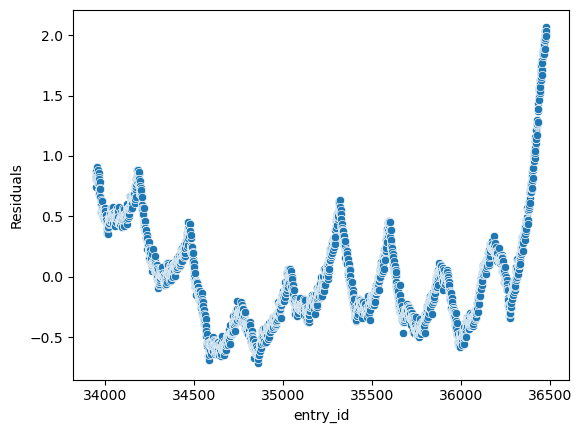

In [ ]:
def model_zero_points(data, lower_bound, upper_bound, field_nr):

    broken = False
    lower = lower_bound
    upperlimit = lower + 288
    upper = upper_bound

    field = select_range(data, field_nr, lower, upper)

    for i in range(upper-upperlimit):

        current_field = field[field["entry_id"] < upperlimit].copy()

        x = current_field["entry_id"]
        y = current_field[field_nr]
        x = sm.add_constant(x)
        model = sm.OLS(y, x)
        results = model.fit()
        current_field["Residuals"] = results.resid

        poolindeks = len(current_field.index)//2
        half_max = current_field[current_field["entry_id"]<(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].max()
        half_max_index = current_field[current_field["Residuals"] == half_max]["entry_id"].iloc[0].item()


        positive_current = current_field['Residuals'] > 0

        negative_previous = current_field['Residuals'].shift(1) < 0

        transition_points = current_field[positive_current & negative_previous]

        last_transition_index = transition_points["entry_id"].max()


        x = 0
        residsum = 0
        count = 0

        resids = current_field[current_field["entry_id"]>last_transition_index]["Residuals"]
        for resid in resids:

            if resid >= 0:
                residsum += resid
                count += 1


                #Ended up still looking at the mean of the residuals
                if upperlimit-last_transition_index > 144 and residsum/count >half_max:
                    broken = True
                    #WATER THE PLANT HERE
                    print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "HERE", upper-upperlimit, current_field[field_nr].iloc[-1])
                    break
            else:
                residsum = 0
                count = 0
            x += 1
        if broken:
            break
        upperlimit += 1

    sns.scatterplot(data = current_field, x="entry_id", y="Residuals")
    if upperlimit != upper:
        return upperlimit

model_zero_points(data_5, 33947, 36747, "field7")

**The next model still uses residuals, but it uses a cumulative sum approach instead of looking at the mean**

36400 HERE 347 504.88


36400

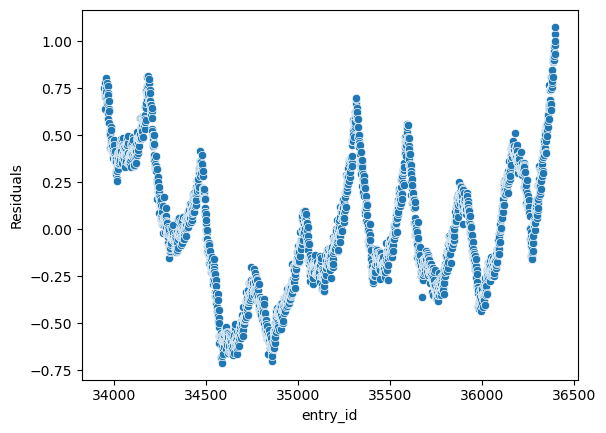

In [ ]:
data_5 = pd.read_csv("feeds_5.csv")

def model_cusum(data, lower_bound, upper_bound, field_nr):

    #SMALL DRIFT SHOULD HELP WITH ACCURACY
    drift = 0.05
    #ARBITRARY THRESHOLD
    threshold = 85
    broken = False
    lower = lower_bound
    upperlimit = lower + 576
    upper = upper_bound

    field = select_range(data, field_nr, lower, upper)
    cusums = []
    for i in range(upper-upperlimit):


        current_field = field[field["entry_id"] < upperlimit].copy()

        x = current_field["entry_id"]
        y = current_field[field_nr]
        x = sm.add_constant(x)
        model = sm.OLS(y, x)
        results = model.fit()
        current_field["Residuals"] = results.resid

        cusum = 0
        resids = current_field[current_field["entry_id"]>upperlimit-288]["Residuals"]
        for resid in resids:

            if resid-drift >= 0:
                cusum += (resid-drift)
                if cusum > threshold :
                    broken = True
                    #WATER THE PLANT HERE!!
                    print( upperlimit, "HERE", upper-upperlimit, current_field[field_nr].iloc[-1])
                    break

        if broken:
            break
        upperlimit += 1
    sns.scatterplot(data = current_field, x="entry_id", y="Residuals")
    if upperlimit != upper:
        return upperlimit

model_cusum(data_5, 33947, 36747, "field7")

**This model's goal is to deduce when the plant should be watered by looking at the mean of absolute changes in water loss. It is a very mathematical model, however it is severely influenced by noise**

In [ ]:

#SHIFT AMOUNT IS BASICALLY HOW MANY DATA POINTS SHOULD BE COMBINED INTO ONE
#SHIFT AMOUNT OF 12 MEANS FOR 5-MINUTE GAP DATA LOOKING AT 1 HOUR OF CHANGE AT A TIME
def model_Difference(data, field_nr, lower, upper, shift_amount):
    field = select_range(data, field_nr, lower, upper)
    field[field_nr] = (field[field_nr].shift(-shift_amount) - field[field_nr])
    field = field[field["entry_id"] % shift_amount == 0].copy()

    #DO NOT LOOK AT THE FIRST TWO DAYS OF DATA
    upperlimit = lower + 576


    #INSTEAD OF LOOKING AT THE FIRST AND LAST MEAN, LOOK AT THE TOTAL FOUND HIGHEST MEAN AND LOWEST MEAN
    min_mean = 0
    max_mean = -10000
    for i in range(shift_amount, (upper-upperlimit), shift_amount):

        current_field = field[field["entry_id"] < (upperlimit)].copy()

        #ARBITRARY VALUE FOR HOW MANY DATA POINTS THE MEAN SHOULD BE TAKEN. IN OUR EXAMPLE IT IS 10 POINTS
        range_length = 120 // shift_amount


        #THE MEAN OF THE FIRST 10 POINTS
        original_mean = 0

        for diff in current_field[field_nr].iloc[:range_length]:
            original_mean += diff
        original_mean /= range_length


        #THE MEAN OF THE LAST 10 RESIDUALS
        last_mean = 0

        for diff in current_field[field_nr].iloc[-range_length:]:
            last_mean += diff
        last_mean /= range_length

        if last_mean <original_mean and last_mean <min_mean:
            min_mean = last_mean
        elif original_mean <min_mean:
            min_mean = original_mean

        if last_mean > max_mean:
            max_mean = last_mean

        #THE 7/4 IS AN ARBITRARY VALUE THERE, BUT IT SEEMED TO BE THE BEST PERFORMING VALUE. BASICALLY WAIT UNTIL THE MEAN FALLS TO 4/7 OF THE ORIGINAL
        if max_mean * (7/4) > min_mean:

            print(upperlimit, "HERE", upper-upperlimit)
            break

        upperlimit += shift_amount

    if upperlimit+1 != upper:
        return upperlimit


model_Difference(data_5, "field7", 33947, 36747, 12)


36443 HERE 304


36443

**DOES NOT WORK! This model's goal is to deduce when the plant should be watered by looking at the absolute changes in water loss and analysing the standard deviation**

In [ ]:


def model_Stdev(data, field_nr, lower, upper, shift_amount):
    field = select_range(data, field_nr, lower, upper)
    field[field_nr] = (field[field_nr].shift(-shift_amount) - field[field_nr])
    field = field[field["entry_id"] % shift_amount == 0].copy()

    upperlimit = lower + 576

    for i in range(shift_amount, (upper-upperlimit), shift_amount):

        current_field = field[field["entry_id"] < (upperlimit)].copy()

        range_length = 120 // shift_amount


        original_stdev = current_field[field_nr].iloc[:range_length].std()

        last_stdev = current_field[field_nr].iloc[-range_length:].std()
        print(last_stdev)

        #THERE IS JUST NO COEFFICIENT, WHICH WOULD MAKE THIS A VALUABLE ESTIMATION OF WHEN TO WATER THE PLANT
        if last_stdev * (0.5) > original_stdev:

            print(upperlimit, "siin", upper-upperlimit, last_stdev)
            break
        if upperlimit + 100 > upper:
            print(original_stdev, last_stdev)

        upperlimit += shift_amount

    if upperlimit+1 != upper:
        return upperlimit


model_Stdev(data_5, "field7", 33947, 36747, 12)

0.11624208455728473
0.117208266678501
0.10754327294421756
0.10791457526930424
0.10852547064065679
0.1028537256927949
0.08089087299152611
0.08708233651741057
0.08390470785360325
0.09510228411792718
0.09527154174605137
0.09786612170604074
0.09730250653390625
0.09689054534773812
0.08643558937795646
0.07677528537523734
0.07248754682322814
0.07026932316297735
0.06802777210655947
0.06703233050802188
0.05834761729878545
0.07408703590297534
0.07299923896102027
0.09585289655392731
0.09368979548370374
0.09374314789774284
0.09695932709704973
0.09663792676217164
0.07435649863254228
0.08233400809441603
0.09240610850421735
0.08862530363529893
0.0865447860937029
0.06815016100089656
0.07020604595682876
0.07020604595682842
0.060818491340134936
0.060818491340141376
0.054822947344668346
0.05425249610233934
0.04881939505292099
0.04880801391392587
0.05249338582673857
0.05087020520675551
0.051908038341325034
0.08316649966583432
0.0908295106229235
0.09077444574328017
0.07888810641238106
0.07820912137765818
0

36743

## Evaluation

This is the section for how we evaluated our models. We basically just tested our models on a bunch of fields and cycles and ended up plotting the points, where the plants should be watered, based on our models. We also ended up sending a few of our results to Click & Grow, but they ended up being quite a bit worse than their model...
If the chart does not have a red dot, then that means, that the model did not have enough data yet to predict that the plant should be watered

[(1444, 3375), (4207, 5383), (5383, 7349), (7349, 9570), (9570, 11273), (11273, 14073), (14073, 16053), (16053, 18070), (18070, 21122), (21122, 23122)]
24118 26049
25762 HERE 287
26881 28057
27961 HERE 96
28057 30023
29389 HERE 634
30023 32244
32244 33947
33947 36747
36443 HERE 304
36747 38727
38691 HERE 36
38727 40744
40744 43796
42868 HERE 928
43796 45796


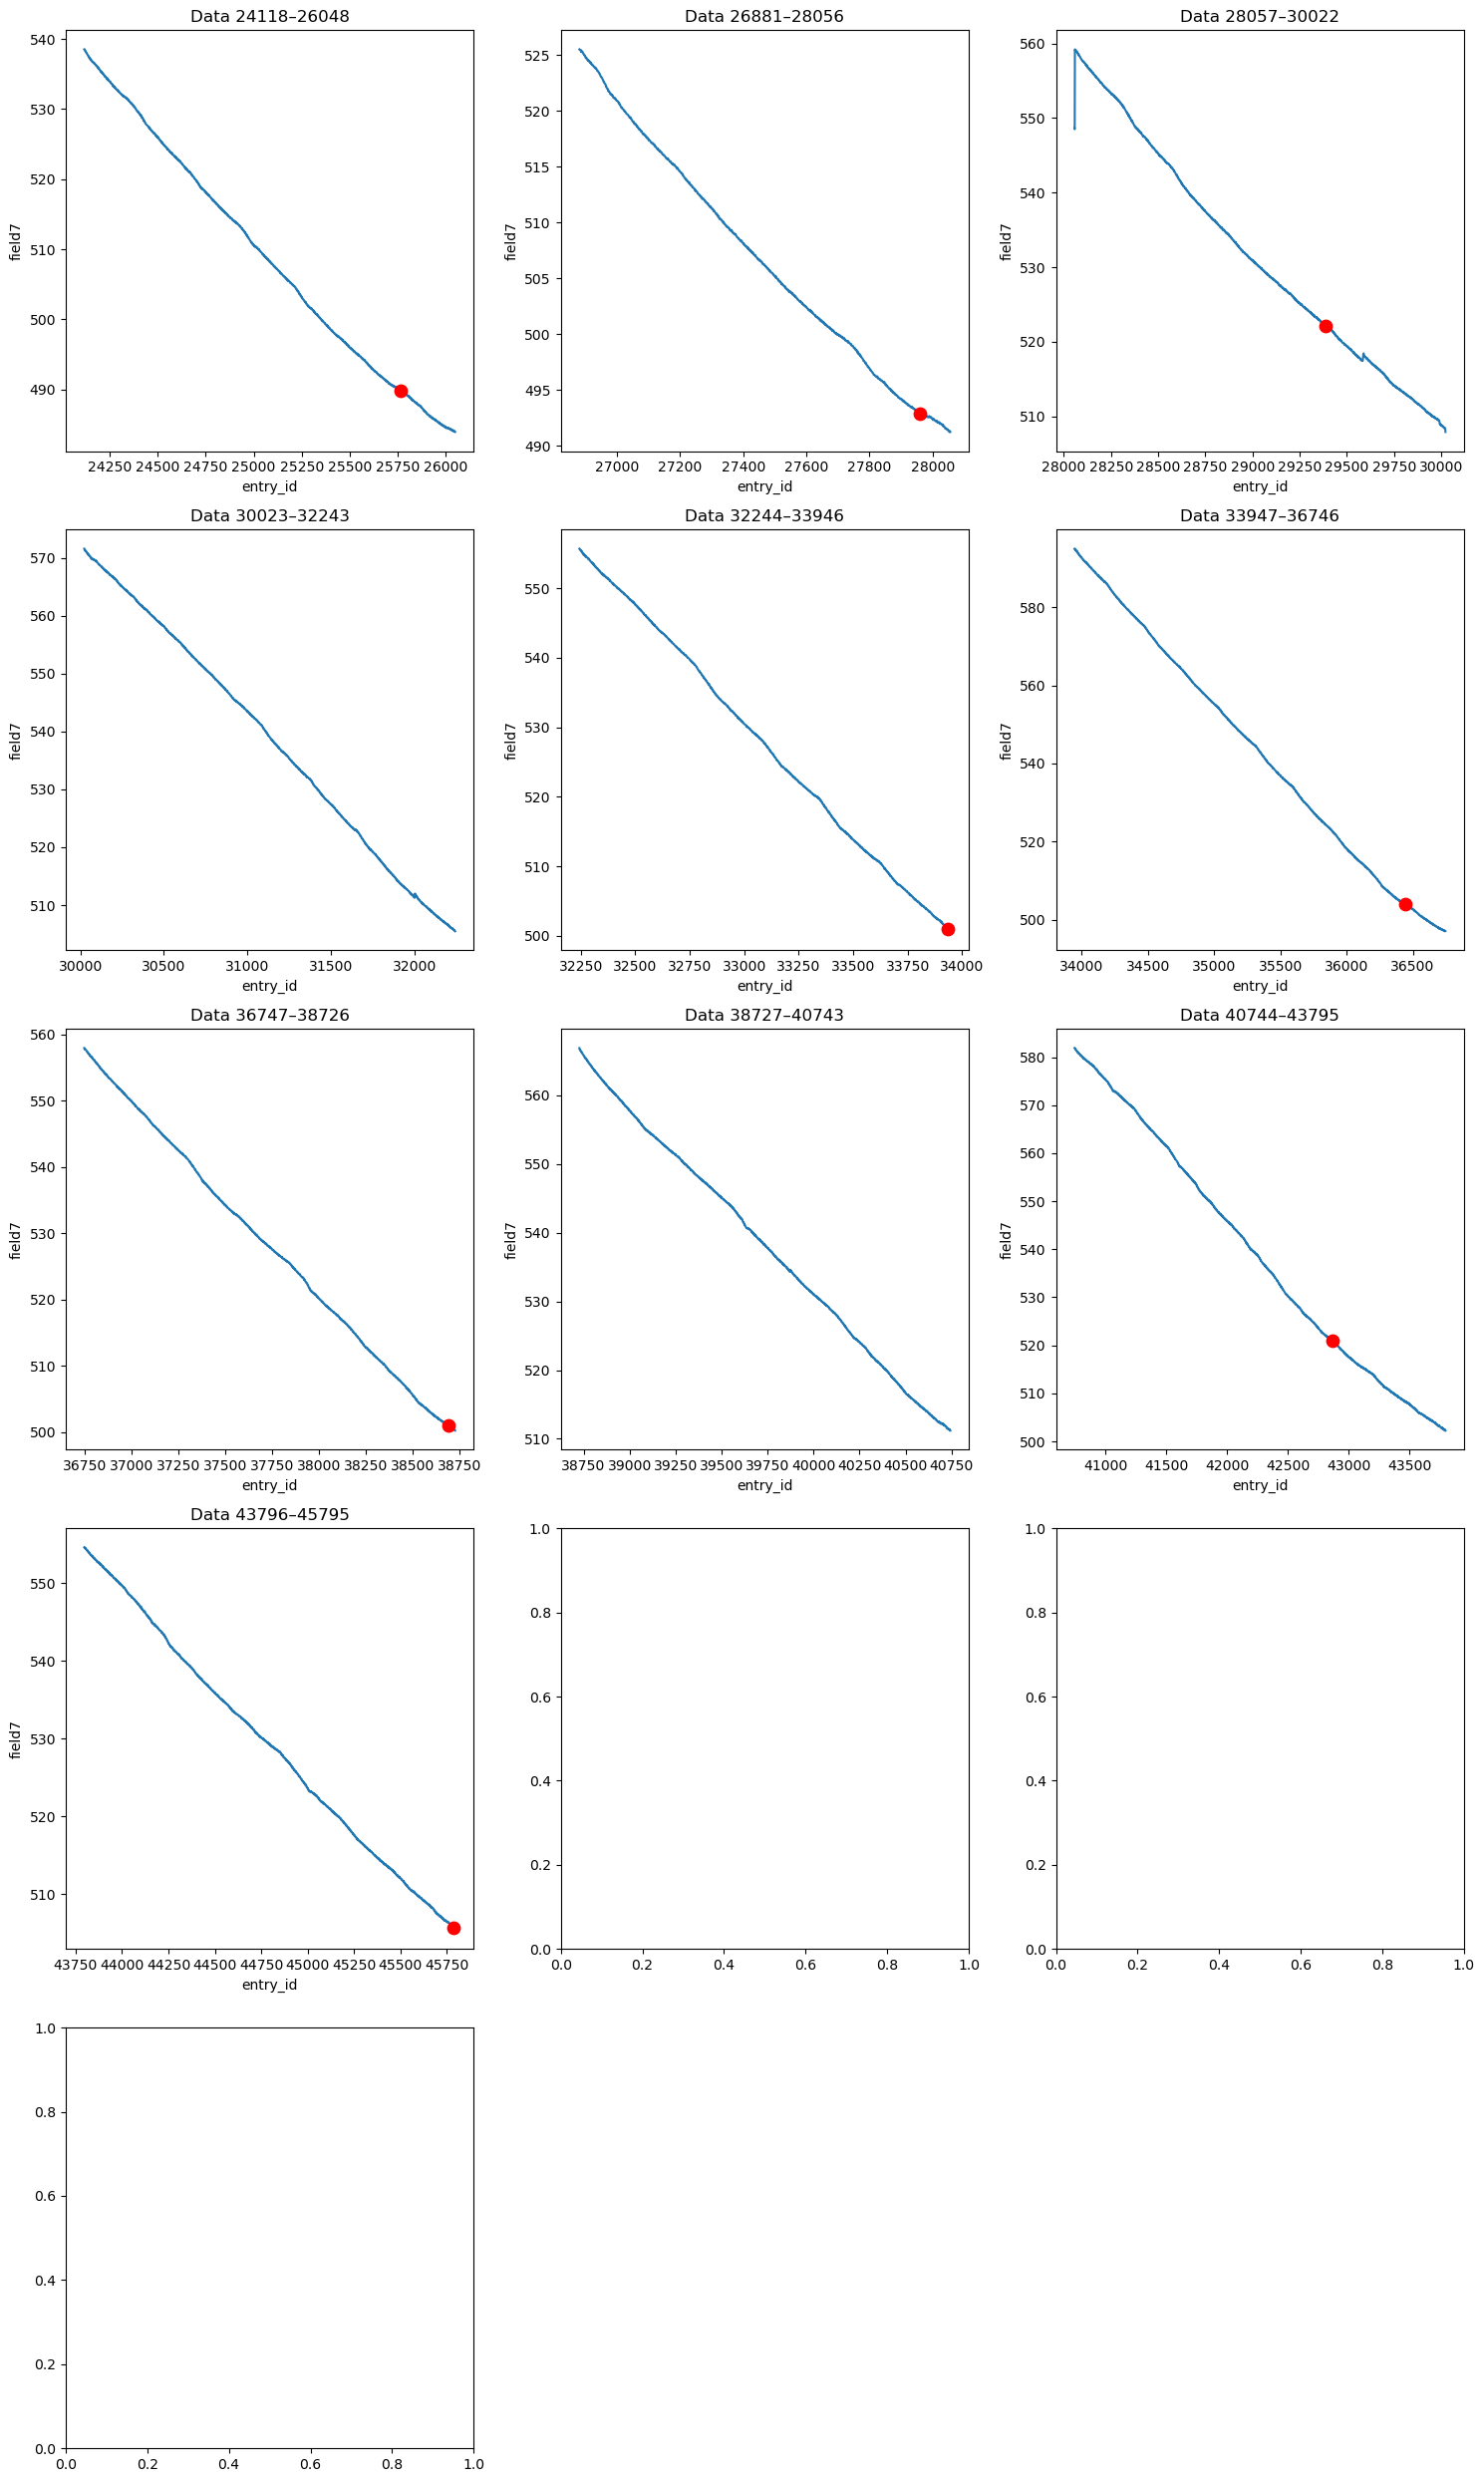

In [ ]:

data = data_5

size = data.shape[0]
jump_val = 10
min_chunk_size = 5
jump_points = []

field = "field7"

# Find jump points
for i in range(size - 1):
    loc = data[field].iloc[i]
    nxt = data[field].iloc[i + 1]
    if abs(loc - nxt) > jump_val:
      if len(jump_points) == 0:
        jump_points.append(i + 1)
      elif i - jump_points[-1] >= min_chunk_size:
        jump_points.append(i + 1)

# Build list of (start, end) segments
segments = list(zip(jump_points[:-1], jump_points[1:]))
long_segments = []

for segment in segments:

    #WE DECIDED TO DISREGARD THE DETECTED SEGMENTS WHICH WERE SHORTER THAN 1000 points
    if segment[1]-segment[0] > 1000:
        long_segments.append(segment)
print(long_segments)

results = []
for segment in long_segments:
    lower_bound = data_5.iloc[segment[0]]["entry_id"]
    upper_bound = data_5.iloc[segment[1]]["entry_id"]


    print(lower_bound, upper_bound)

    # THIS IS WHERE YOU CAN CHOOSE, WHICH MODELS RESULTS TO PLOT

    #results.append(model_zero_points(data_5, lower_bound, upper_bound, field))
    #results.append(model_cusum(data_5, lower_bound, upper_bound, field))
    #results.append(model_avg_residual(data_5, lower_bound, upper_bound, field))
    results.append(model_Difference(data_5, field, lower_bound, upper_bound, 12))
results = list(filter(None, results))


# Determine subplot layout
n = len(segments)
cols = 3 #amount of columns of charts
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # flatten in case of multi-row grid

for ax, (start, end) in zip(axes, long_segments):
    loc_data = data.iloc[start:end]
    min_entry_id = loc_data['entry_id'].min()
    max_entry_id = loc_data['entry_id'].max()

    #Filter the global list down to IDs that are ONLY in this segment
    #We compare the ID value to the MIN/MAX entry_id of the current plot data
    segment_ids_to_highlight = [
    id_val for id_val in results
    if min_entry_id <= id_val <= max_entry_id
    ]

    ax.plot(loc_data["entry_id"], loc_data[field])

    if segment_ids_to_highlight:
        highlight_points = loc_data[loc_data['entry_id'].isin(segment_ids_to_highlight)]
        ax.scatter(
            highlight_points["entry_id"],
            highlight_points[field],
            color='red',
            marker='o',
            s=80, #marker size
            zorder=5 # Plot on top
        )

    ax.set_title(f"Data {min_entry_id}–{max_entry_id}")
    ax.set_xlabel("entry_id")
    ax.set_ylabel(field)

# Hide unused subplots
for ax in axes[len(segments):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Click & Grow's model
Here is our replica of Click & Grow's model according to their explanation of their approach. We were able to test our results against this model, but in the end none of our results exceeded the accuracy of their model.

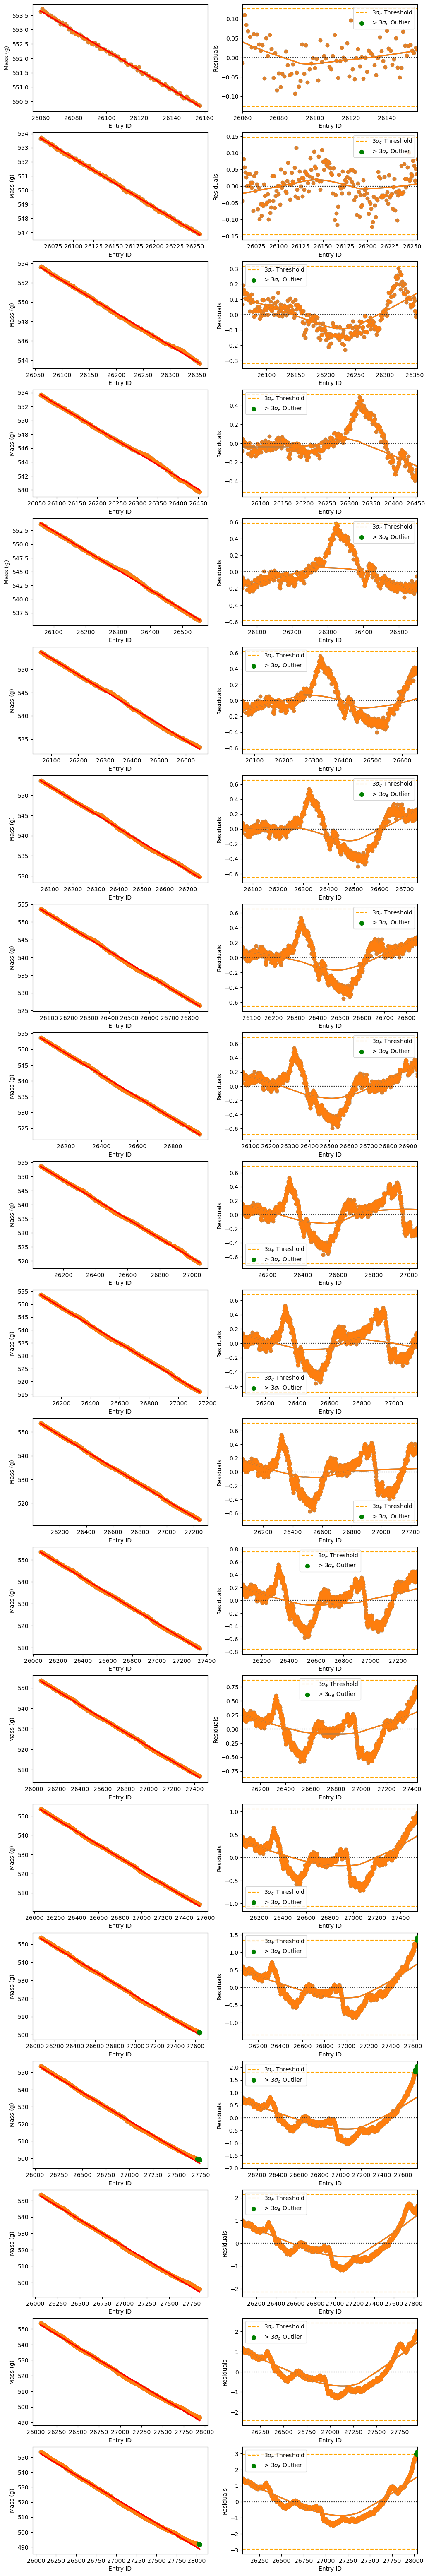

In [ ]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt

lower = 26059 #30023 40744 36747
upper = 28052 #32244 43796 38727
diff = upper-lower
chunks = 20

fig, axs = plt.subplots(chunks, 2, figsize=(12, chunks*4))
for i in range(chunks):
    chunkdiff = diff//chunks
    currentlower = lower + i*chunkdiff
    currentupper = lower + (i+1)*chunkdiff
    field = select_range(data, "field7",lower, currentupper)

    # 1. Fit the OLS Model
    X = sm.add_constant(field['entry_id']) # Adds the intercept
    Y = field['field7']
    model = sm.OLS(Y, X).fit()

    # 2. Get the Residuals
    residuals = model.resid

    # 3. Calculate the Standard Deviation of the Residuals (sigma_e)
    # The 'scale' attribute of the results object is the variance (sigma_e^2)
    # The standard deviation is the square root of the scale.
    sigma_e = np.sqrt(model.scale)

    # 4. Identify Outliers
    threshold = 3 * sigma_e

    # Create a boolean mask for the outliers
    outlier_mask = np.abs(residuals) > threshold

    # Filter the original data and residuals to get only the outliers
    outlier_data = field[outlier_mask]
    outlier_residuals = residuals[outlier_mask]

    # --- Plotting ---

    # Plot 1: Regression Plot (as you have it)
    sns.regplot(x='entry_id', y='field7', data=field, order=1, line_kws=dict(color="r"), ax=axs[i, 0], ci=None)

    # Add a point for the outliers in the REGRESSION plot (axs[i, 0])
    axs[i, 0].scatter(outlier_data['entry_id'], outlier_data['field7'],
                      color='green', marker='o', s=50, zorder=10, label=r'> 3$\sigma_e$ Outlier')


    # Plot 2: Residual Plot
    sns.residplot(x='entry_id', y='field7', data=field, order=1, ax=axs[i, 1], lowess=True)


    # Add points/lines for the outliers and the threshold lines in the RESIDUAL plot (axs[i, 1])
    axs[i, 1].axhline(threshold, color='orange', linestyle='--', label=r'3$\sigma_e$ Threshold')
    axs[i, 1].axhline(-threshold, color='orange', linestyle='--')

    # Add a point for the outliers in the RESIDUAL plot
    axs[i, 1].scatter(outlier_data['entry_id'], outlier_residuals,
                      color='green', marker='o', zorder=10, s=50, label=r'> 3$\sigma_e$ Outlier')

    axs[i, 1].legend() # Display legend for the residual plot

    # Plot regression line and residuals
    sns.regplot(x='entry_id', y='field7', data=field, order = 1, line_kws=dict(color="r"), ax=axs[i,0], ci = None)
    axs[i,0].set_ylabel("Mass (g)")
    axs[i,0].set_xlabel("Entry ID")
    sns.residplot(x='entry_id', y='field7', data=field, order = 1, ax=axs[i, 1], lowess = True)
    axs[i,1].set_ylabel("Residuals")
    axs[i,1].set_xlabel("Entry ID")

Optimal threshold: 0.5003718874839145
Default threshold (0.5):
[[6081 5566]
 [   7    8]]

Custom threshold:
[[6145 5502]
 [   7    8]]


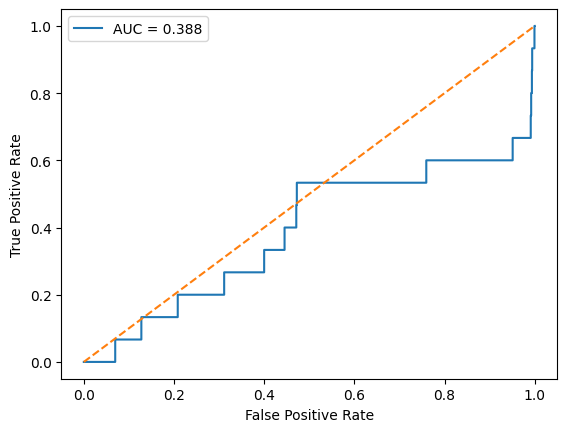

In [1]:
# This code computationally detects suggested watering points and trains a logstic regression model based on them.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

def detect_extremums(df, field="field1", threshold=5, anomaly_drop_ratio=0.5):

    values = df[field].values
    n = len(values)
    is_extremum = np.zeros(n, dtype=bool)

    for i in range(1, n - 1):

        prev_v = values[i - 1]
        curr_v = values[i]
        next_v = values[i + 1]

        # --- 1. Must be higher than both neighbors (local peak) ---
        is_local_peak = curr_v > prev_v and curr_v > next_v

        # --- 2. Must exceed threshold relative to previous point ---
        rises_enough = (curr_v - prev_v) >= threshold

        # --- 3. Anomaly removal —
        # If value immediately collapses, it's a spike not a real extremum
        is_anomaly = next_v < curr_v * anomaly_drop_ratio

        if is_local_peak and rises_enough and not is_anomaly:
            is_extremum[i-1] = True

    df["is_extremum"] = is_extremum
    return df

field = "field1"

data = pd.read_csv("feeds.csv")
data = data[[field]]
data = detect_extremums(data, field, 20)

X = data.drop("is_extremum", axis=1)
y = data["is_extremum"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

LR = LogisticRegression(solver="liblinear", penalty="l1", random_state=5, class_weight="balanced")

LR.fit(X_train, y_train)
y_pred = LR.predict(X_val)
y_pred_proba = LR.predict_proba(X_val)[:,1]

cm = confusion_matrix(y_val, y_pred)

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal threshold:", optimal_threshold)

# Apply the custom threshold
y_pred_custom = (y_pred_proba >= optimal_threshold).astype(int)

# Compare confusion matrices
print("Default threshold (0.5):")
print(confusion_matrix(y_val, y_pred))

print("\nCustom threshold:")
print(confusion_matrix(y_val, y_pred_custom))
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


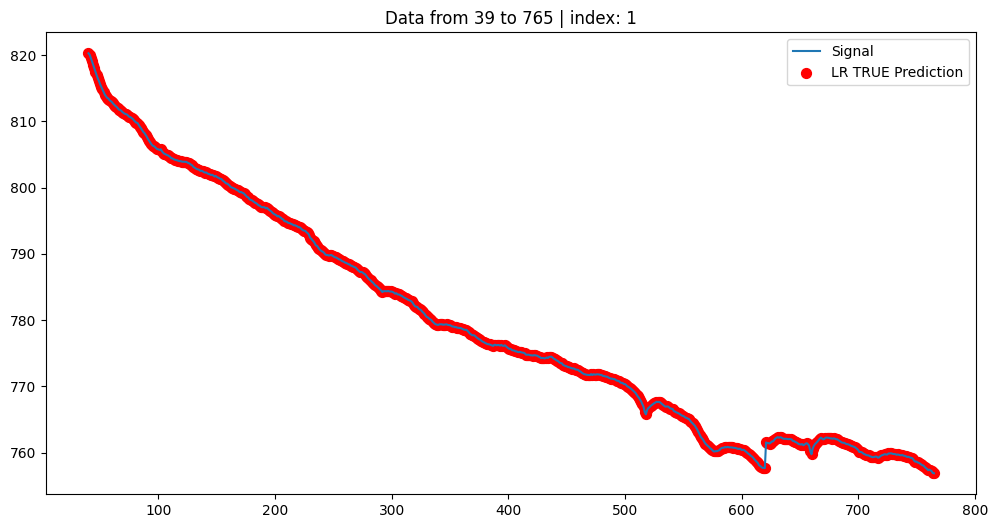

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


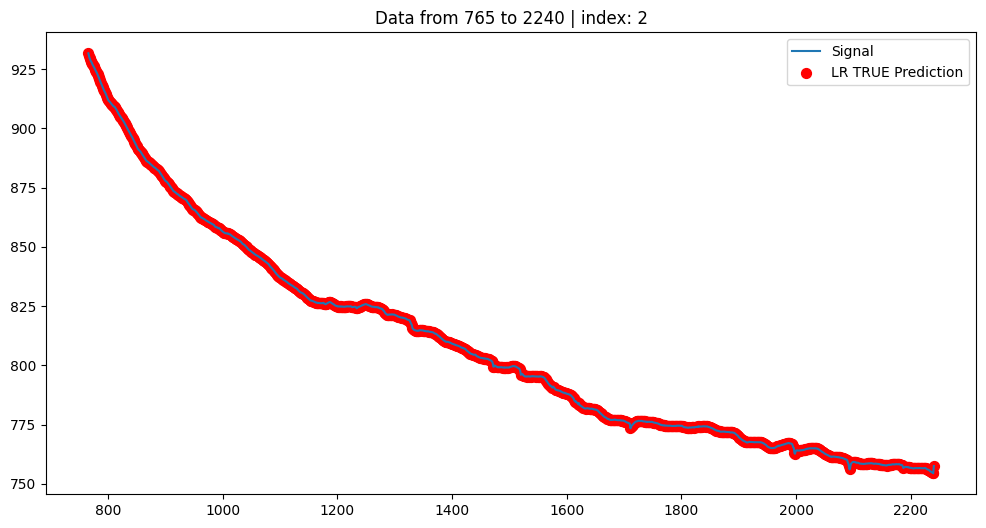

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


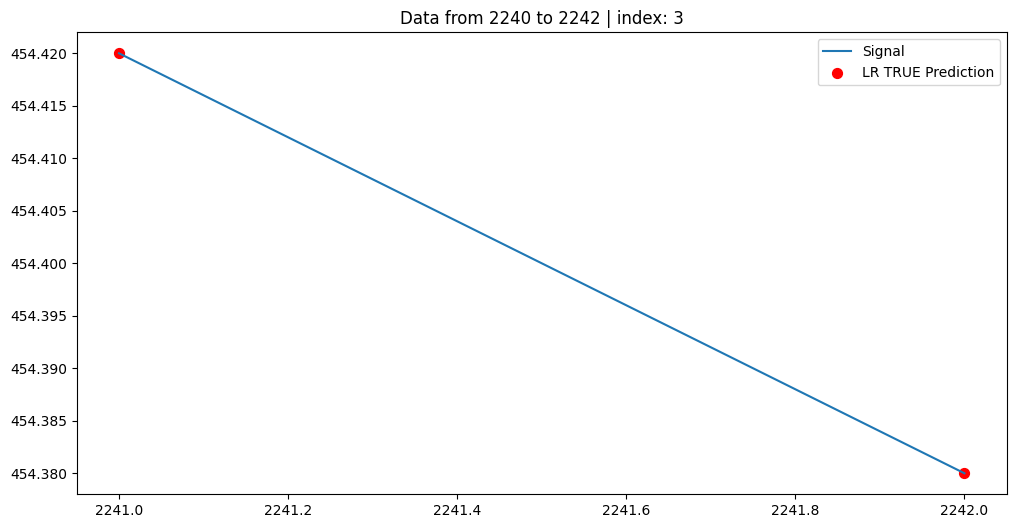

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


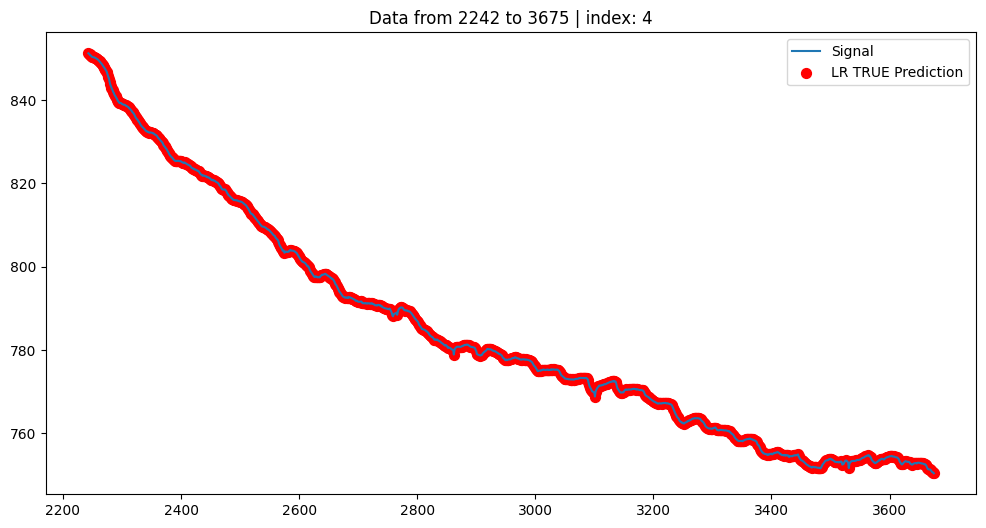

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


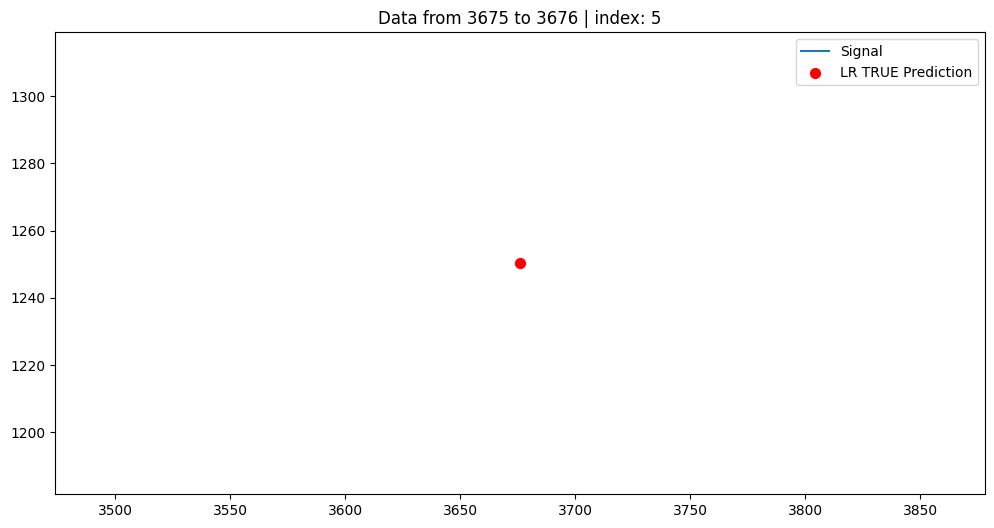

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


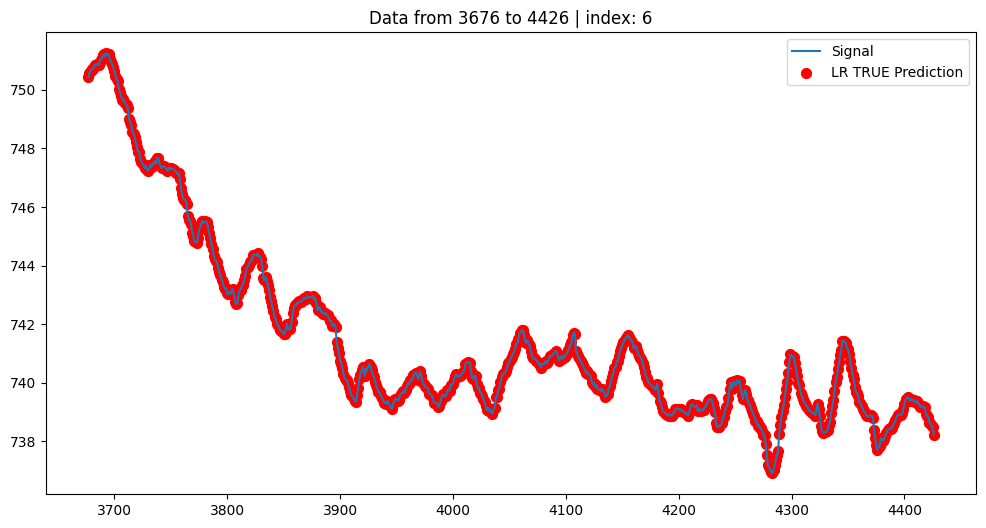

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


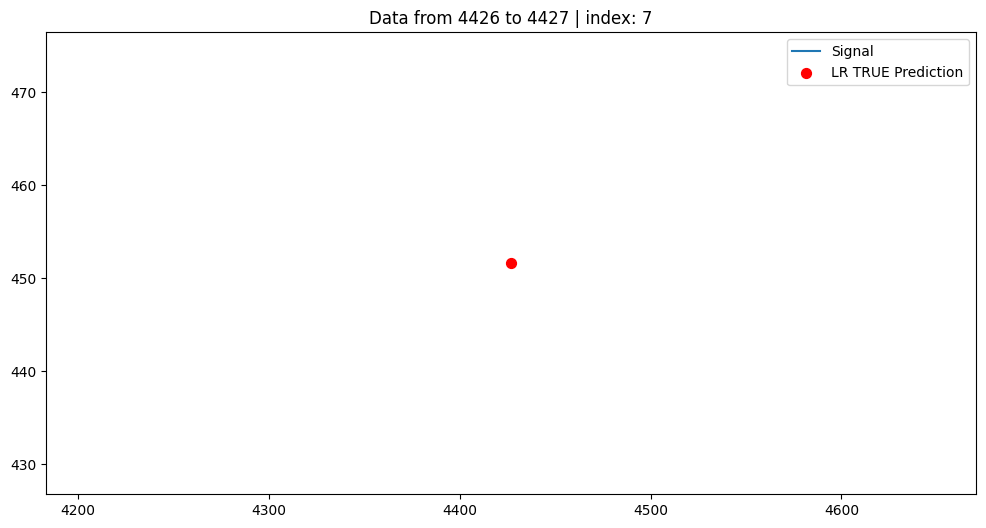

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


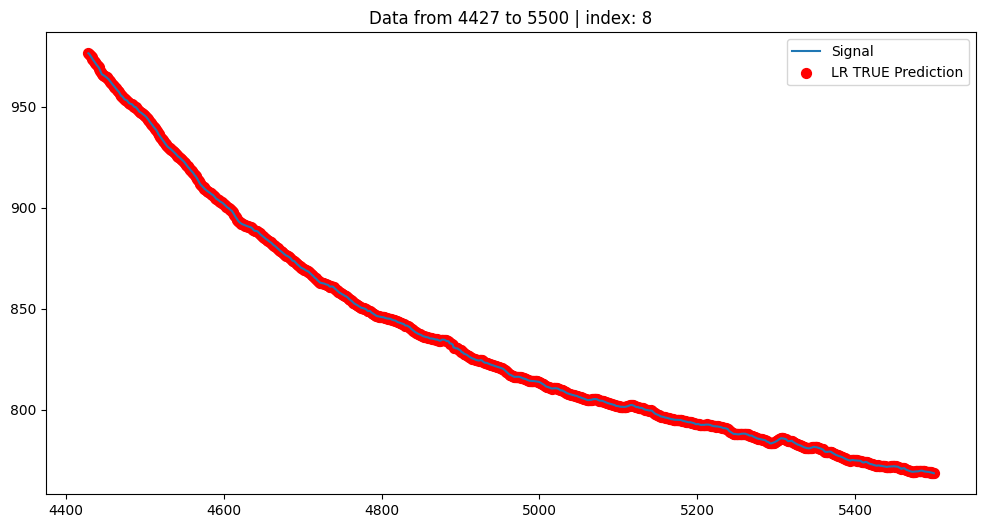

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


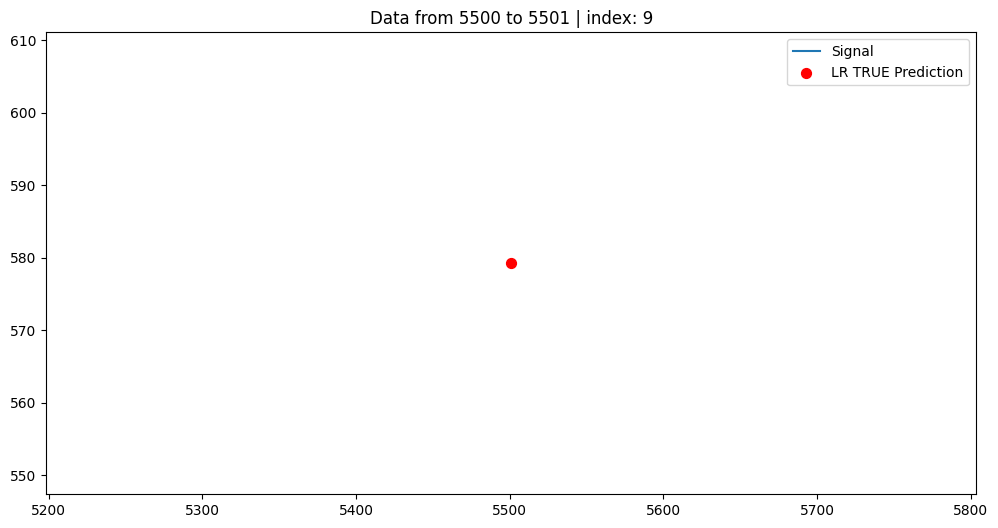

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


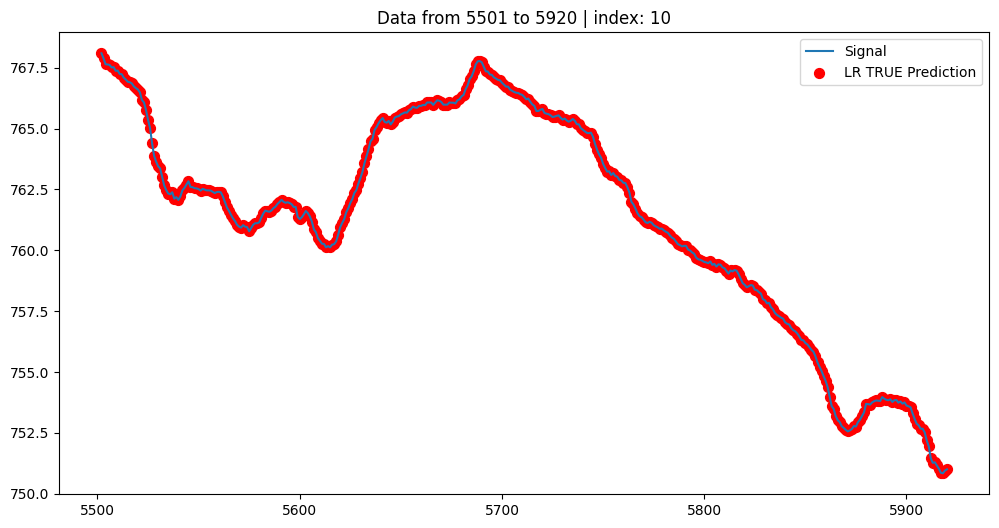

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


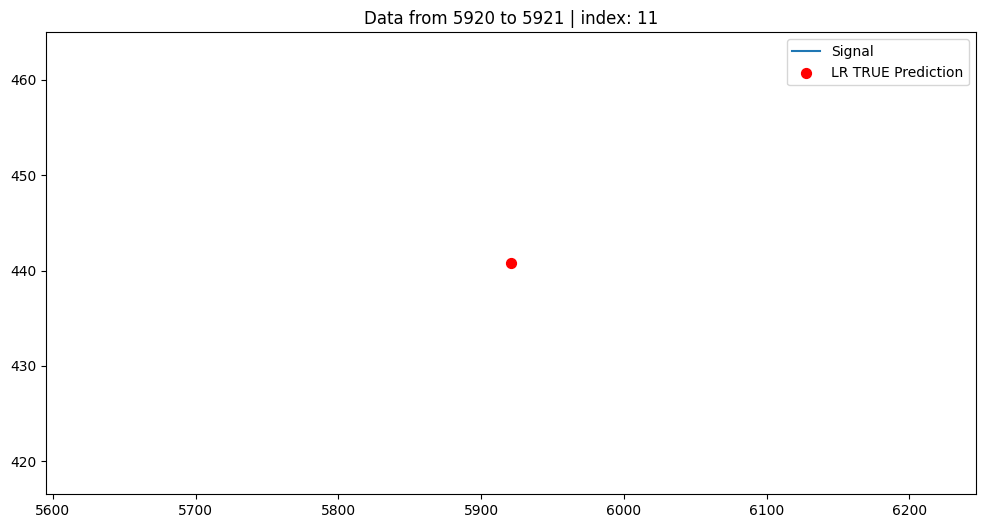

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


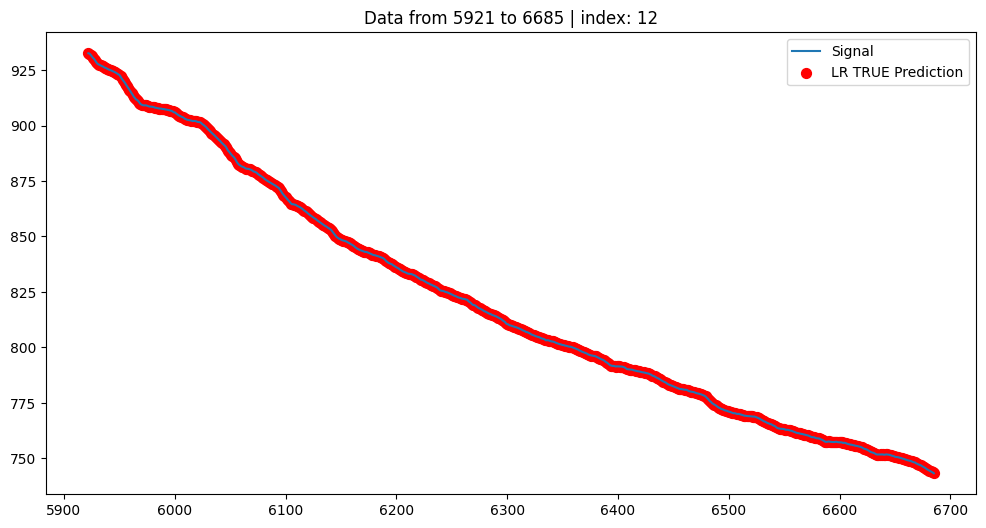

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


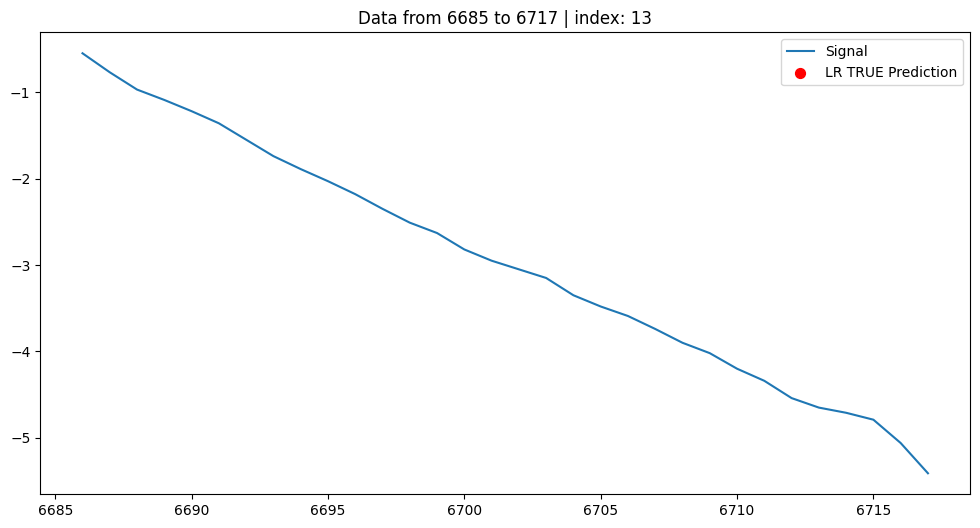

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


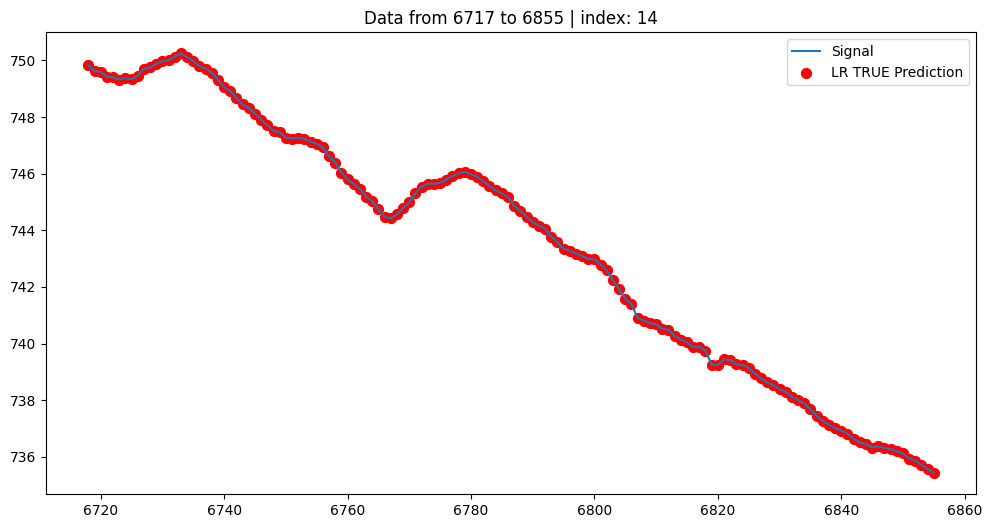

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


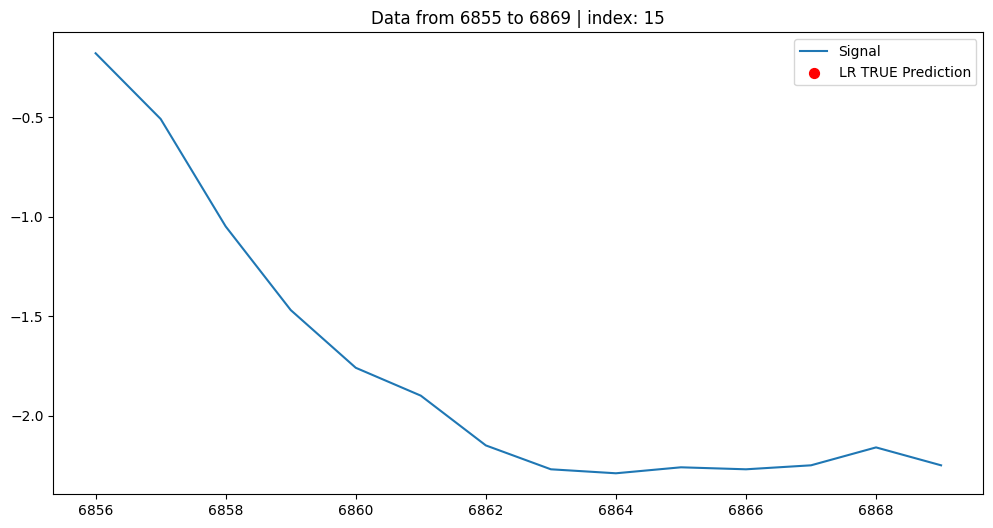

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


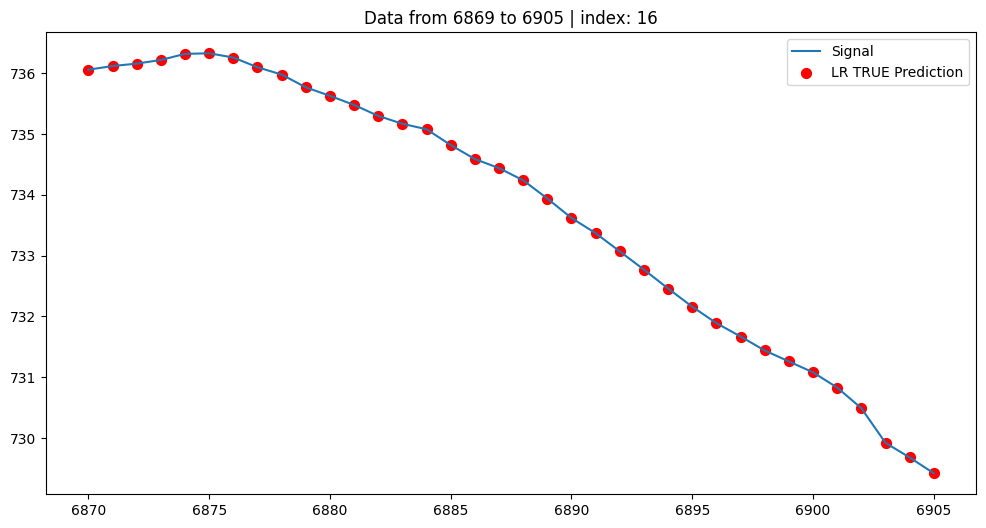

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


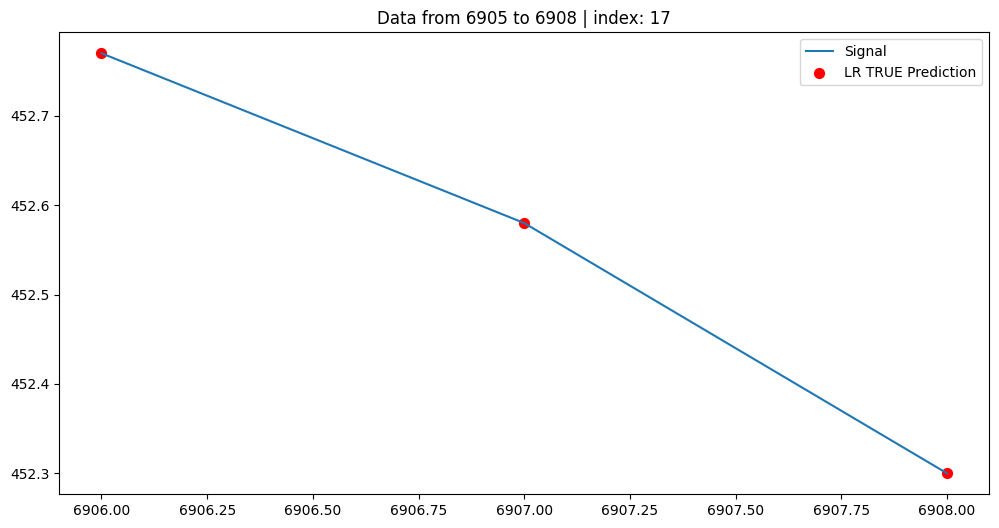

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


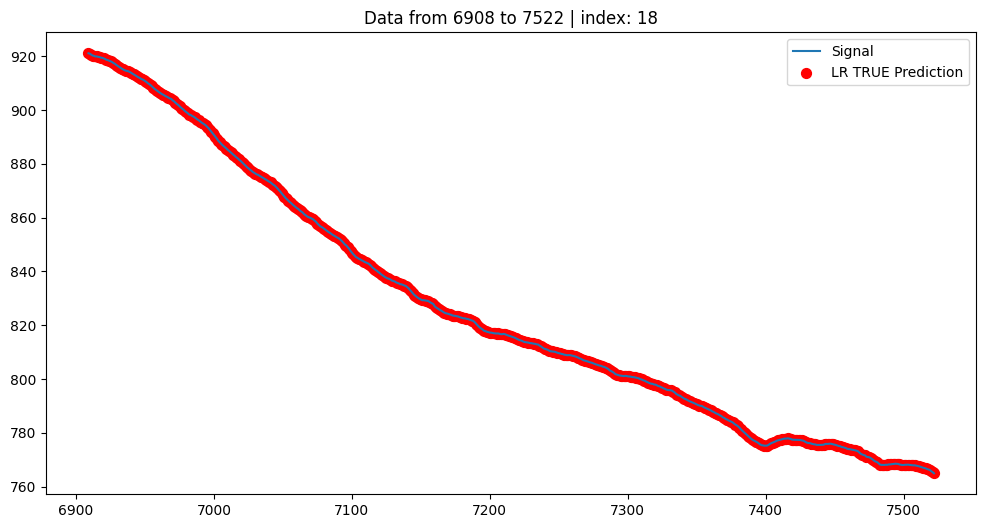

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


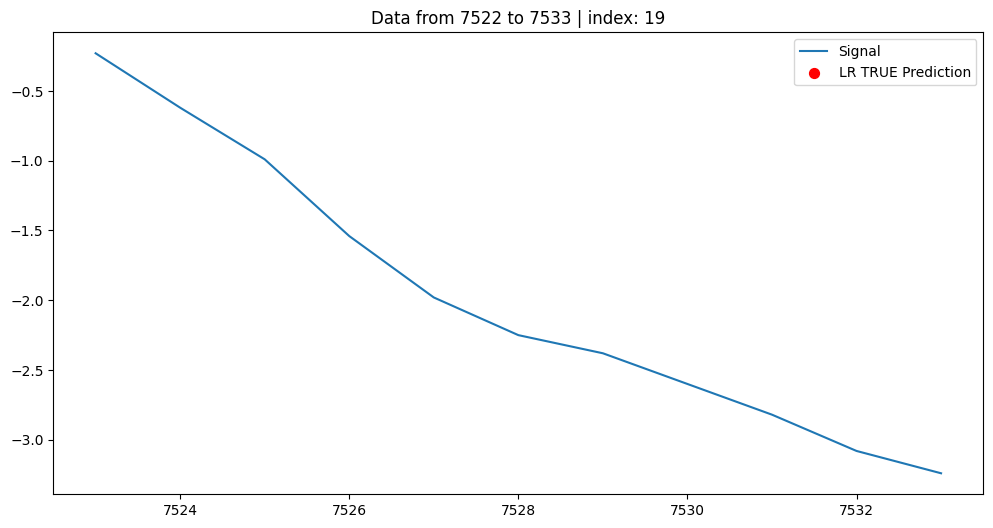

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


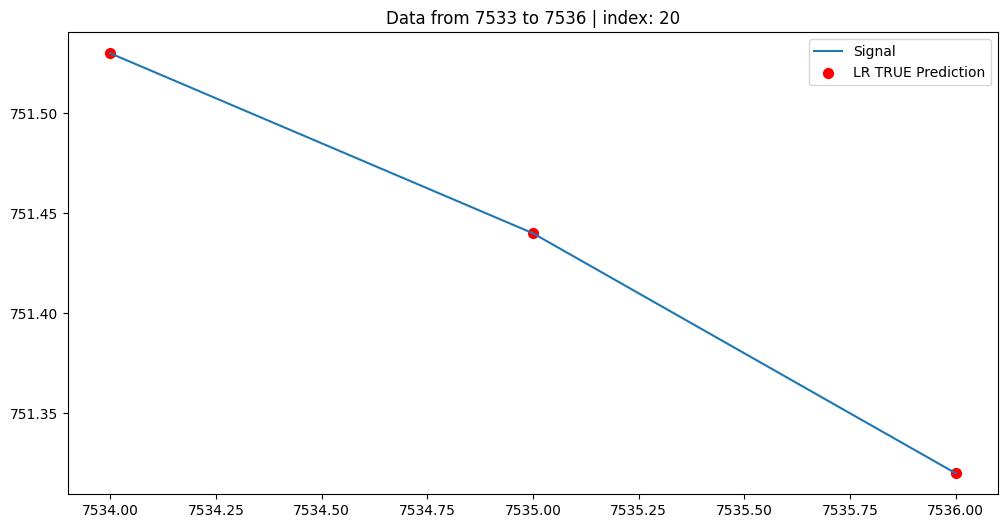

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


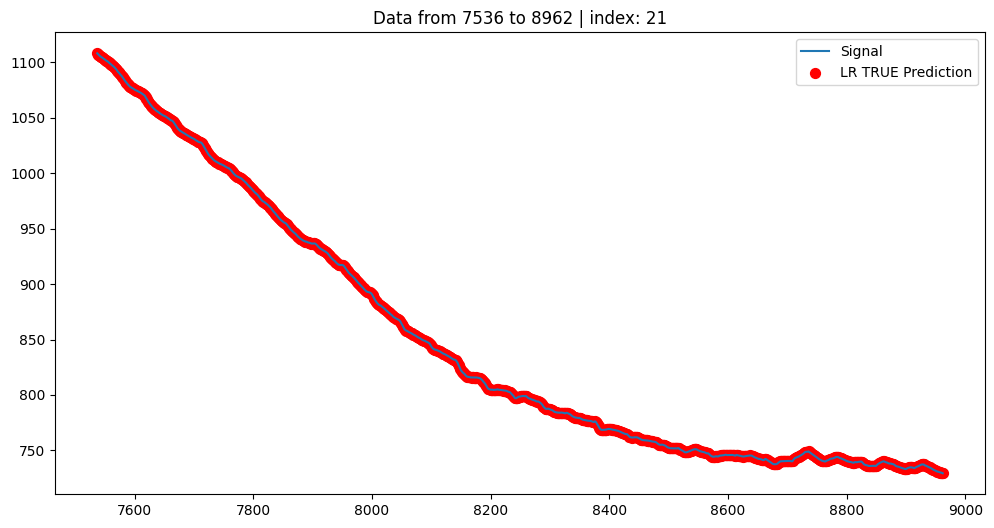

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


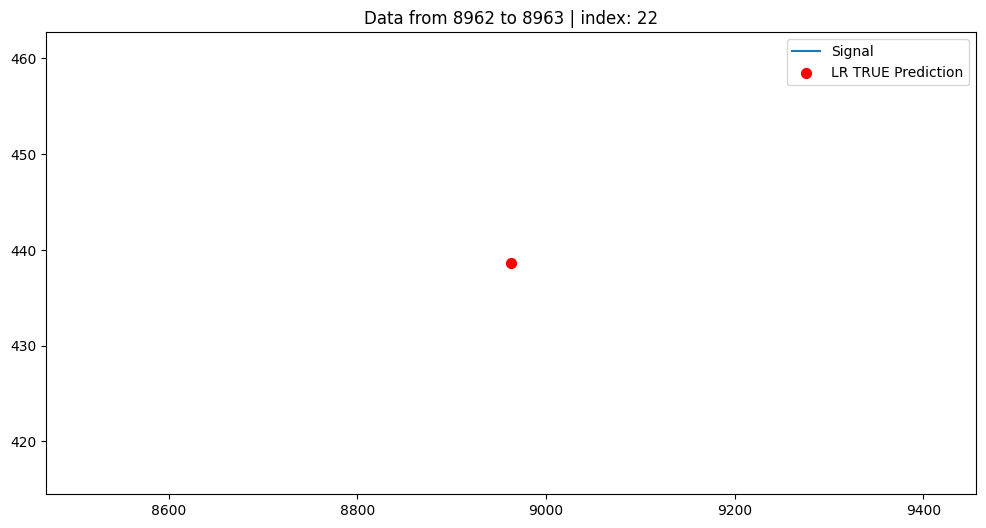

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


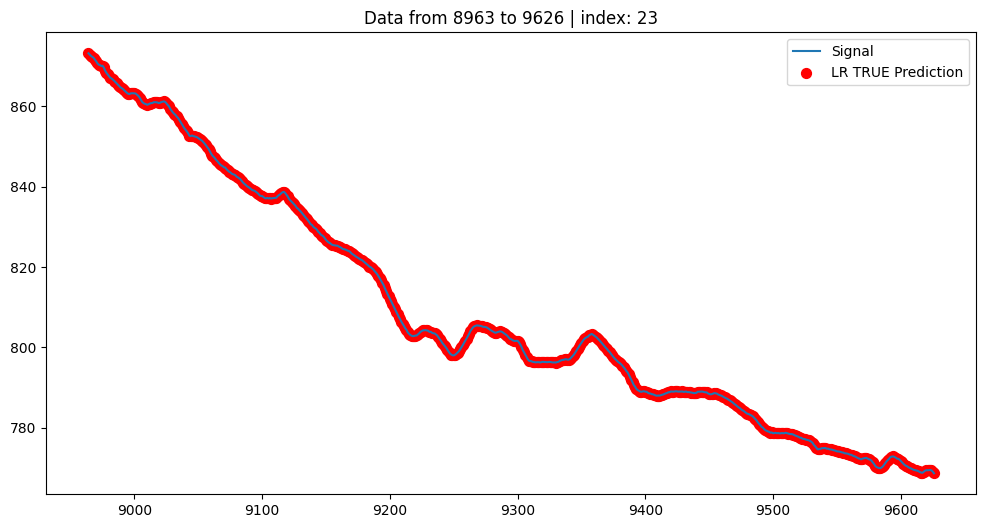

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


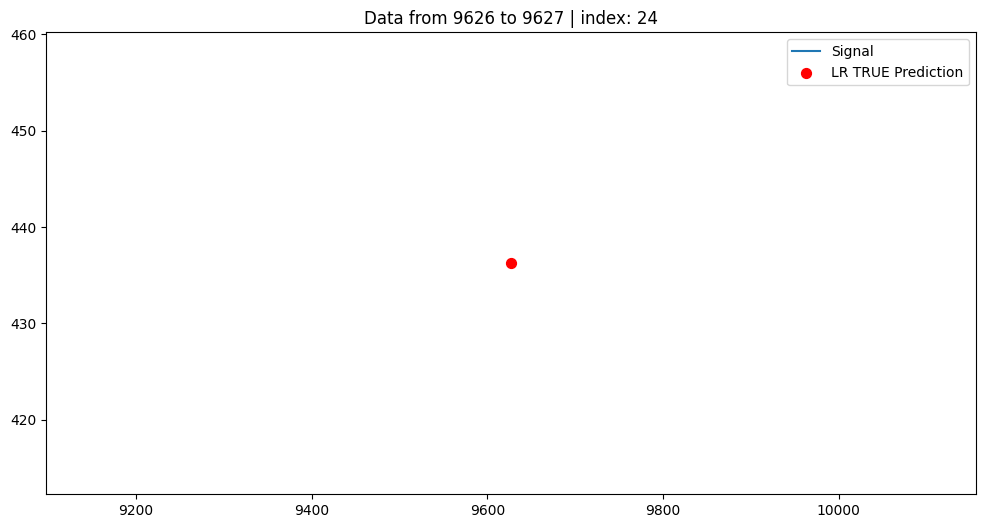

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


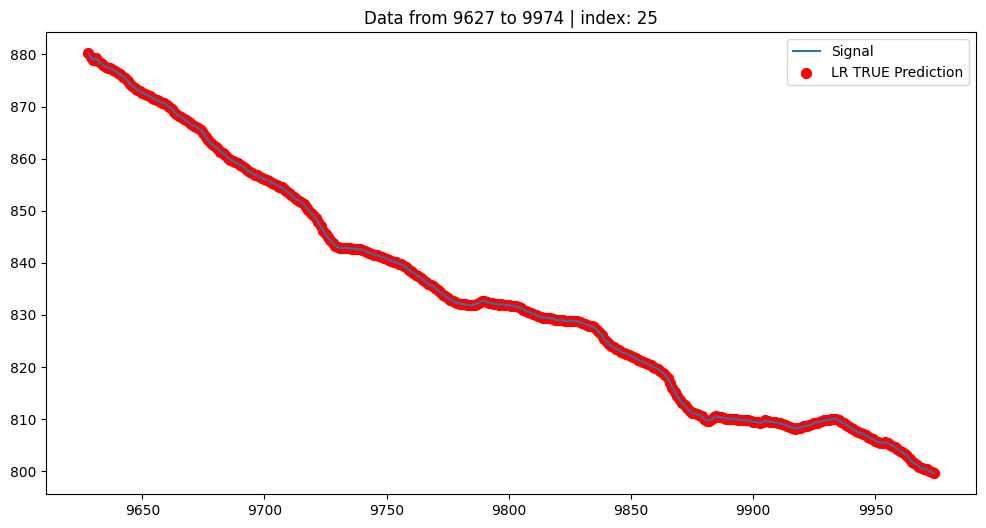

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


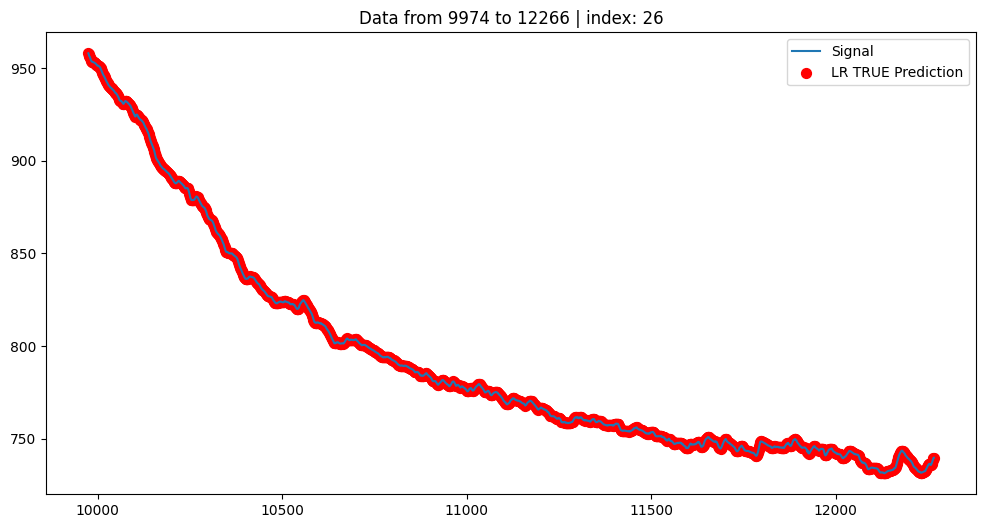

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


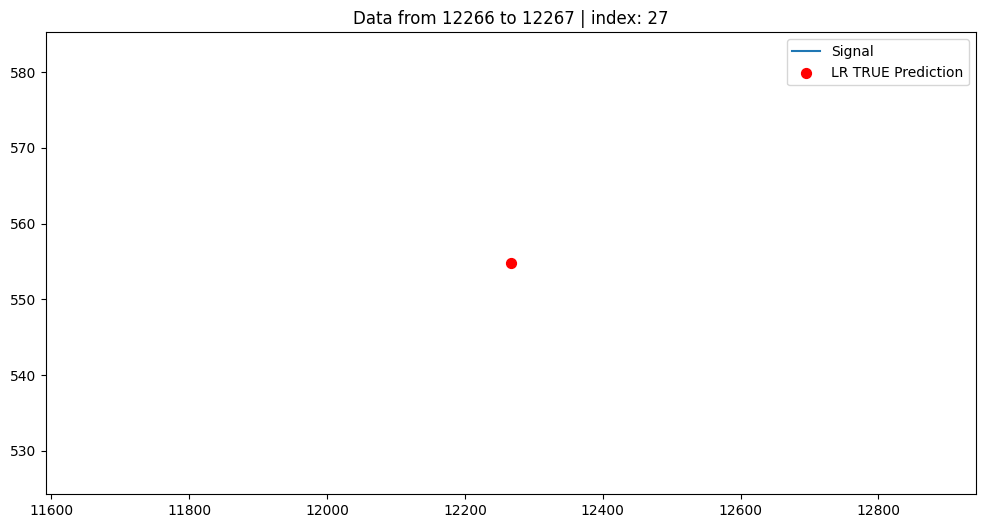

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


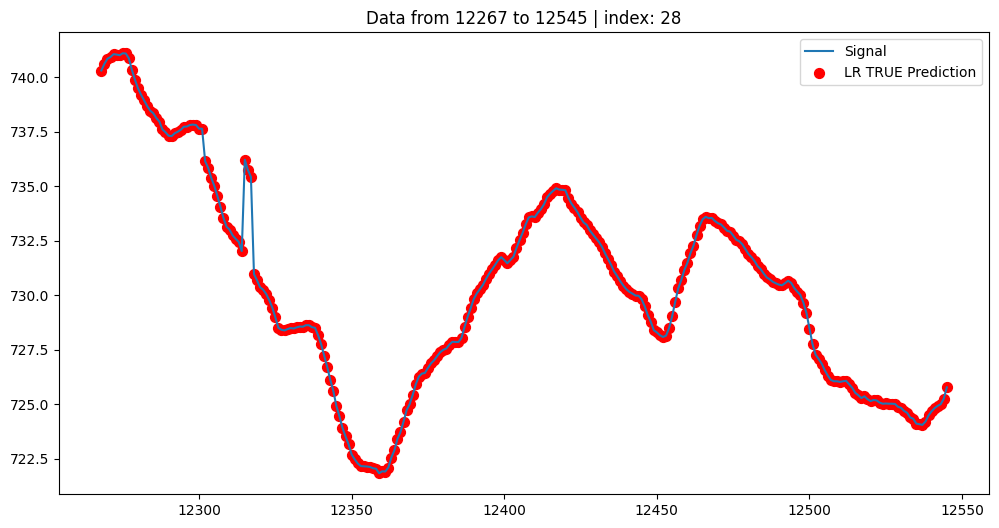

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


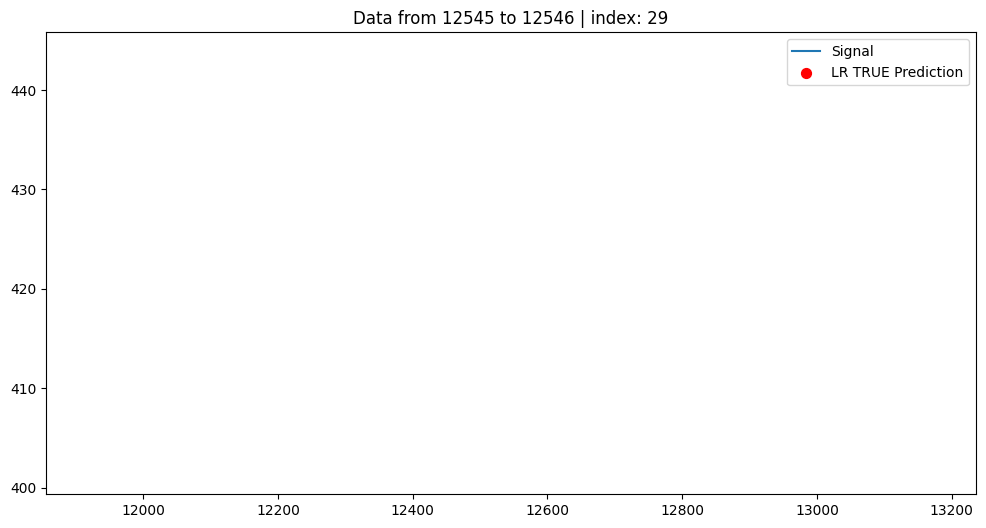

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


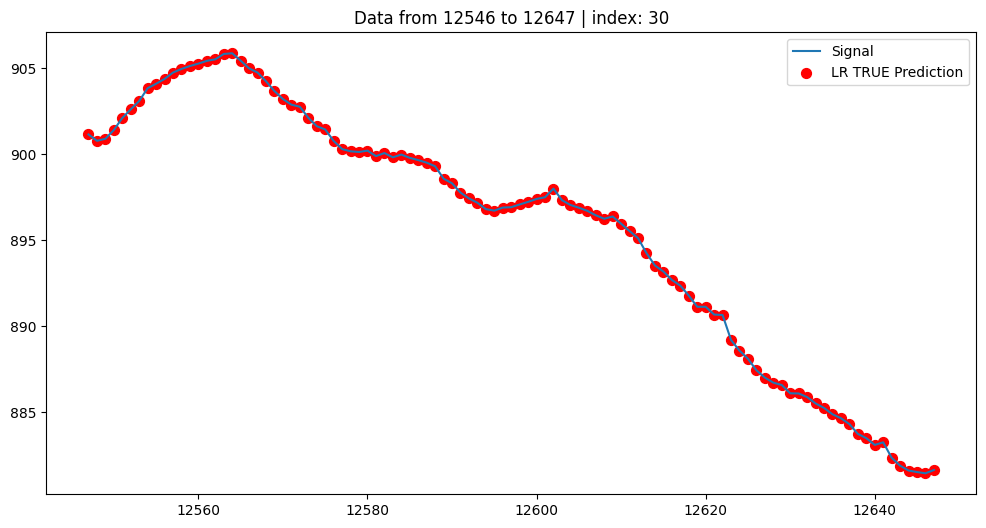

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


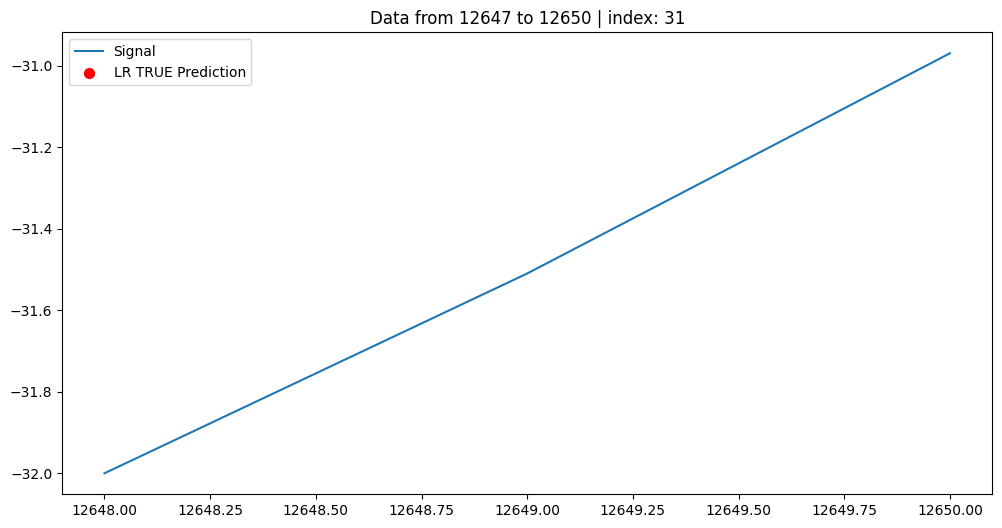

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


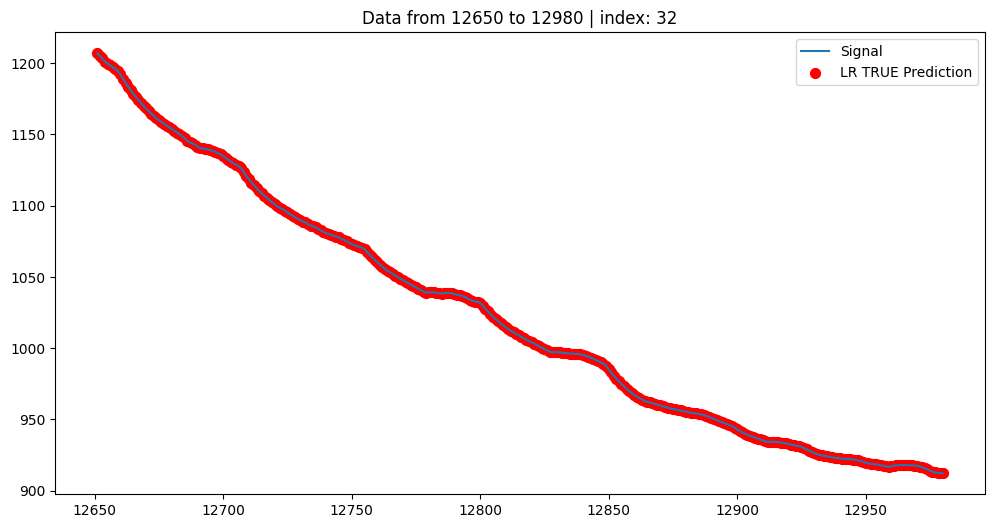

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


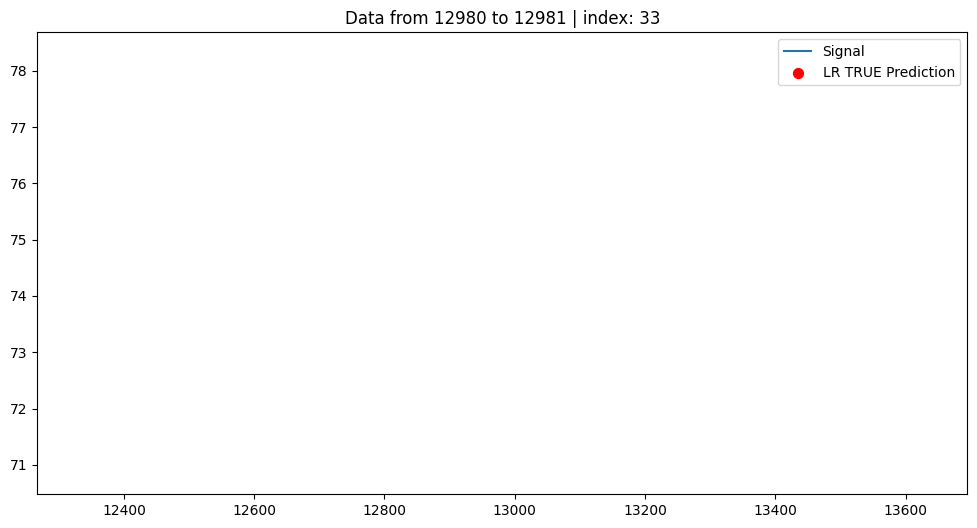

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


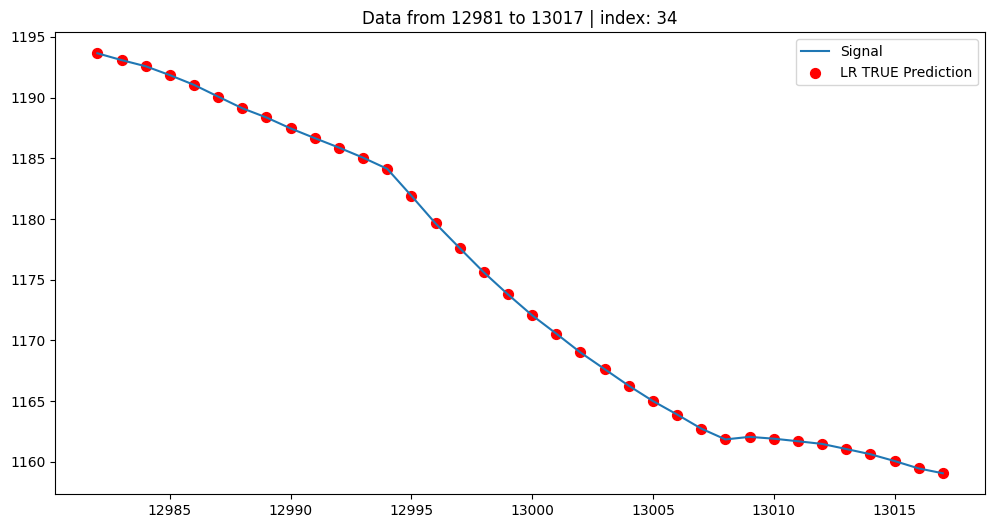

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


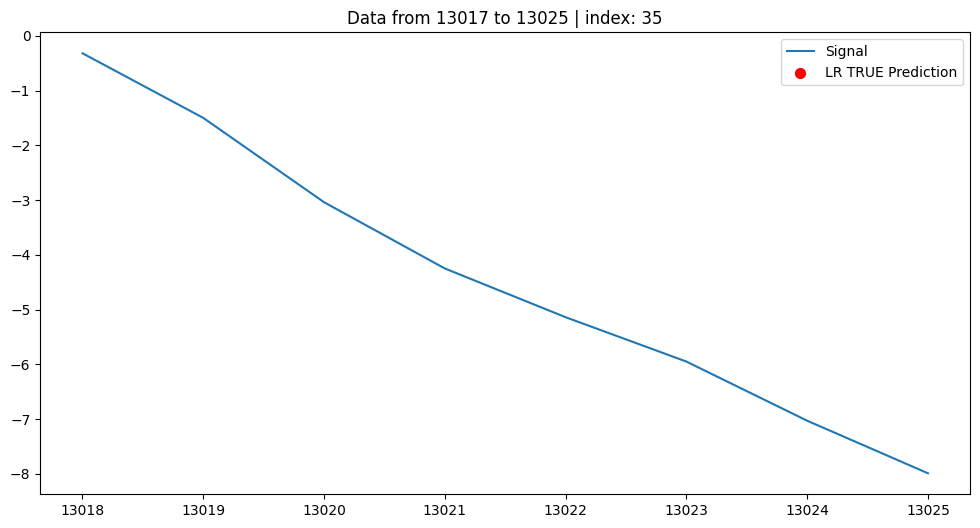

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


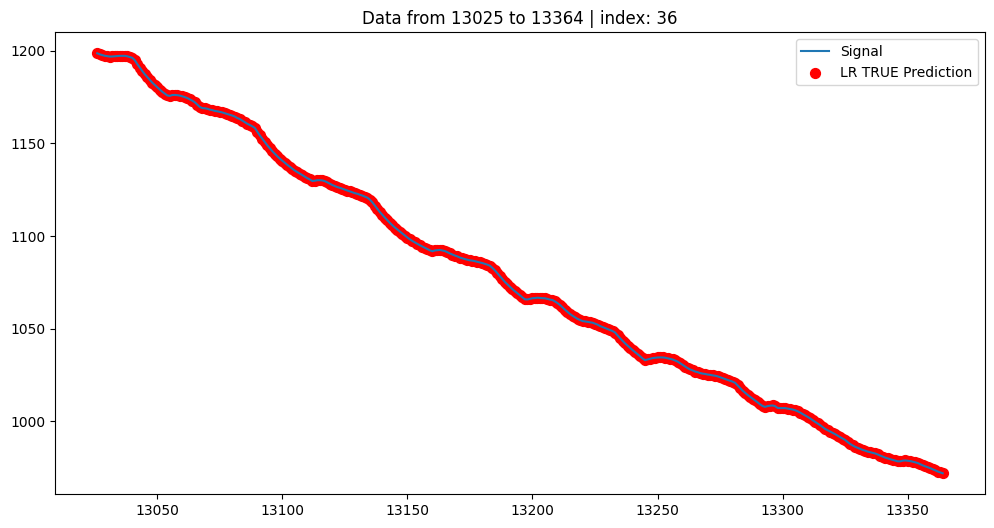

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


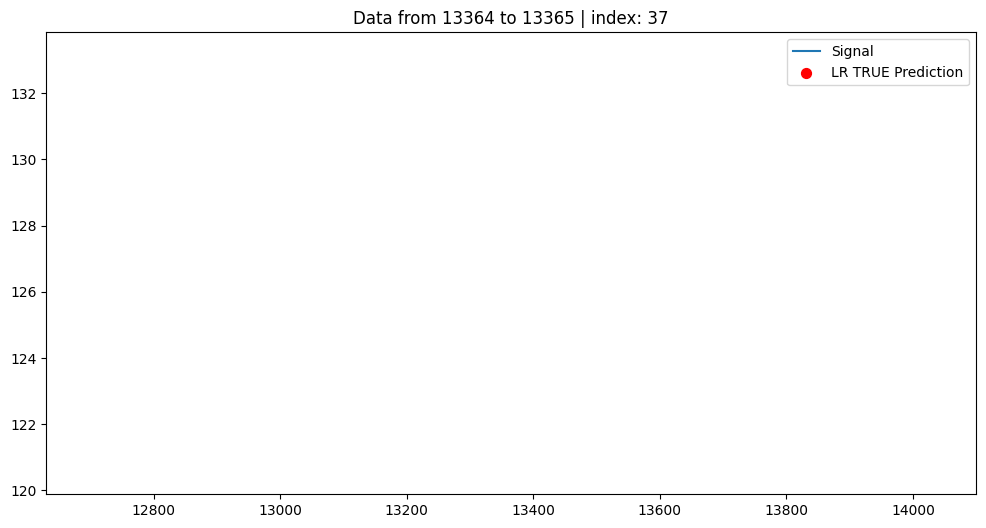

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


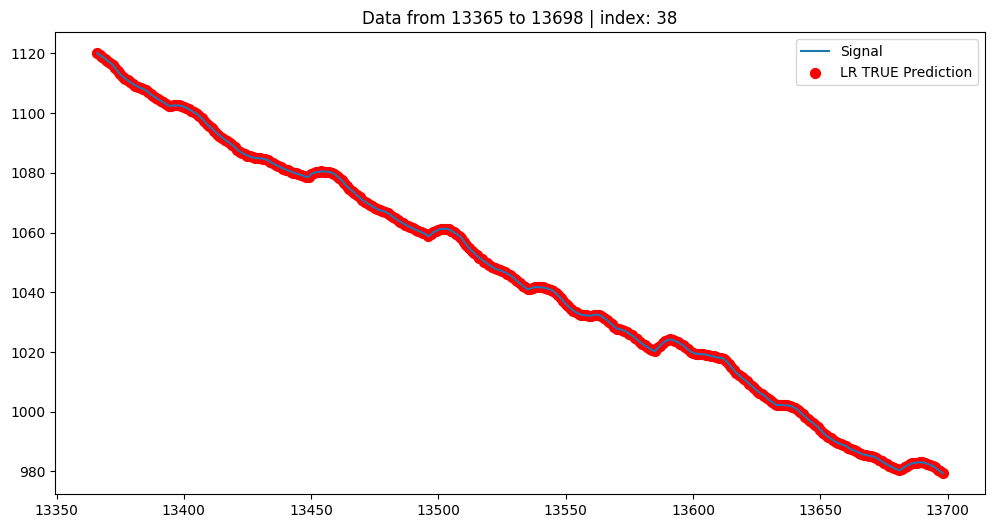

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


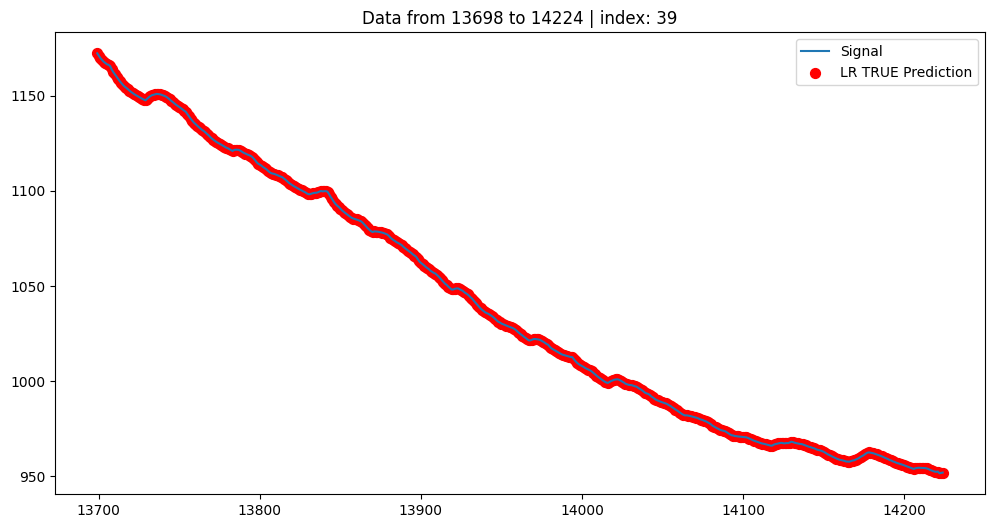

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


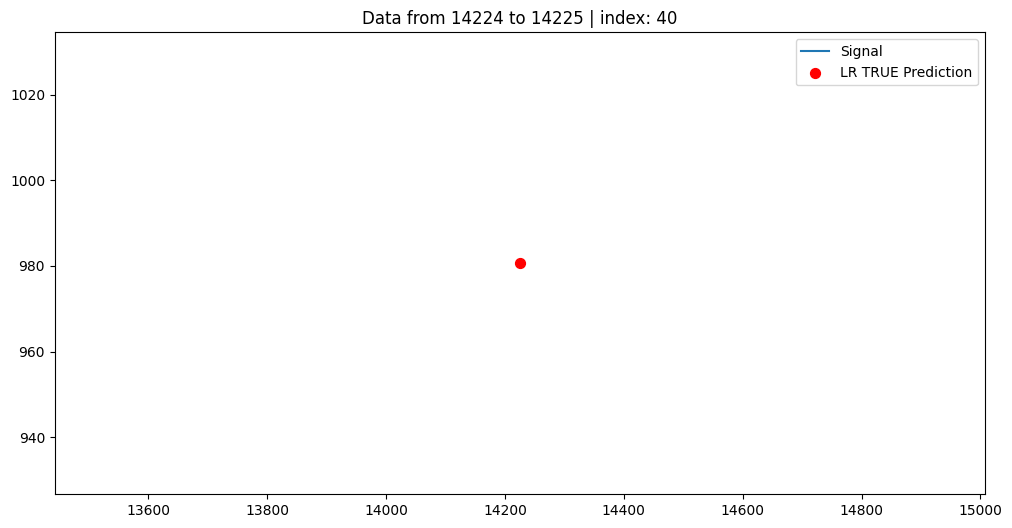

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


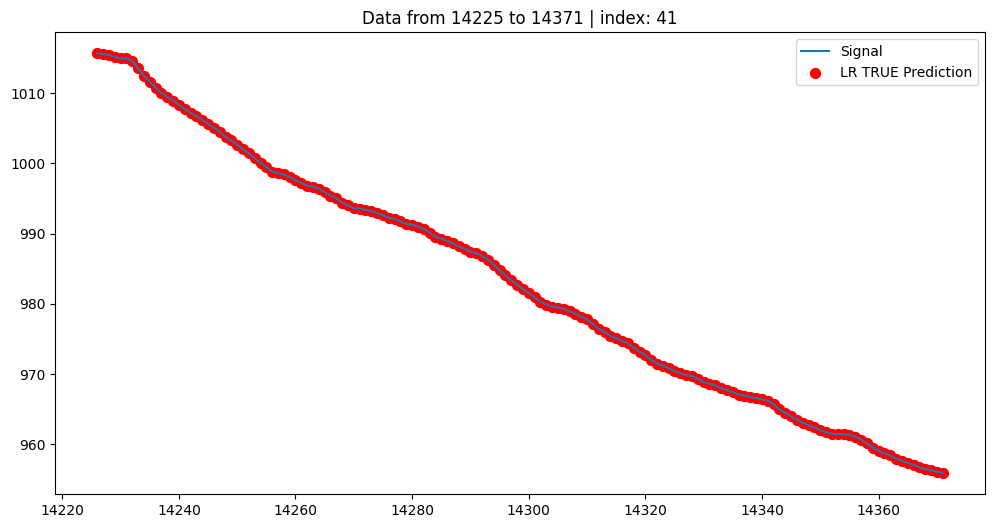

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


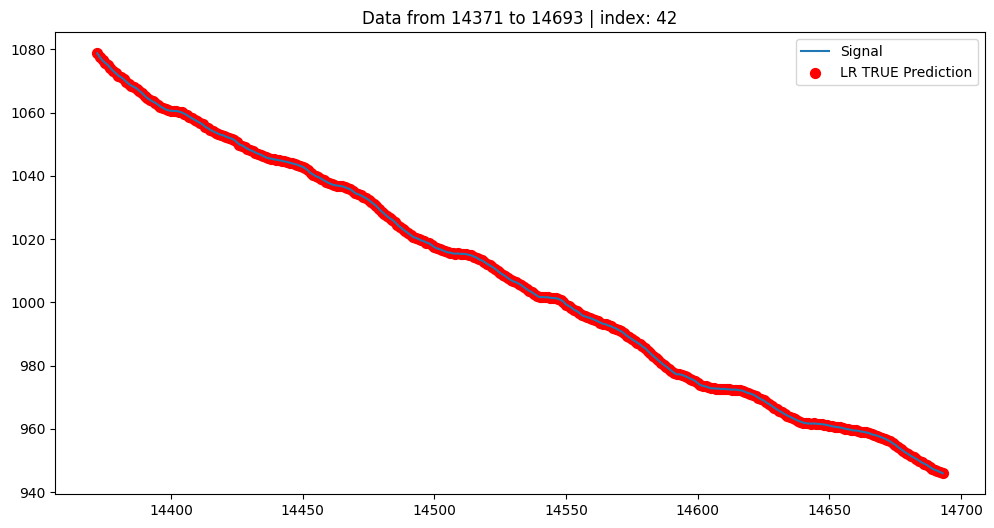

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


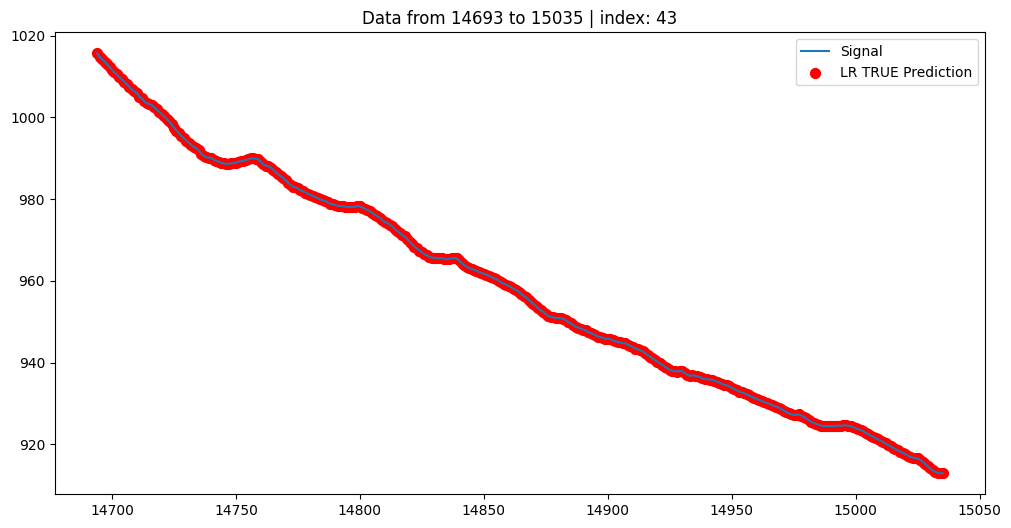

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


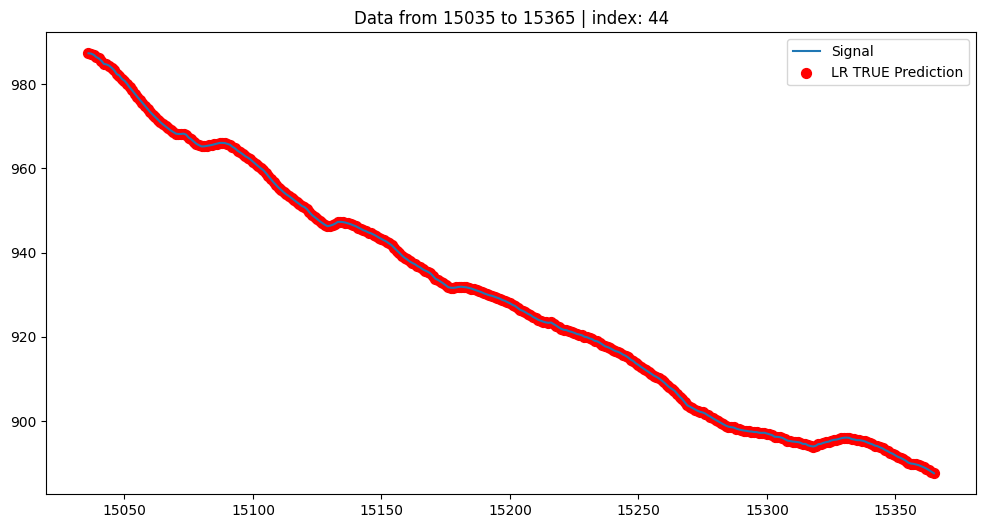

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


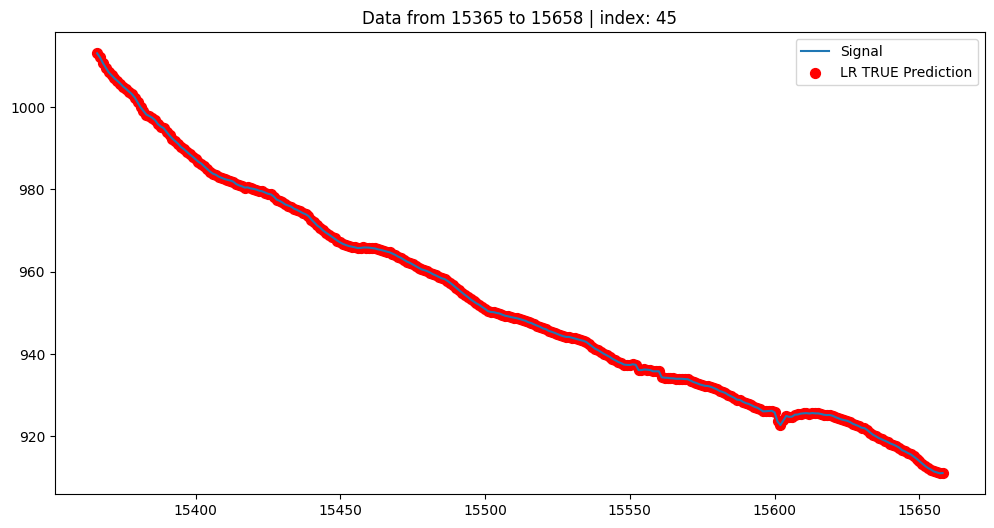

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


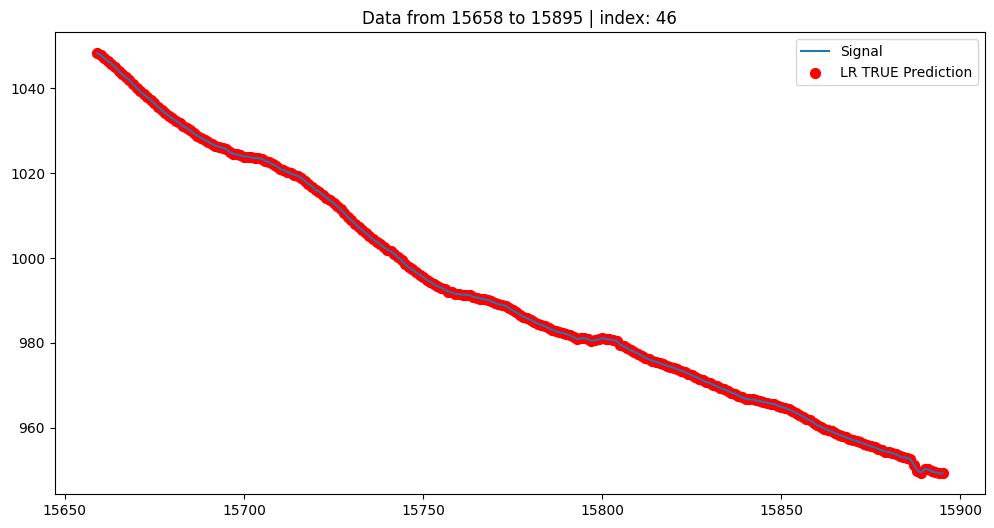

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


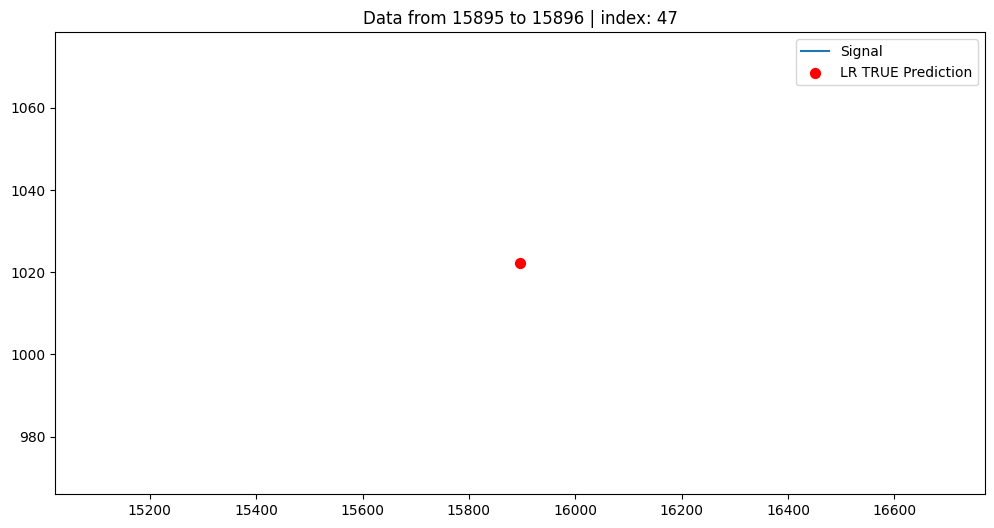

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


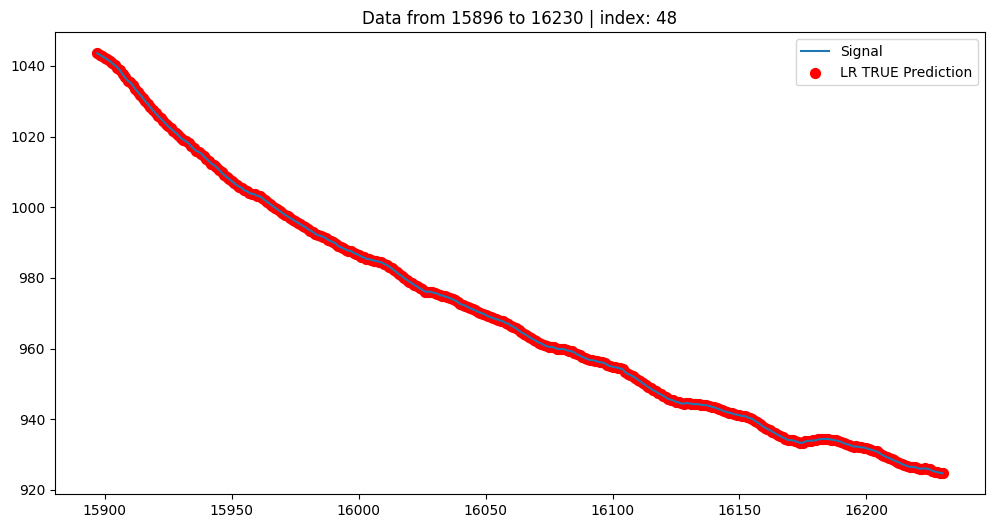

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


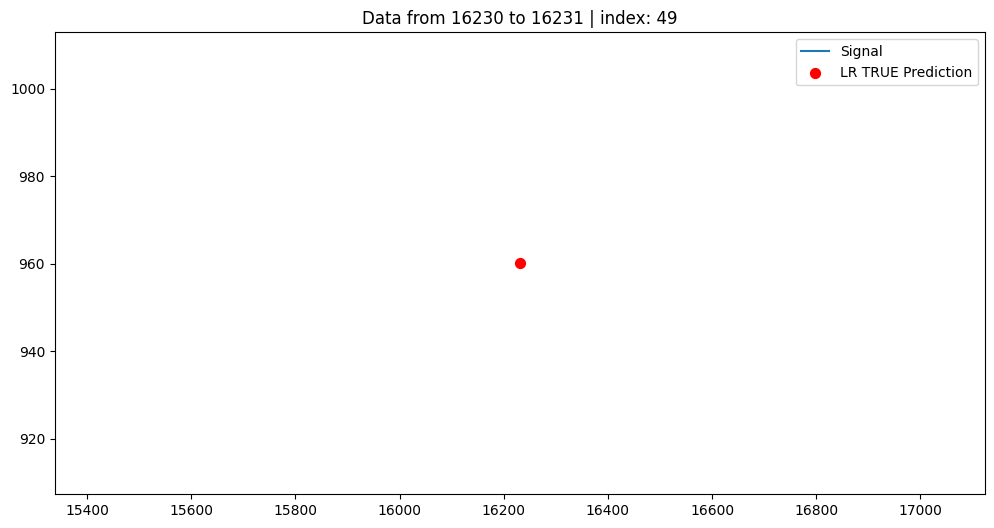

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


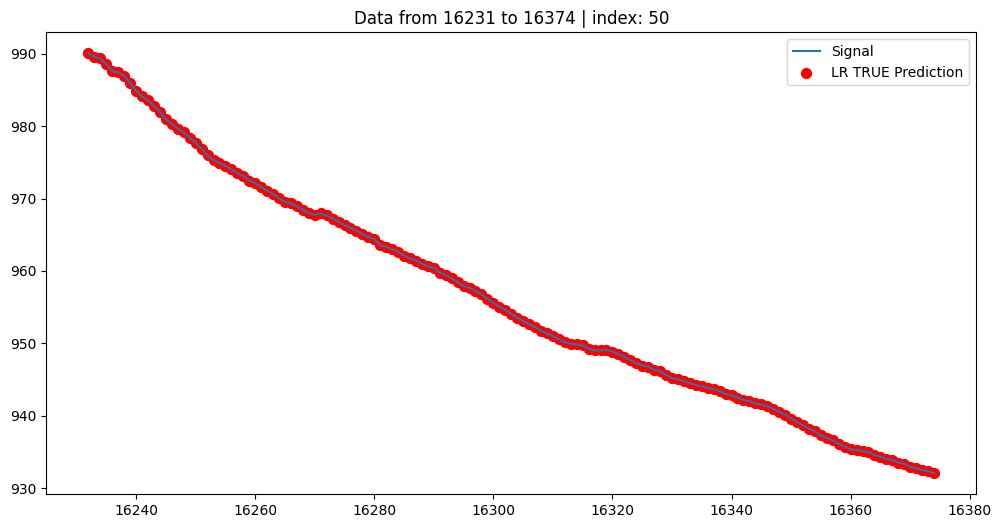

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


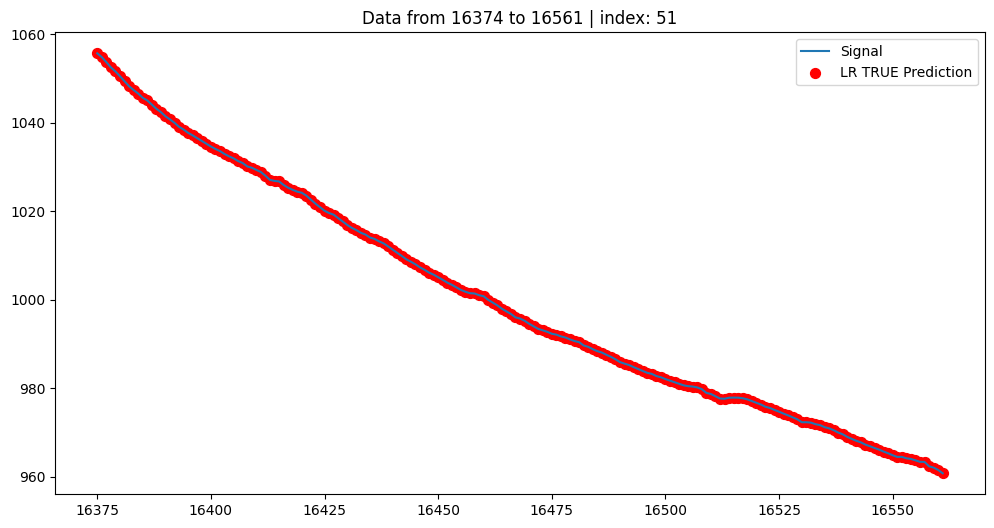

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


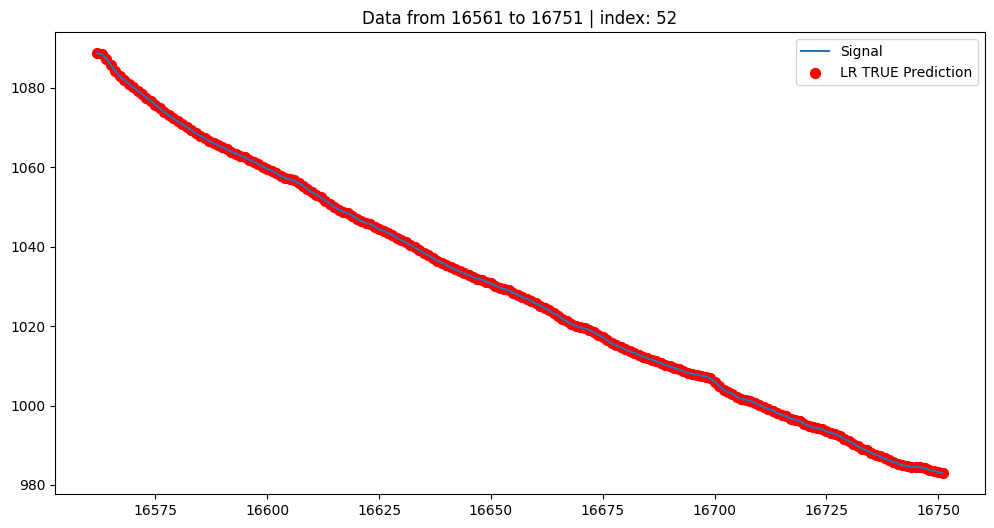

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


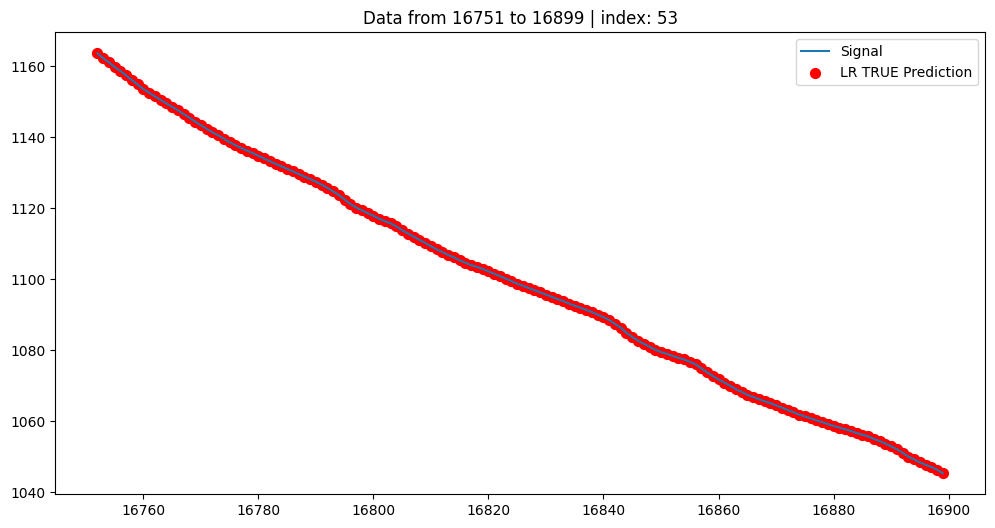

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


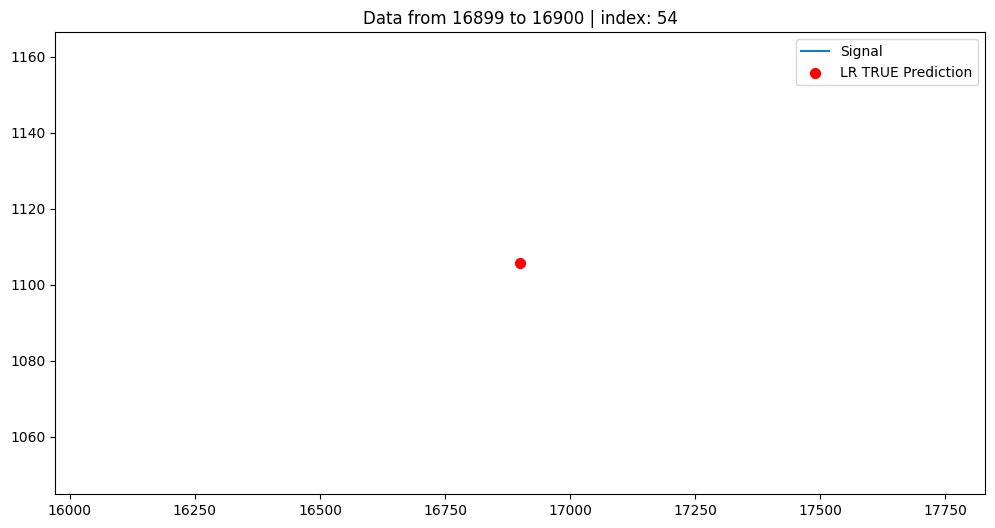

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


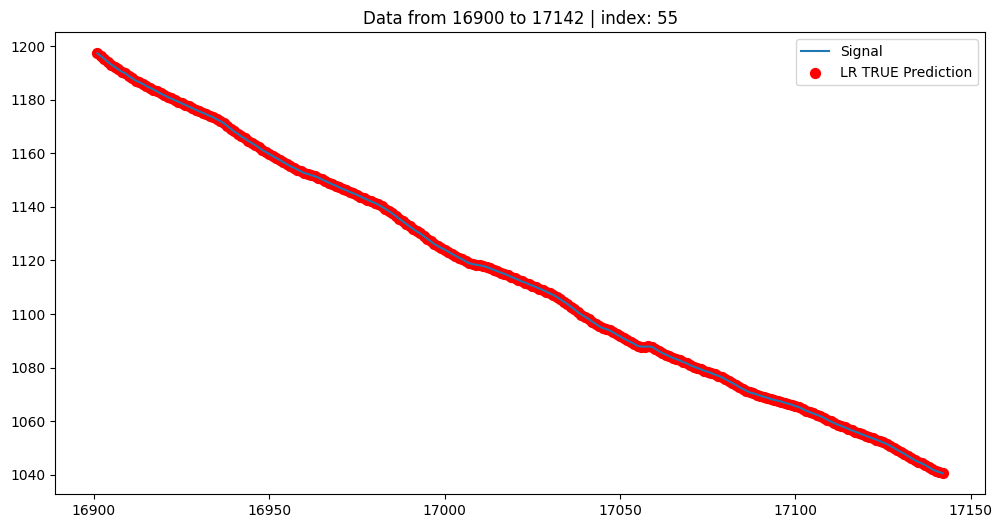

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


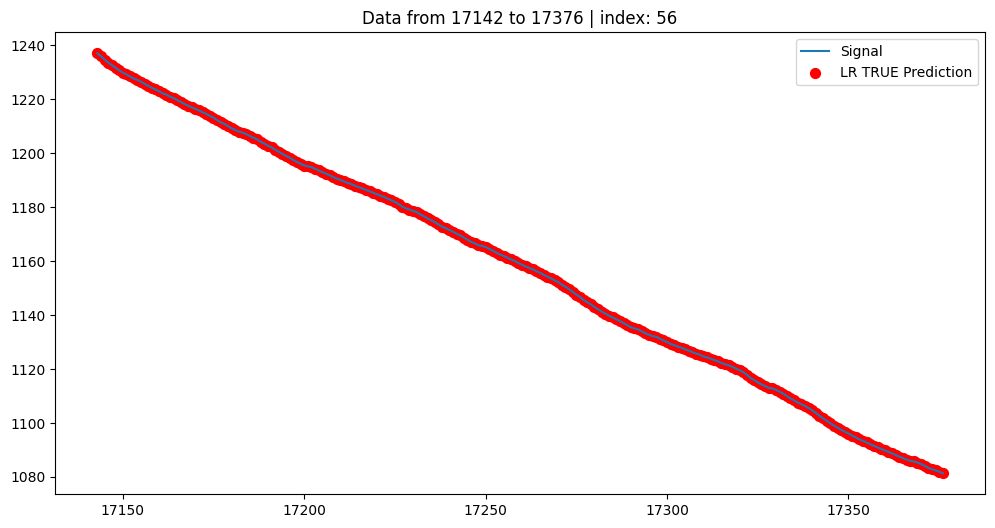

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


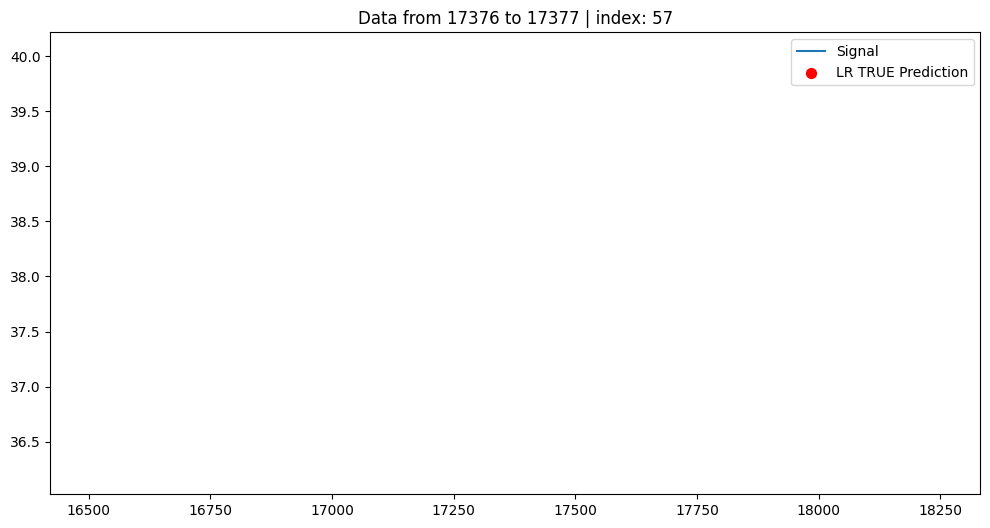

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


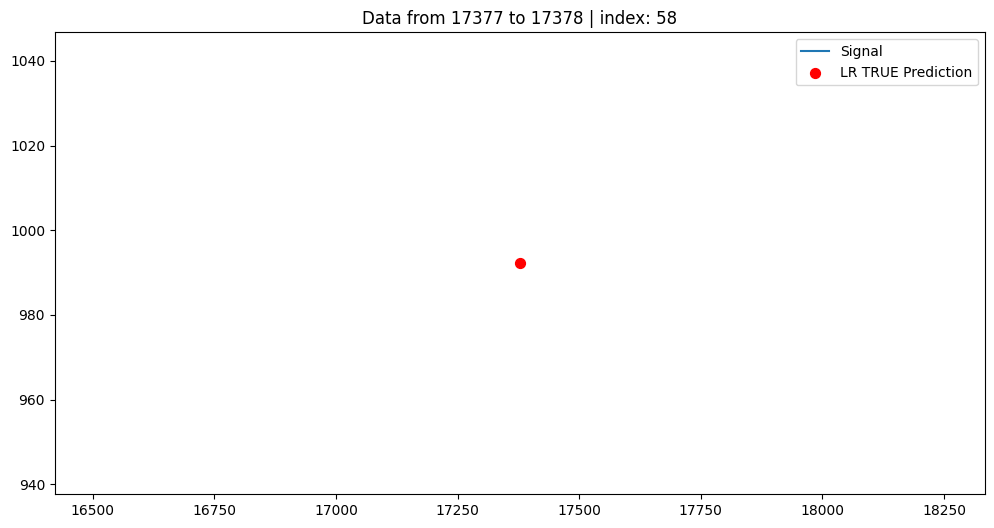

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


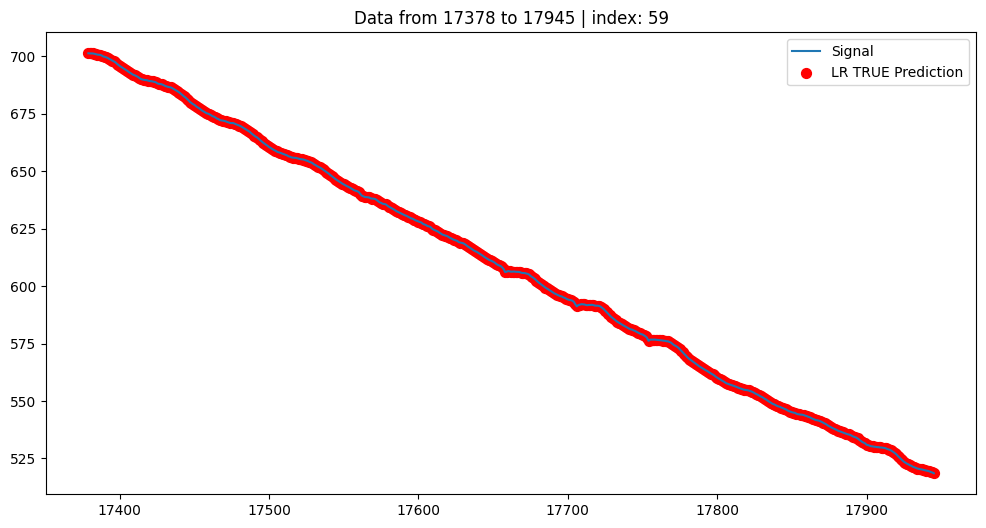

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


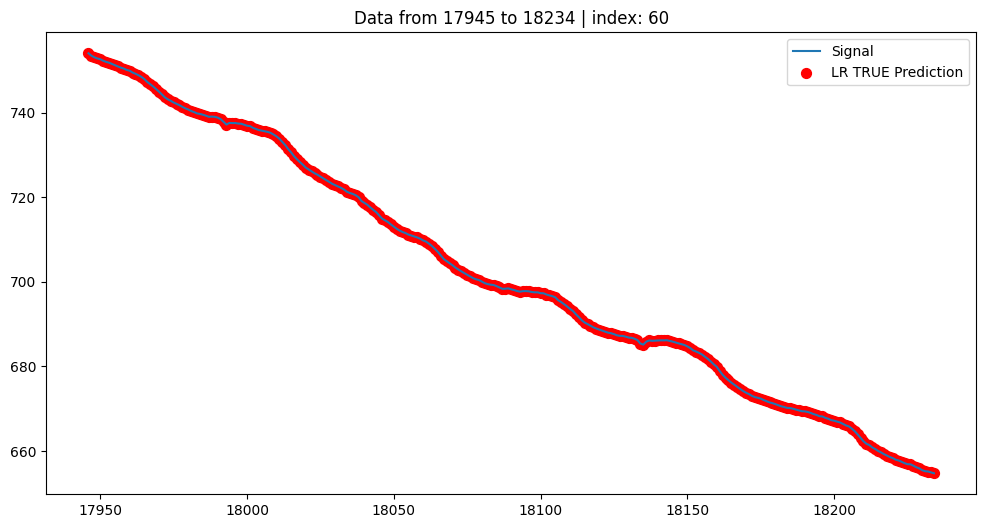

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


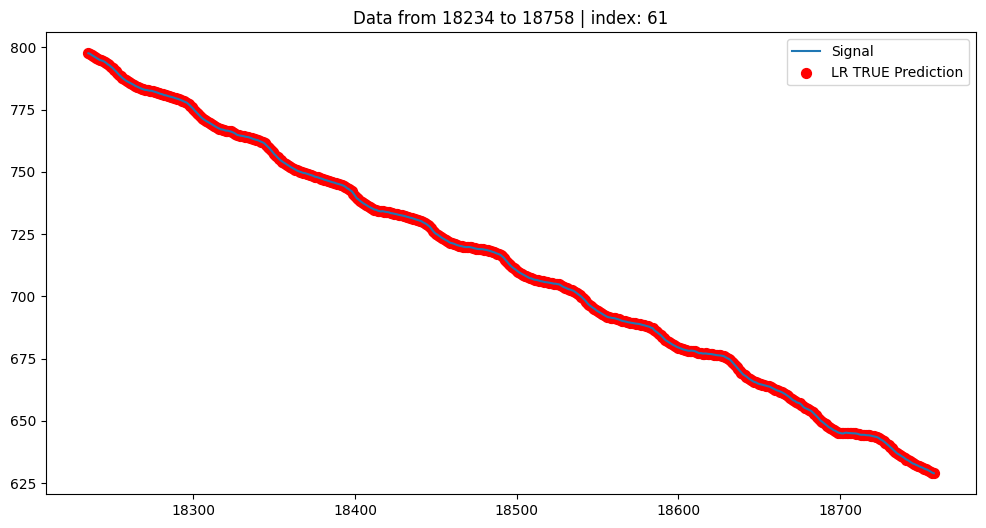

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


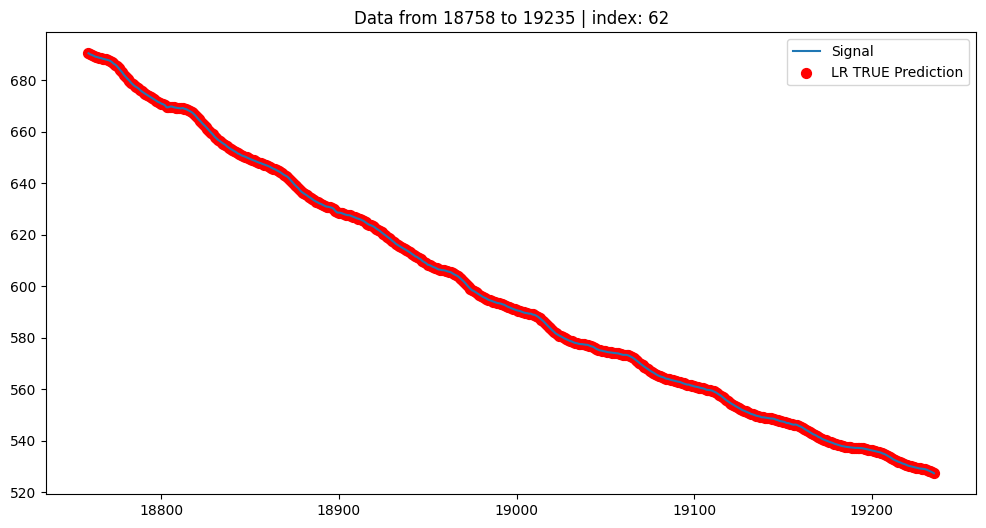

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


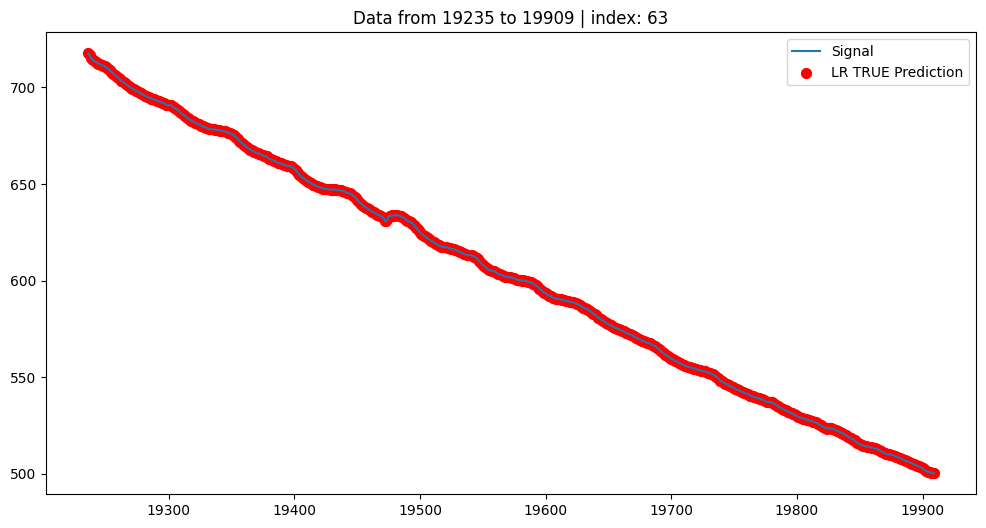

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


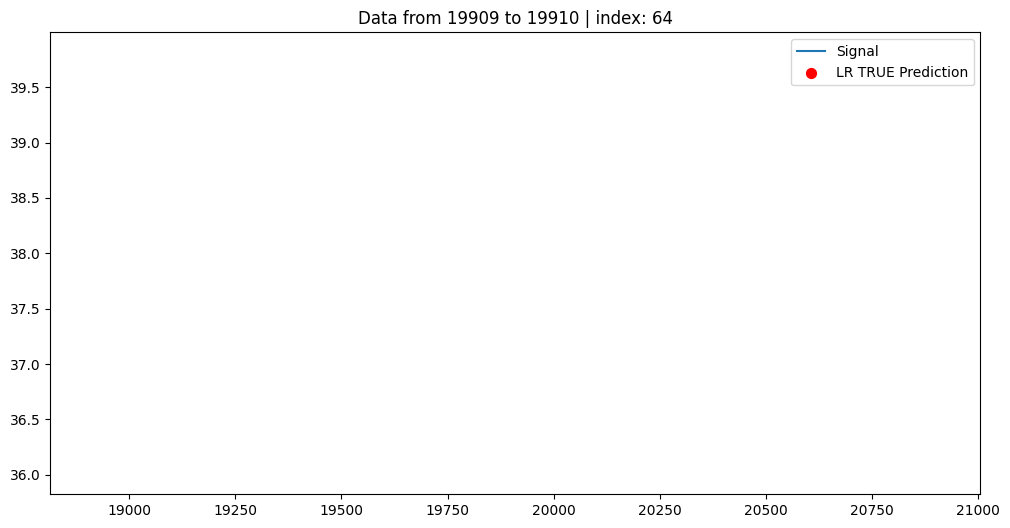

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


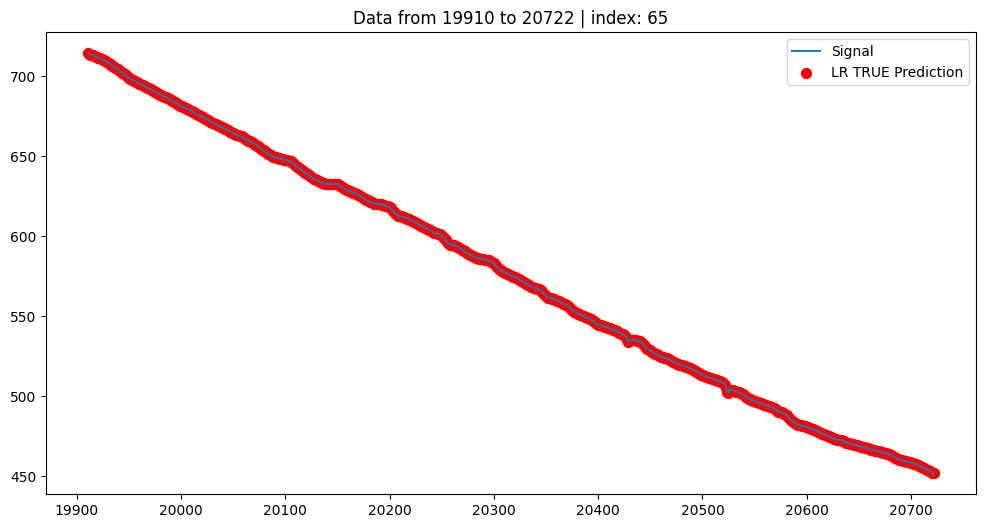

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


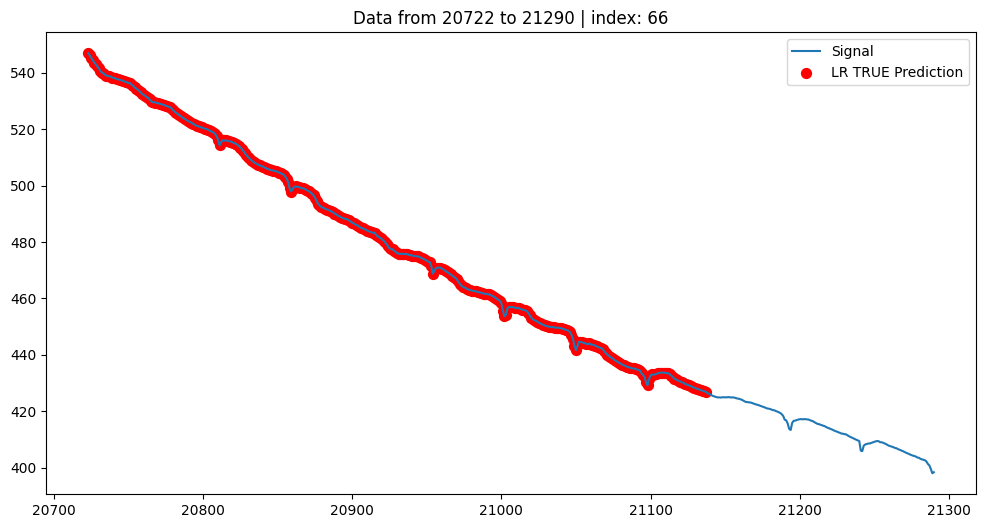

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


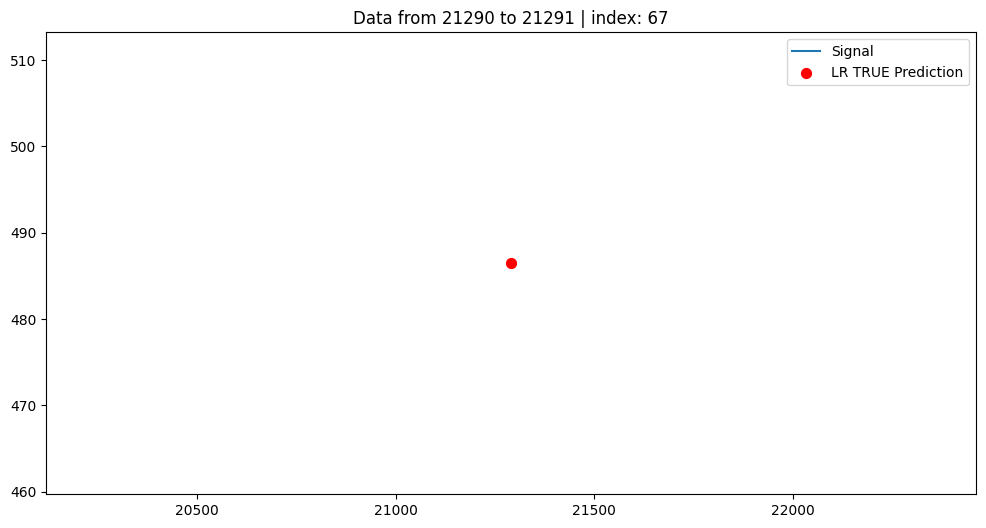

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


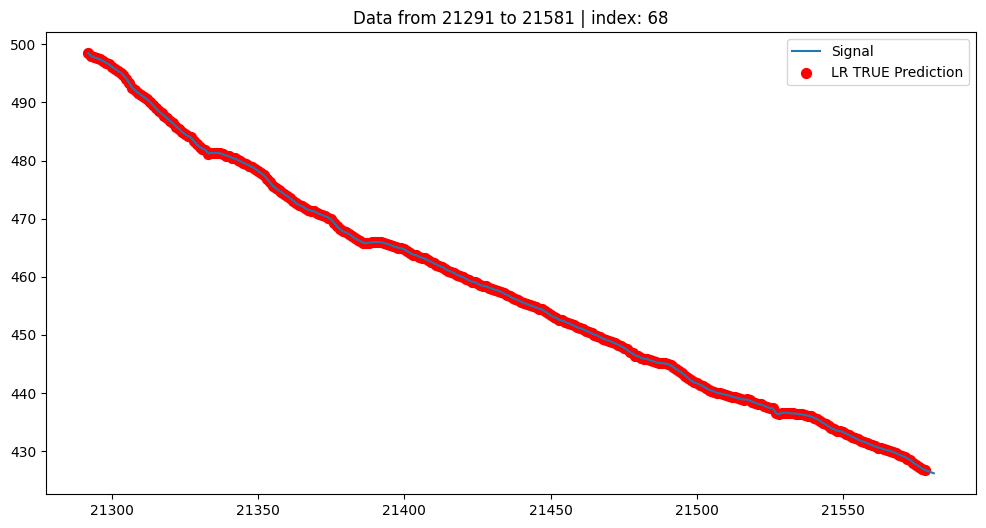

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


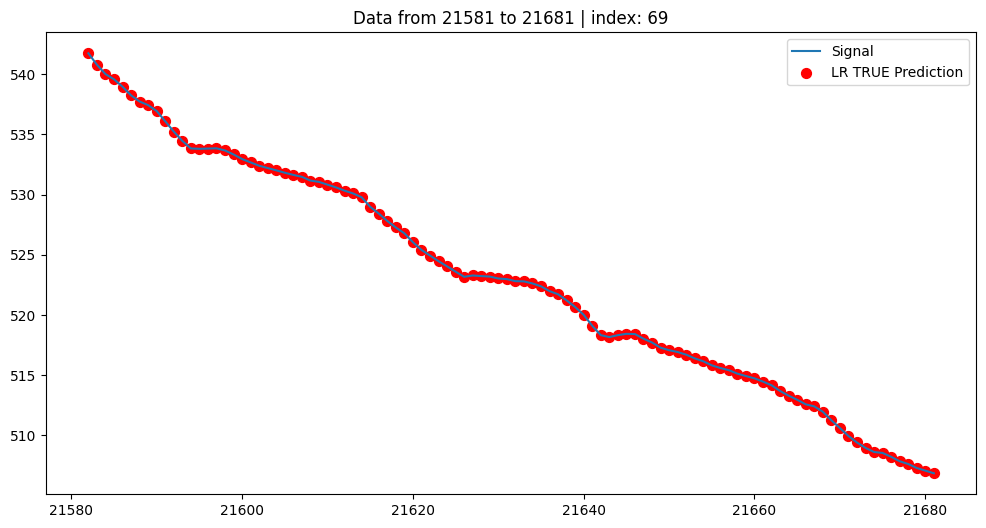

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


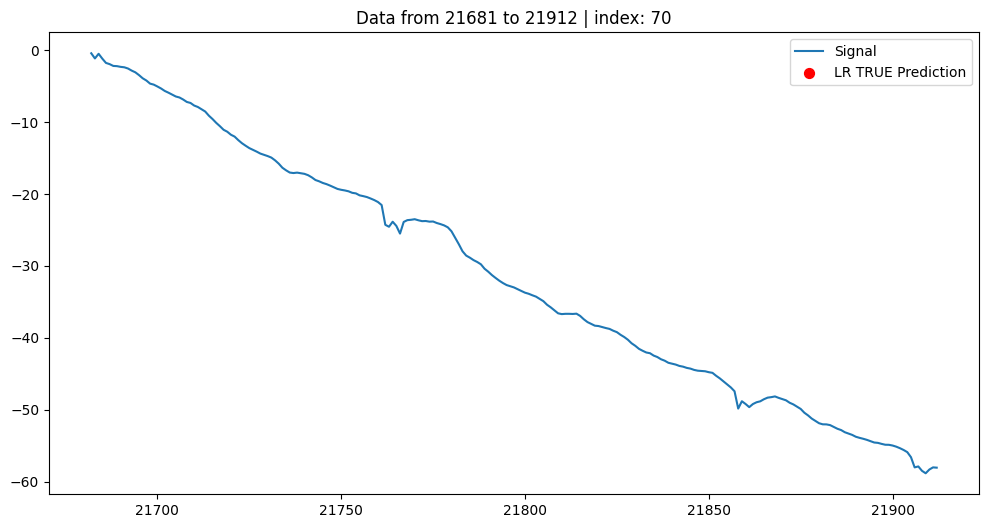

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


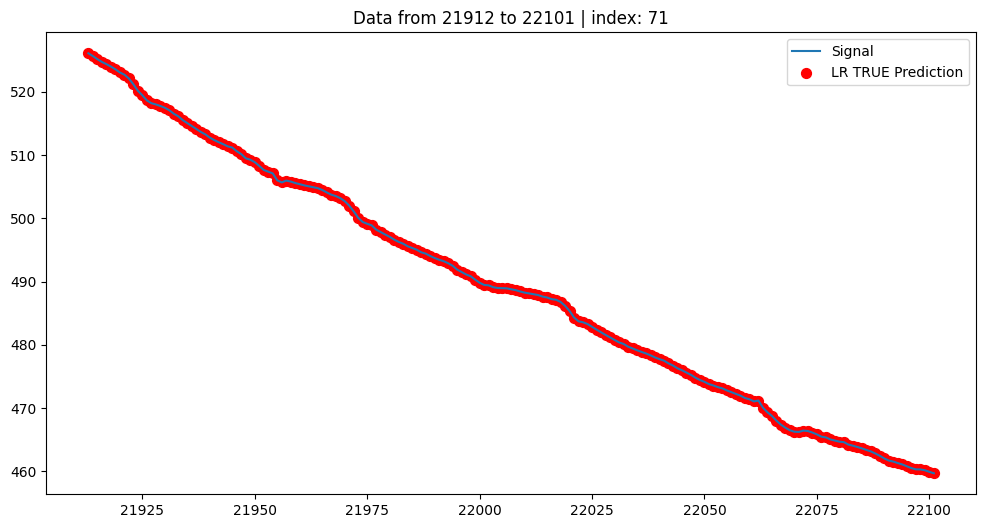

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


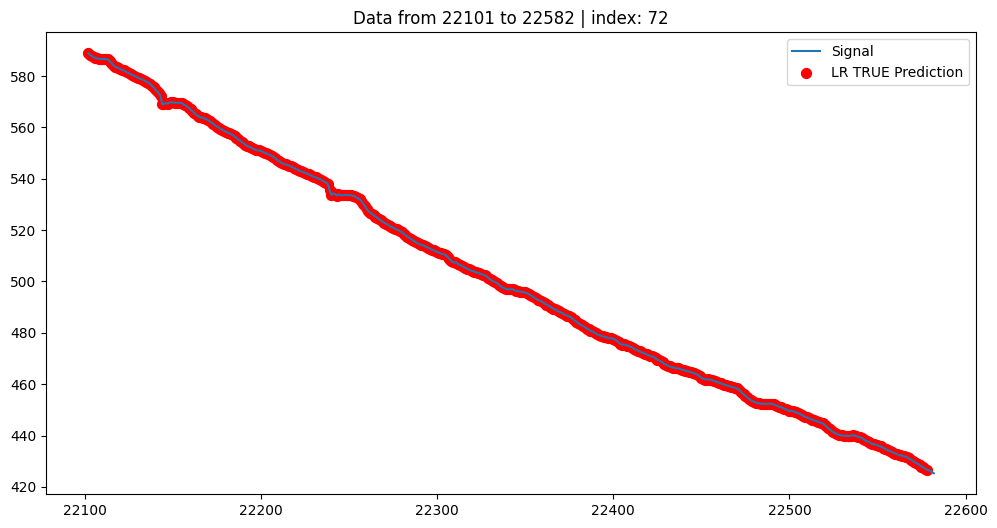

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


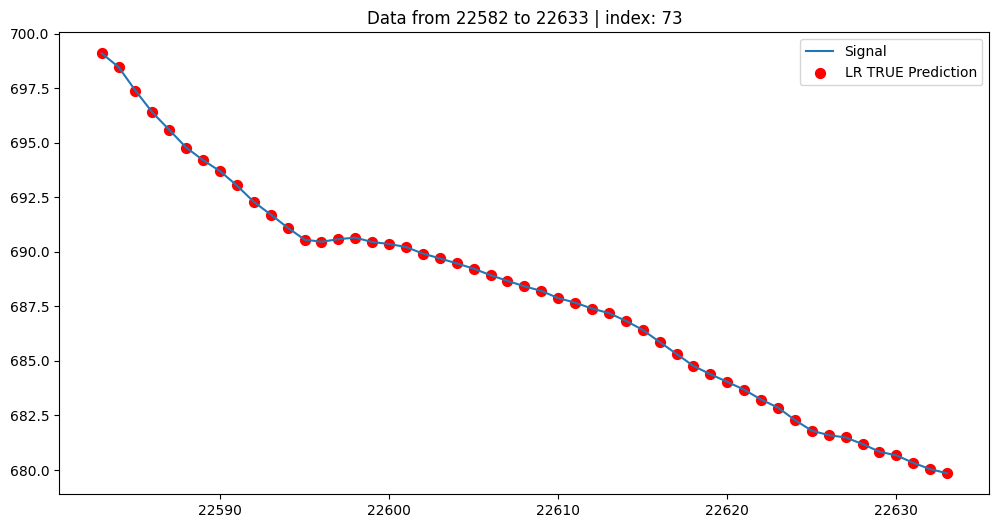

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


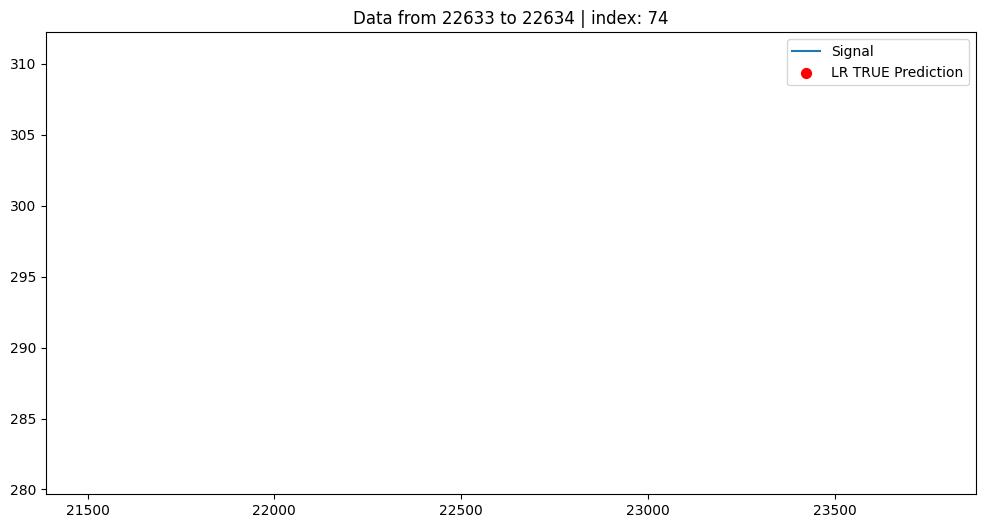

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


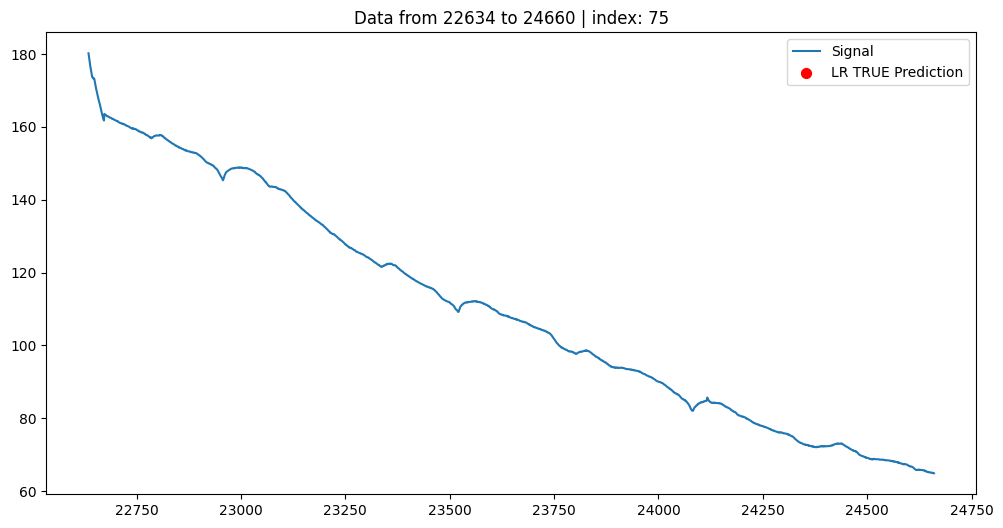

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


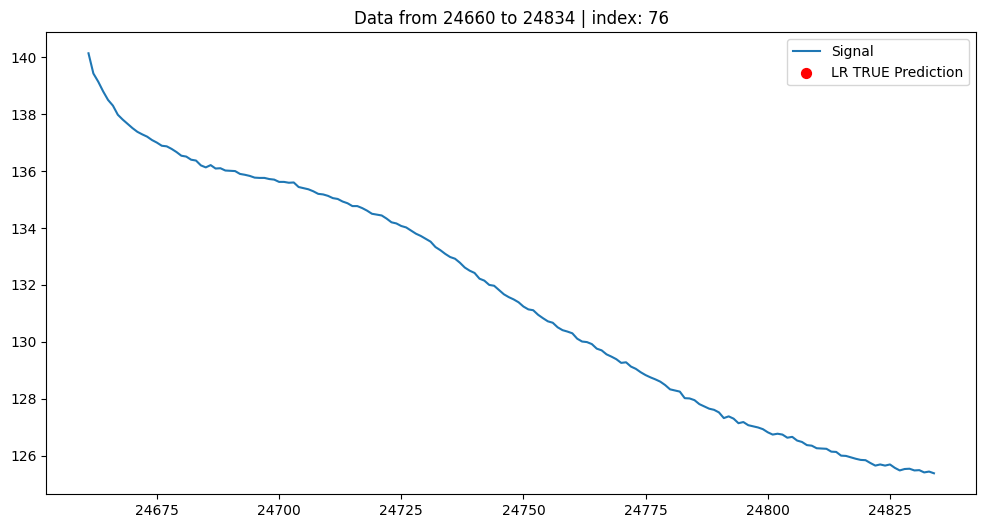

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


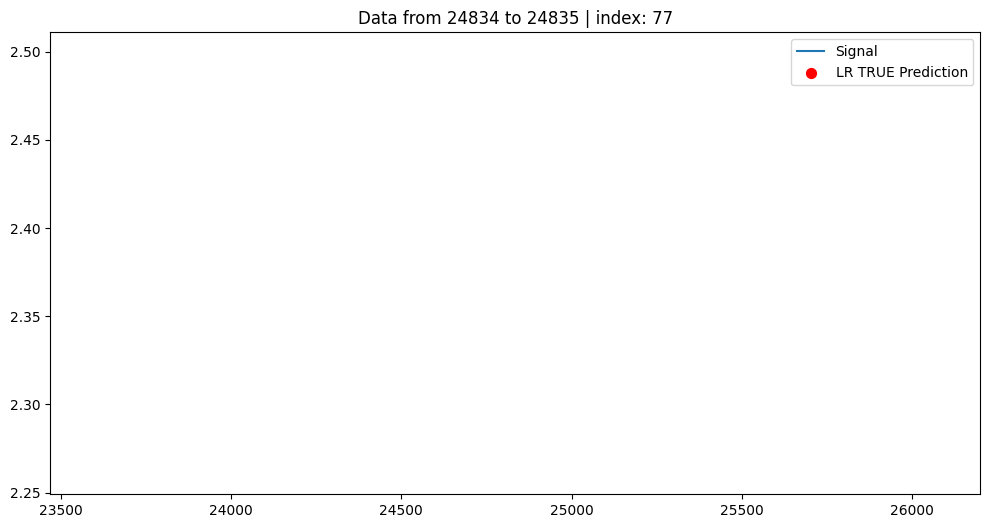

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


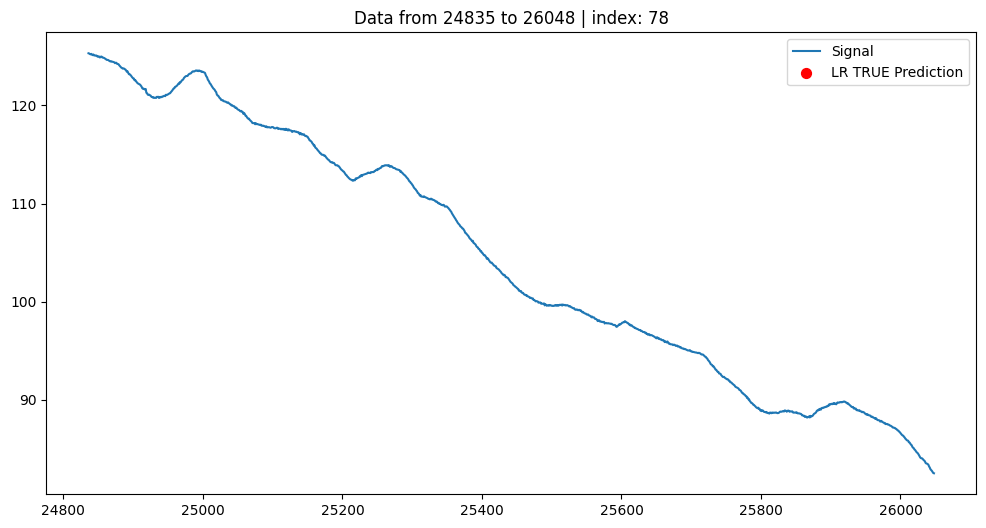

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


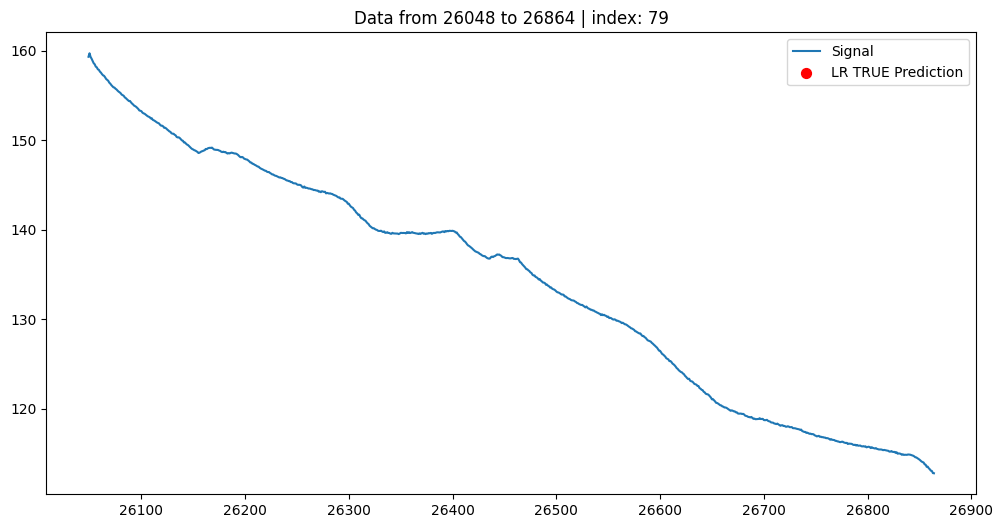

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


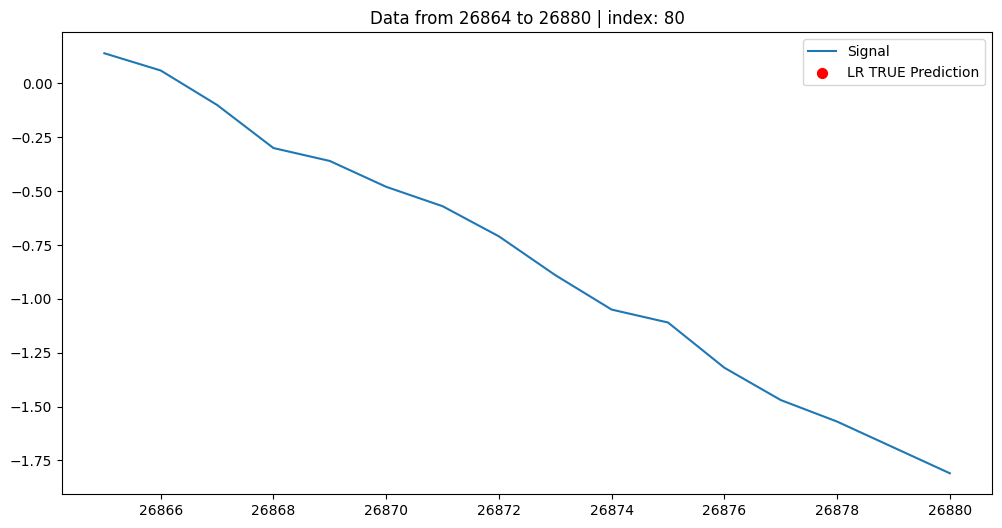

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


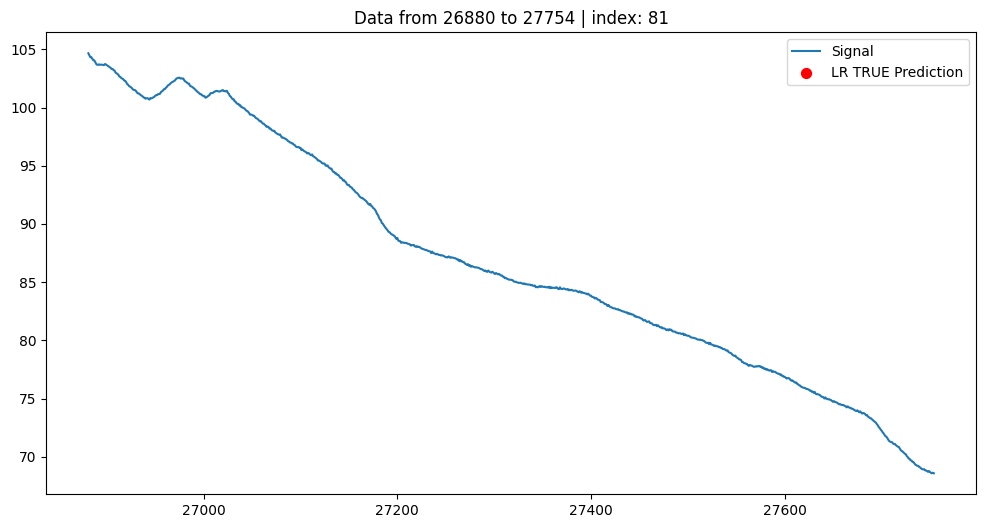

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


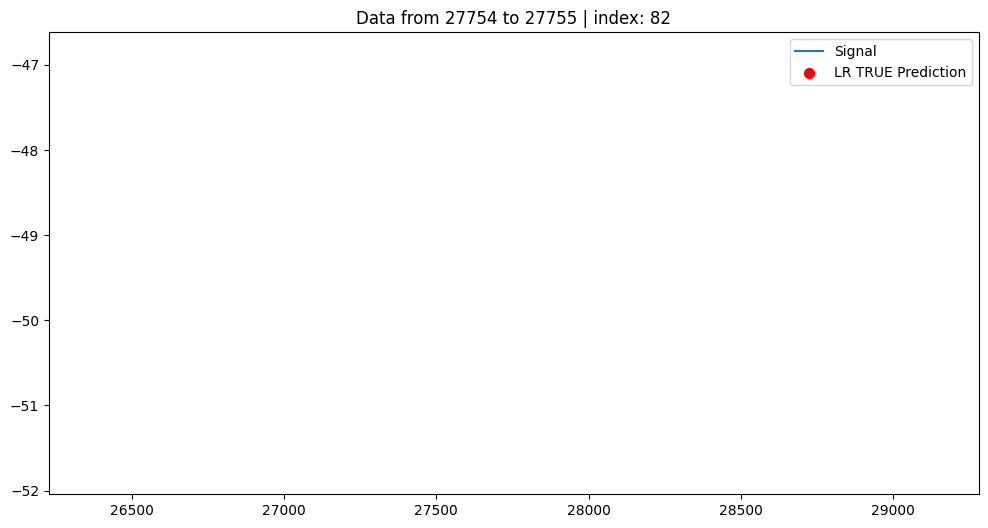

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


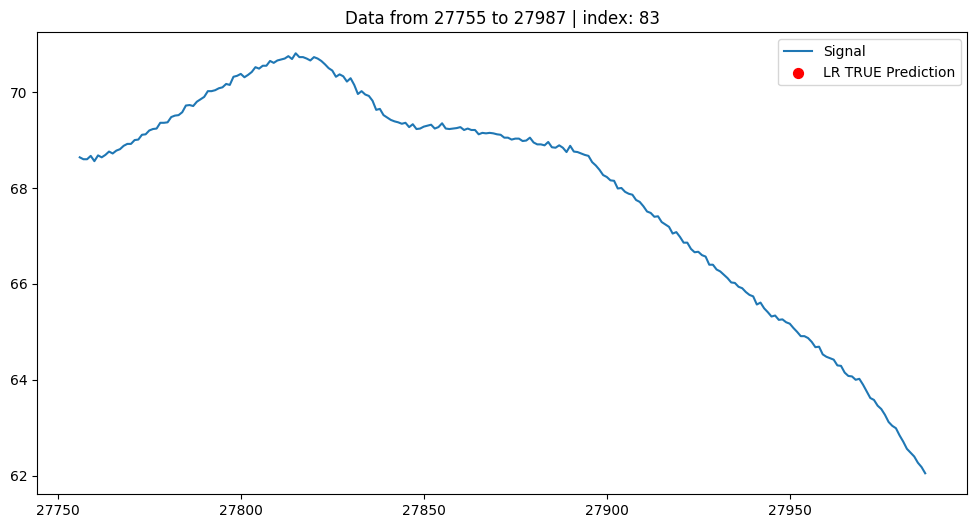

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


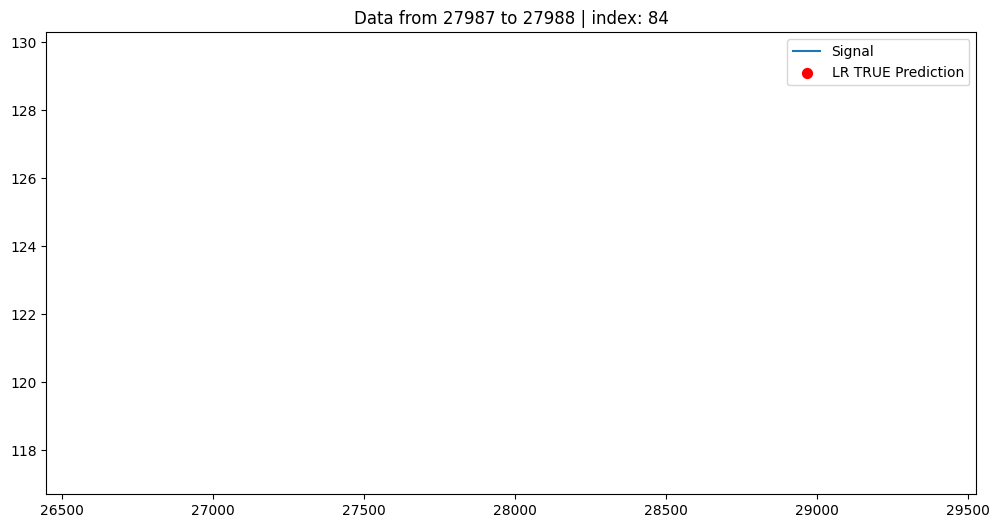

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


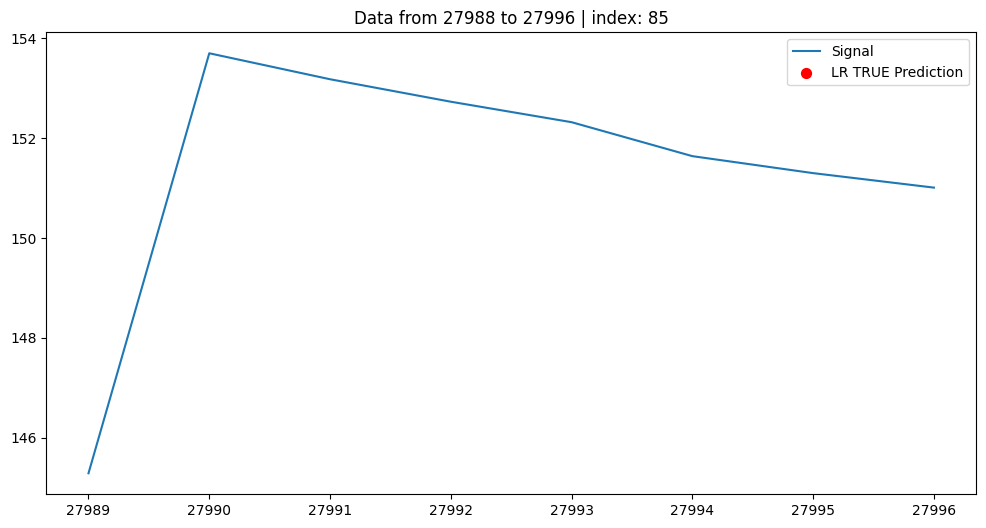

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


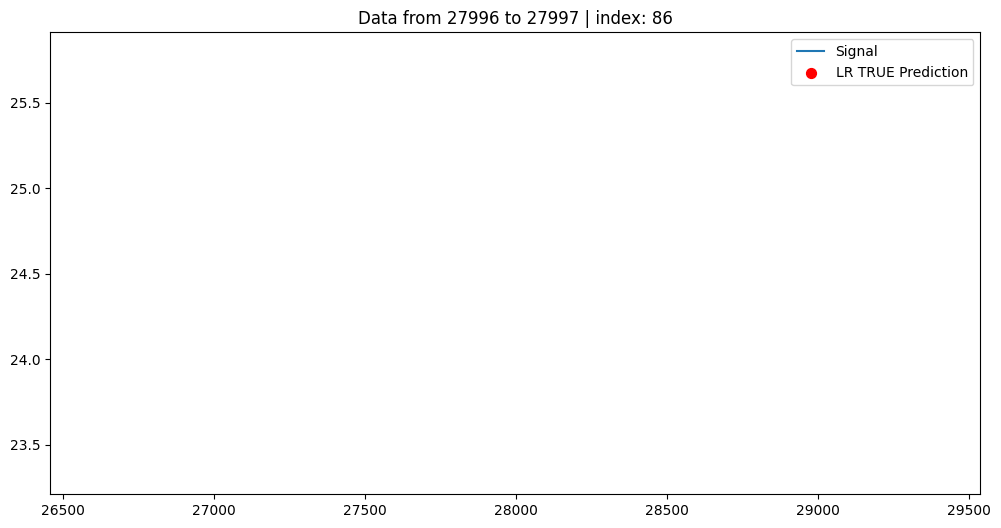

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


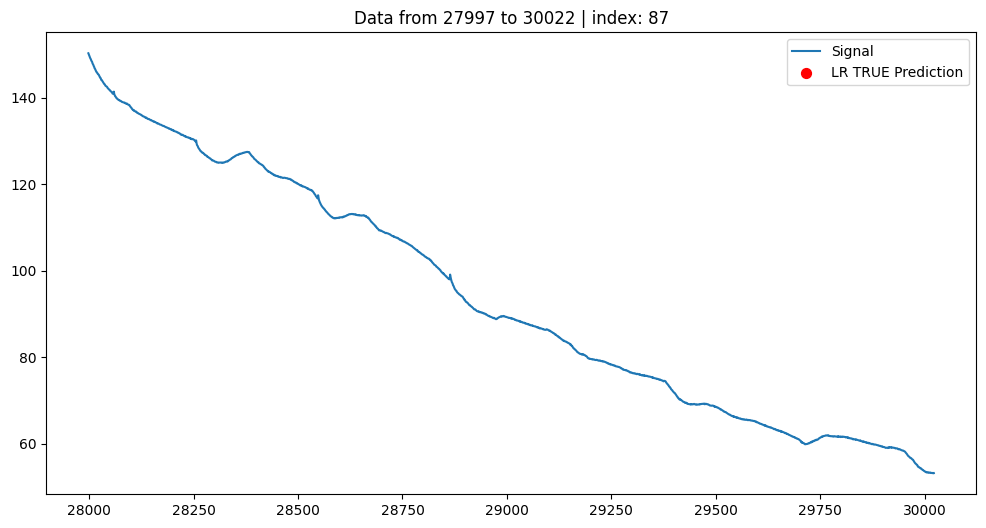

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


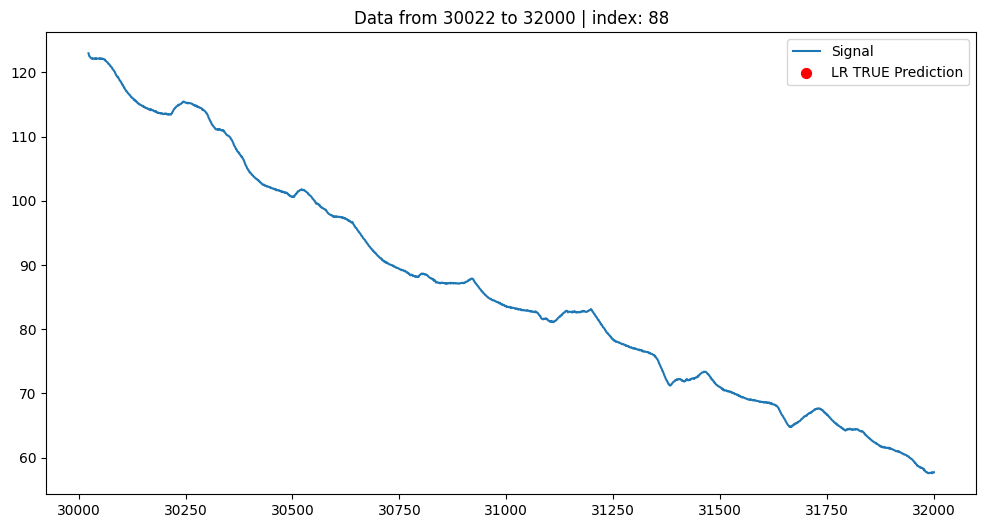

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


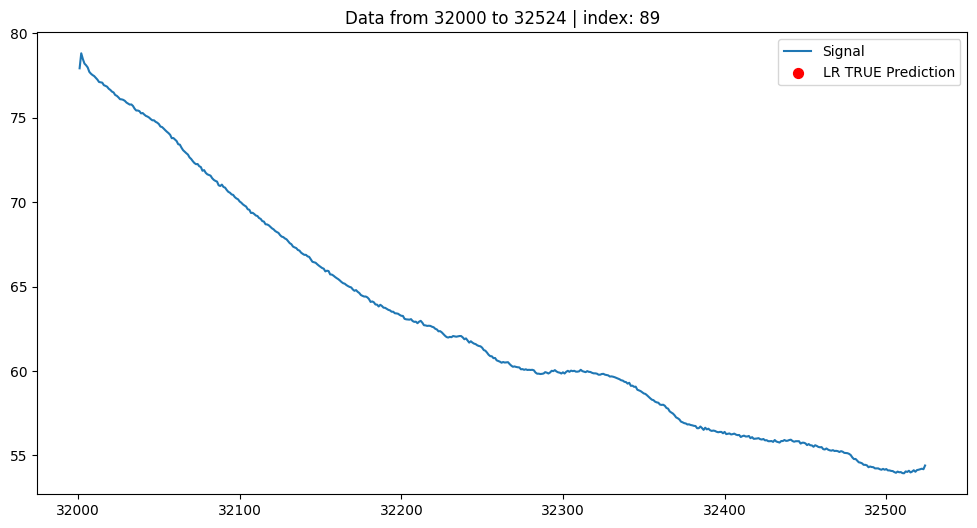

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


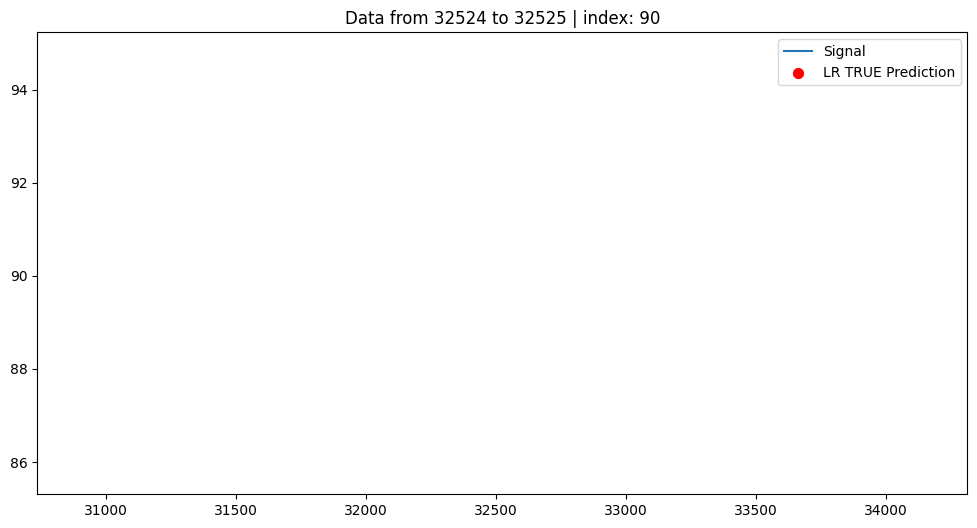

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


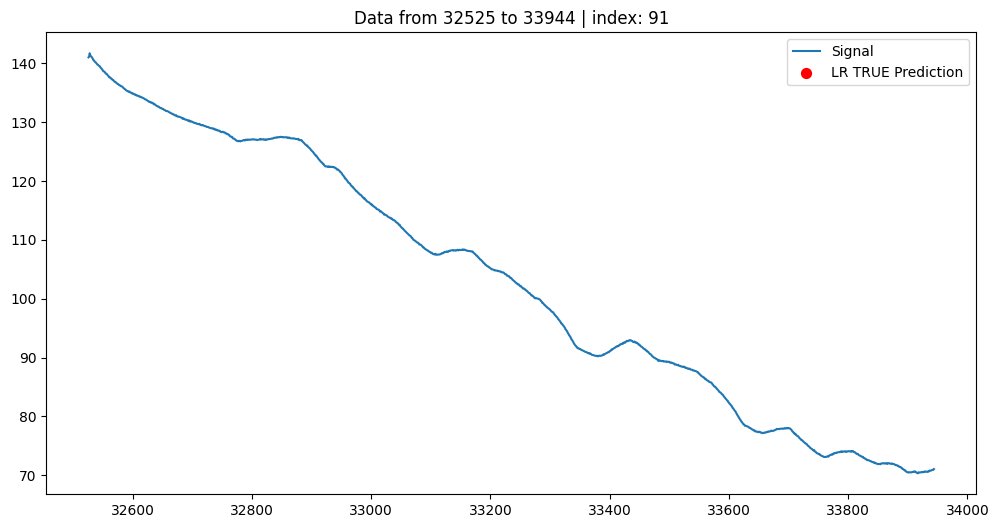

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


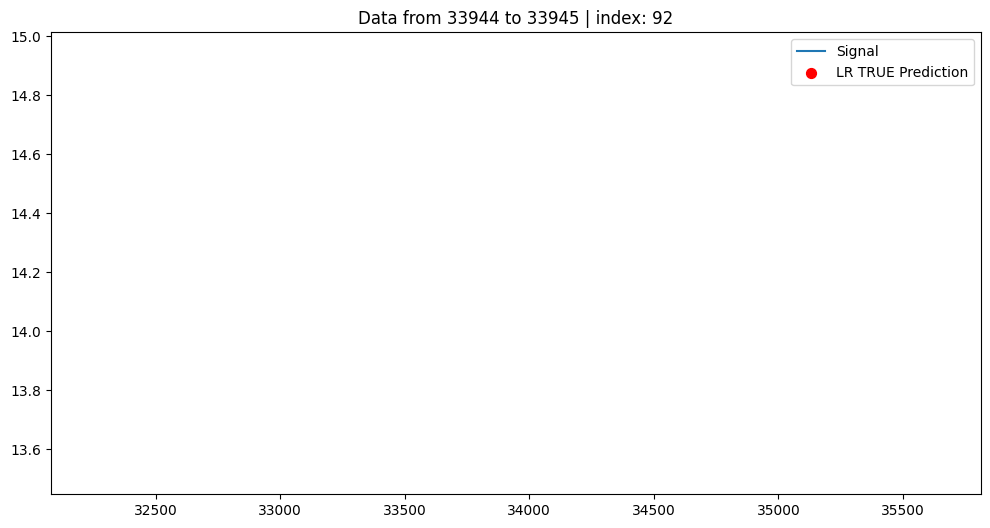

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


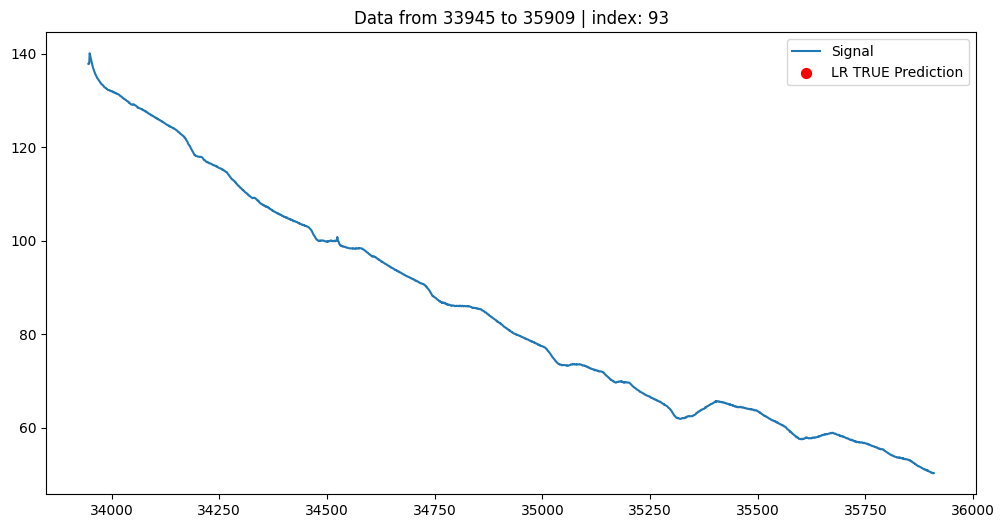

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


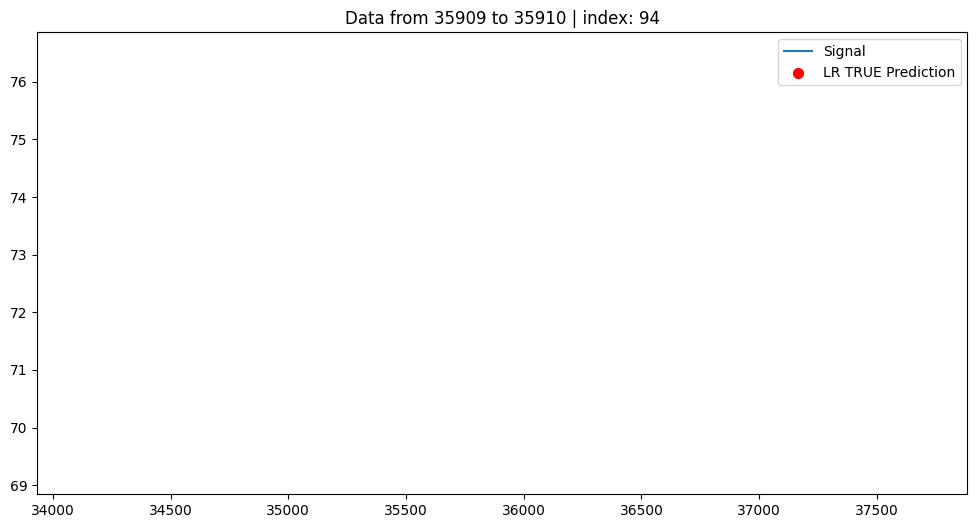

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


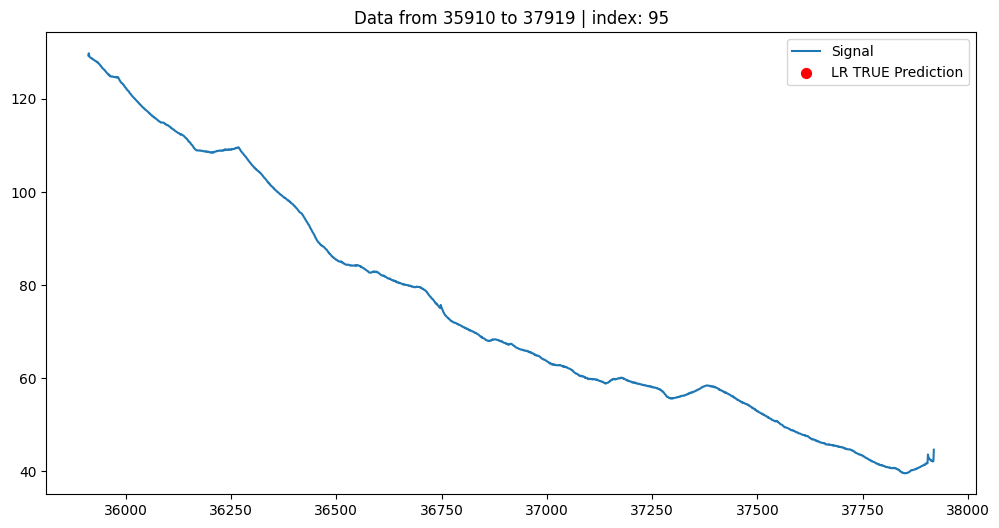

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


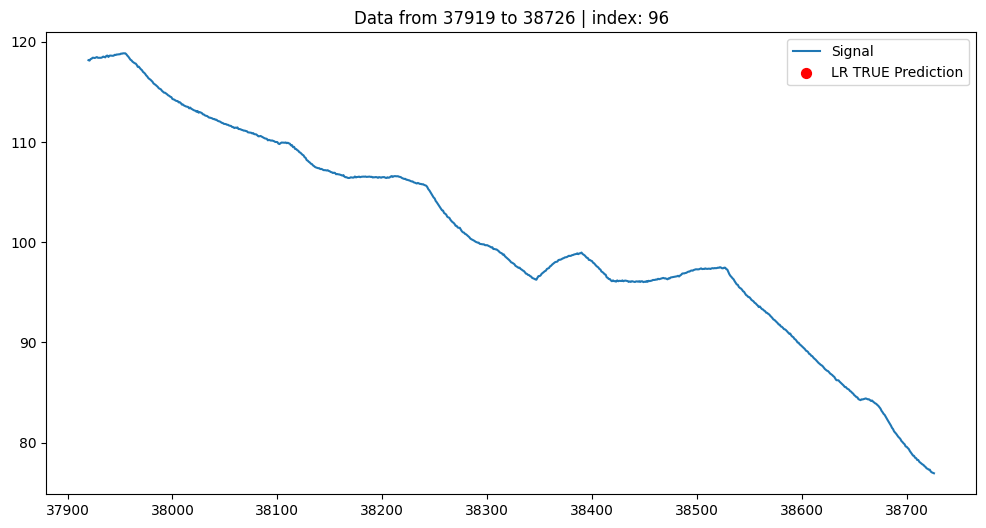

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


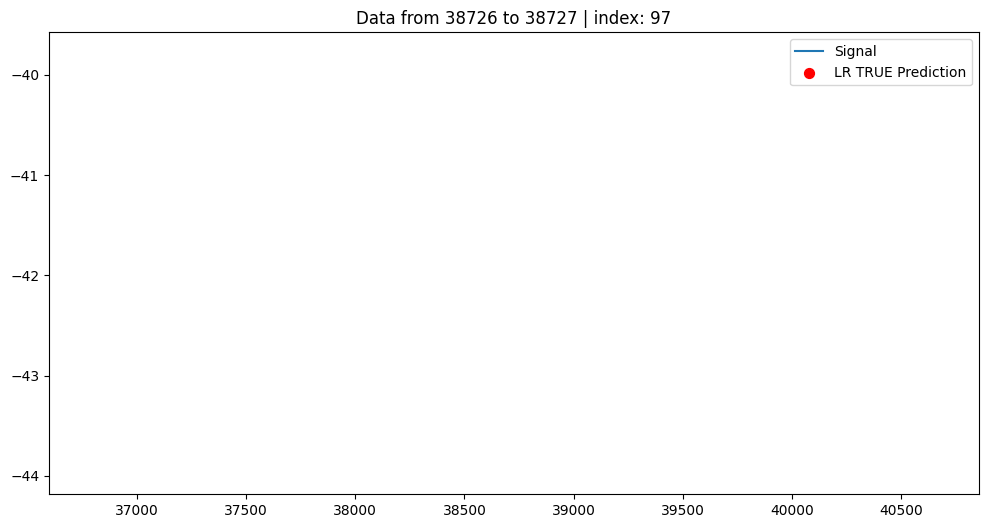

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


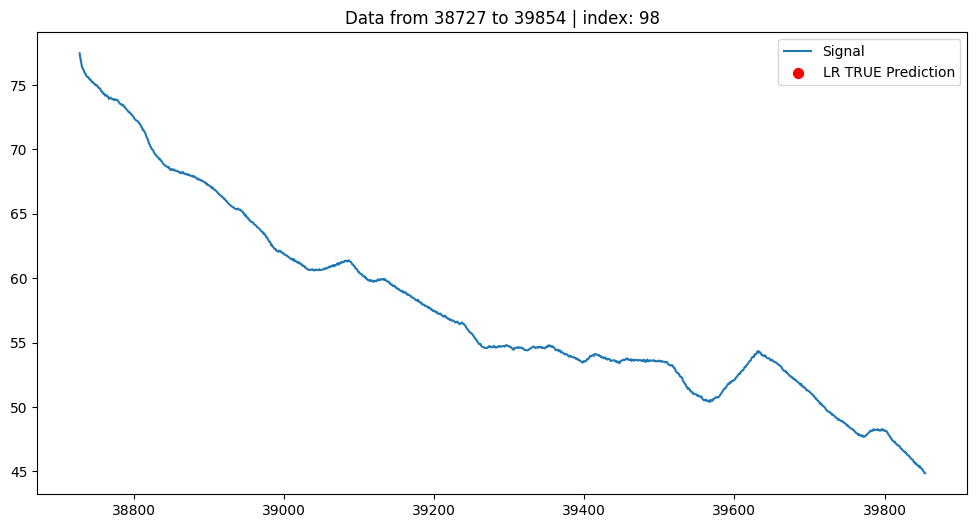

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


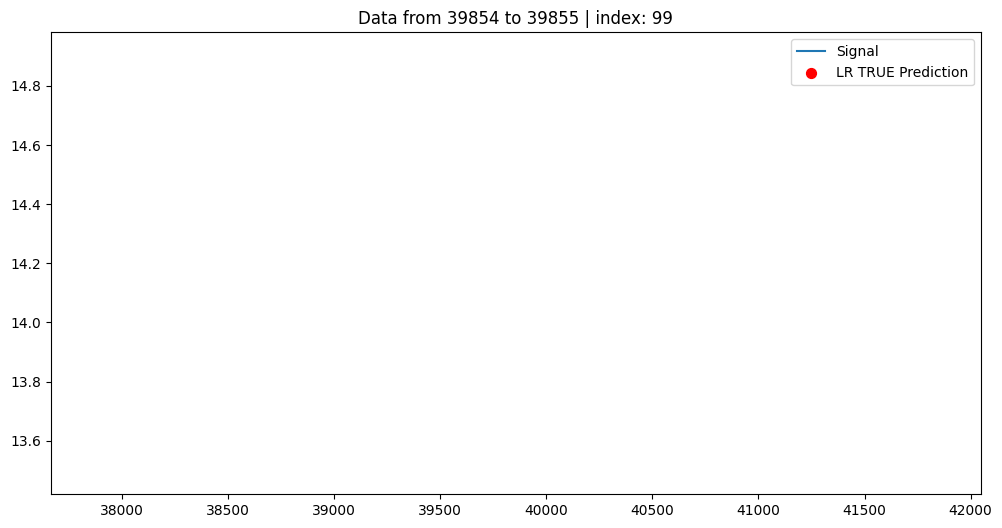

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


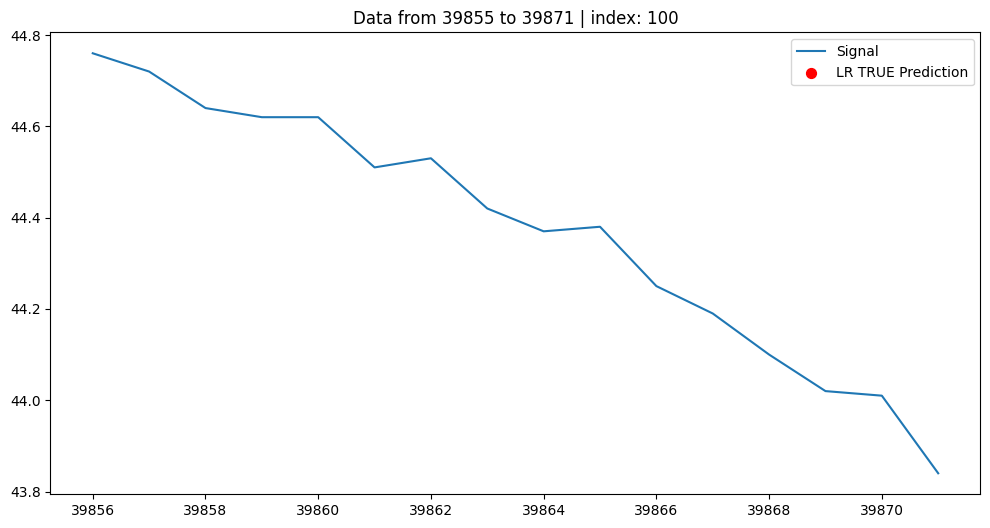

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


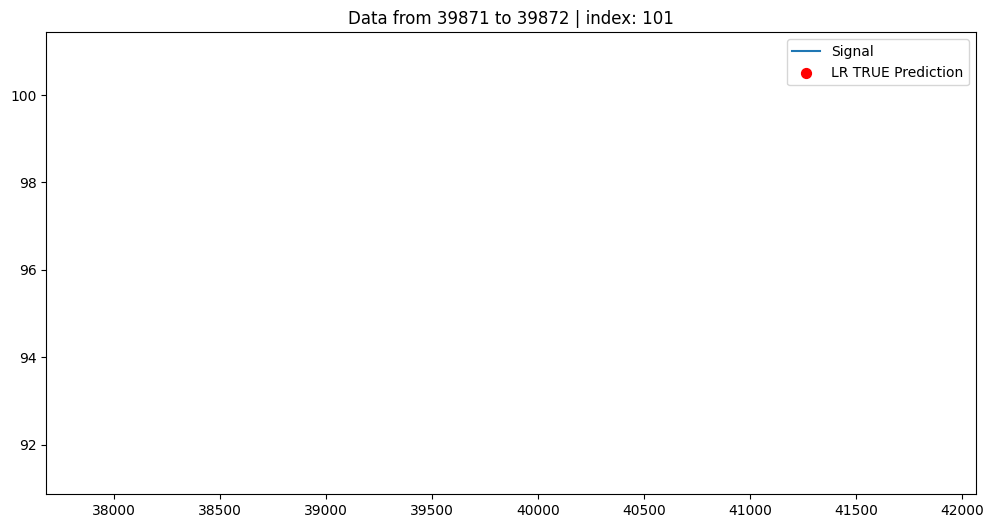

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


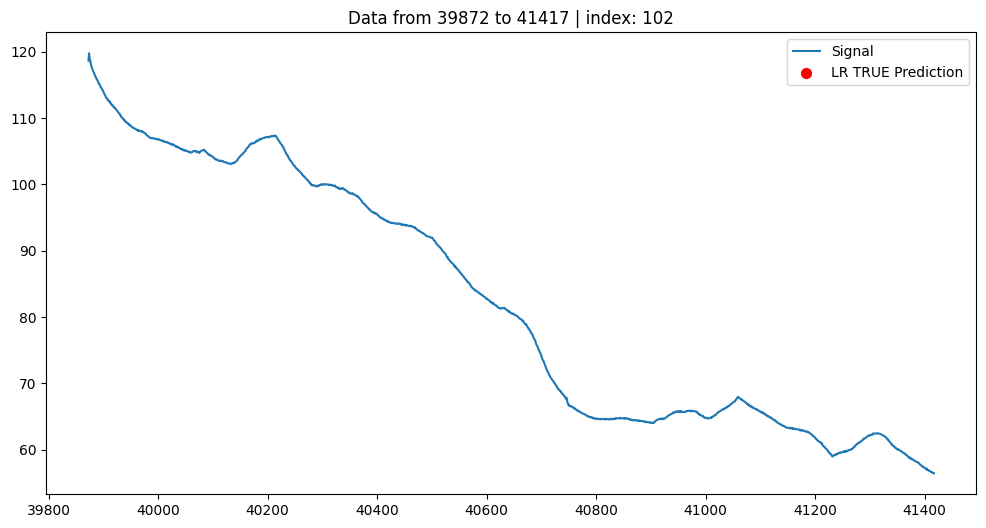

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


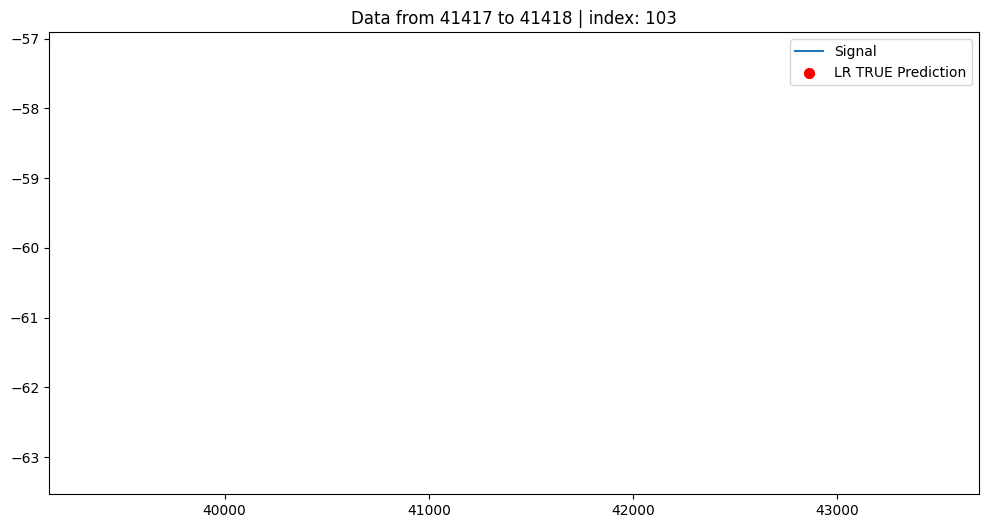

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


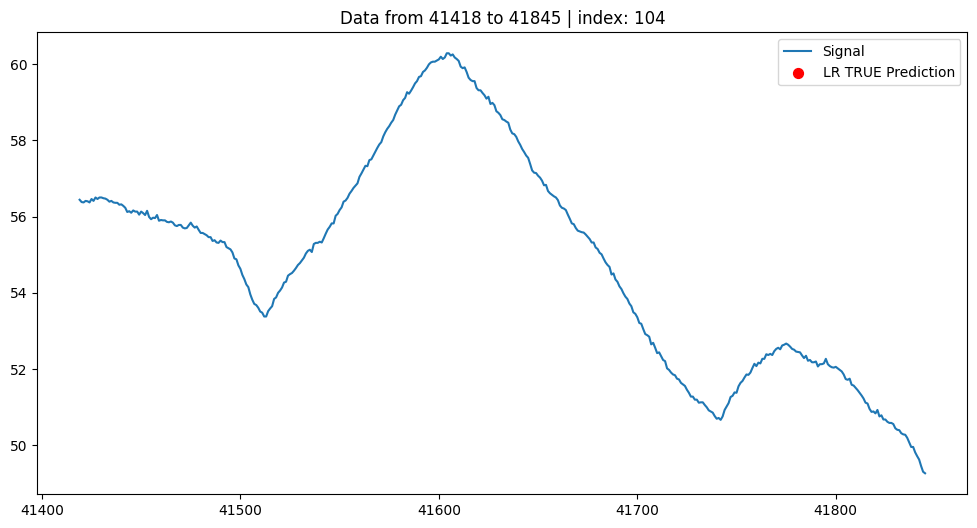

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


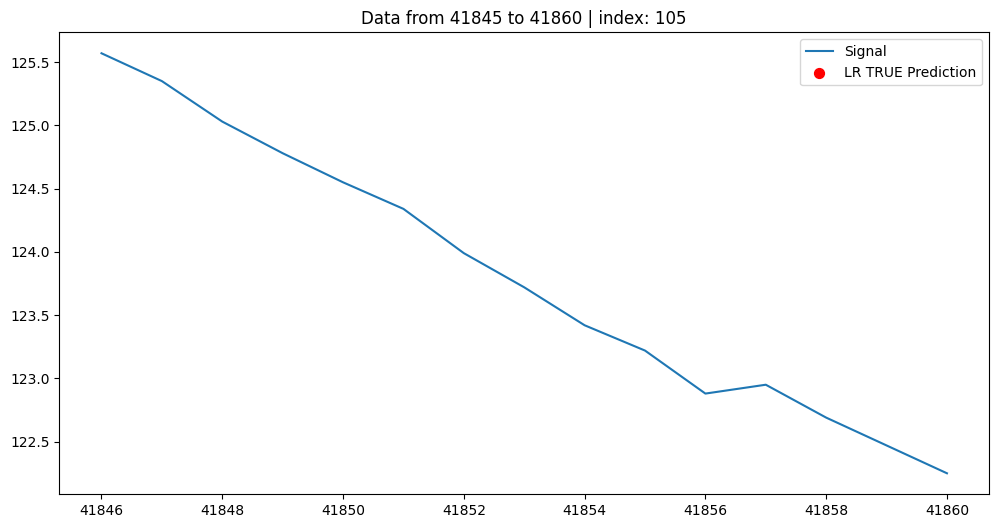

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


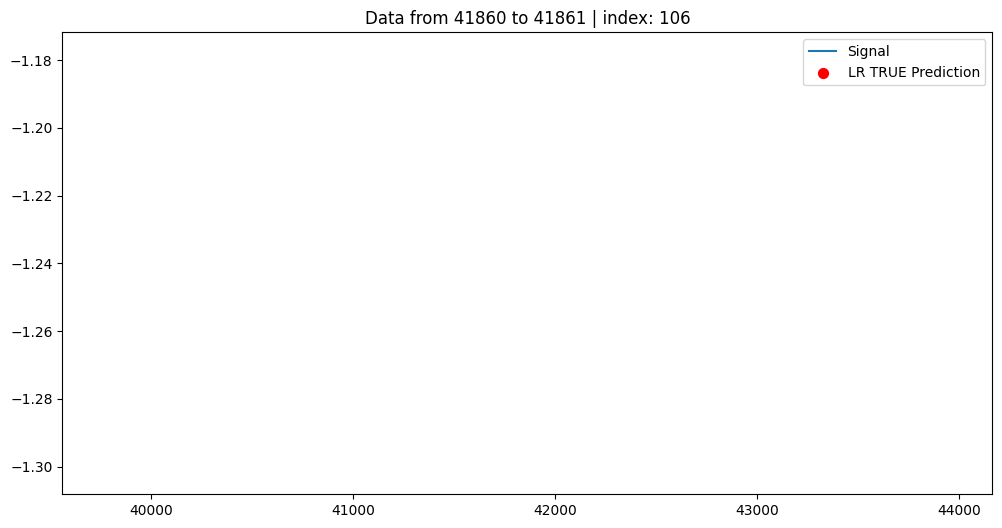

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


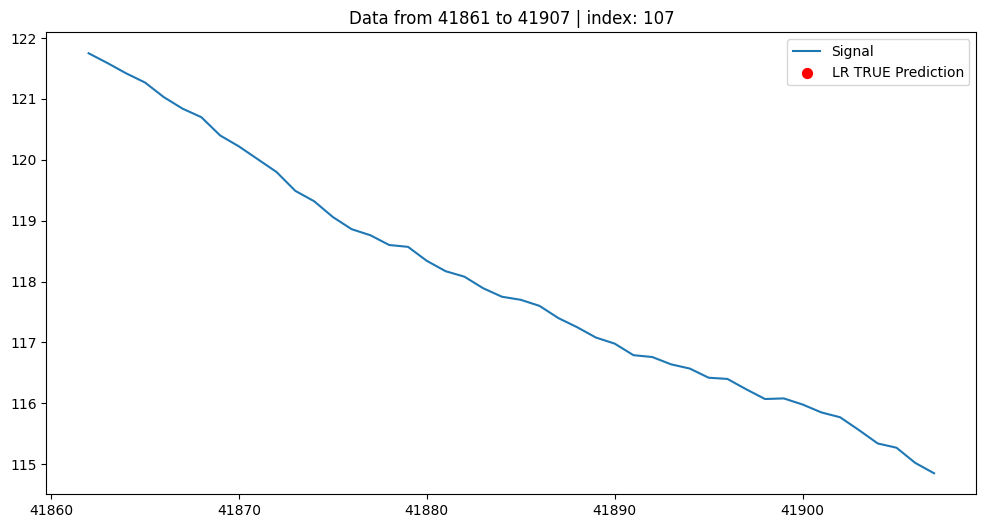

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


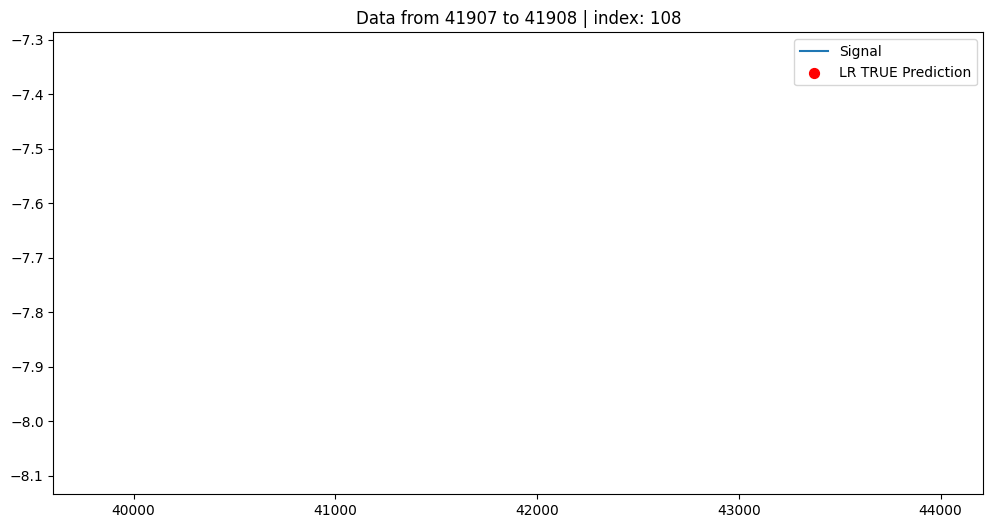

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


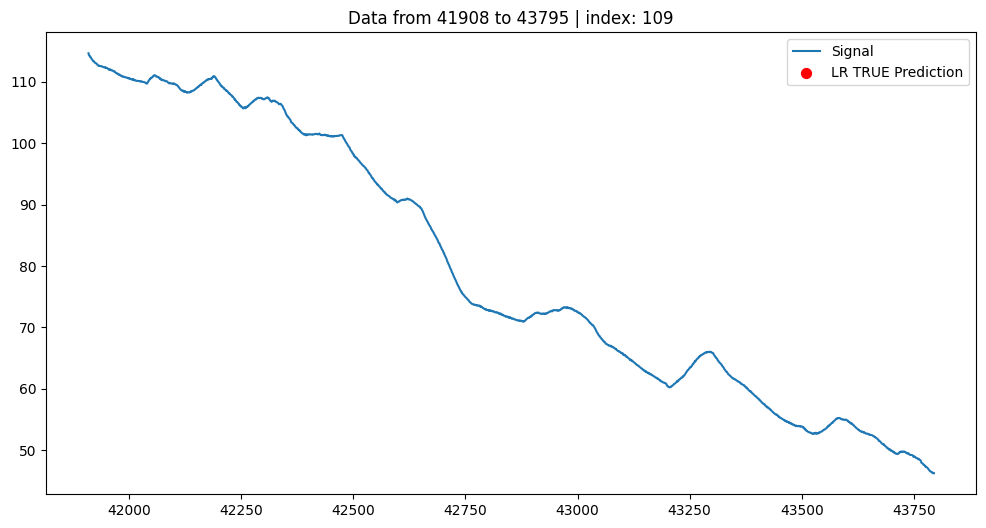

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


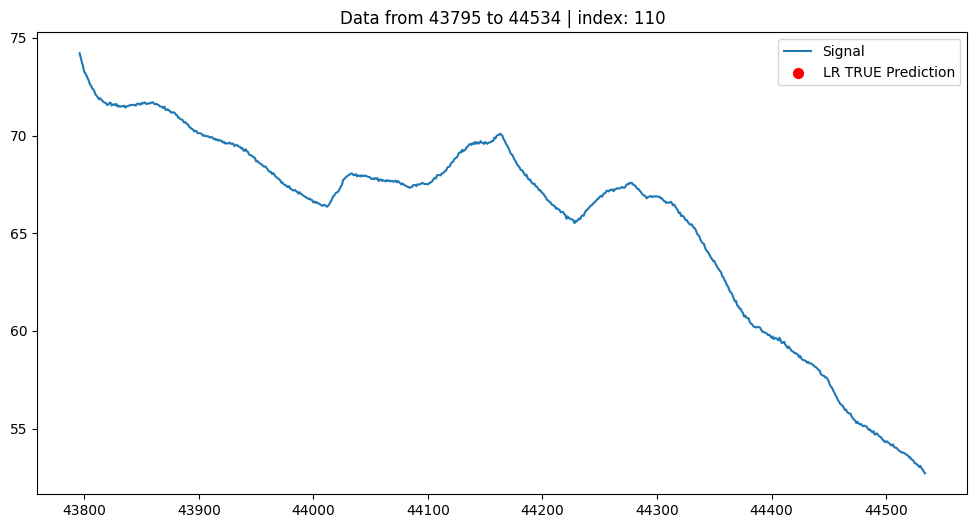

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


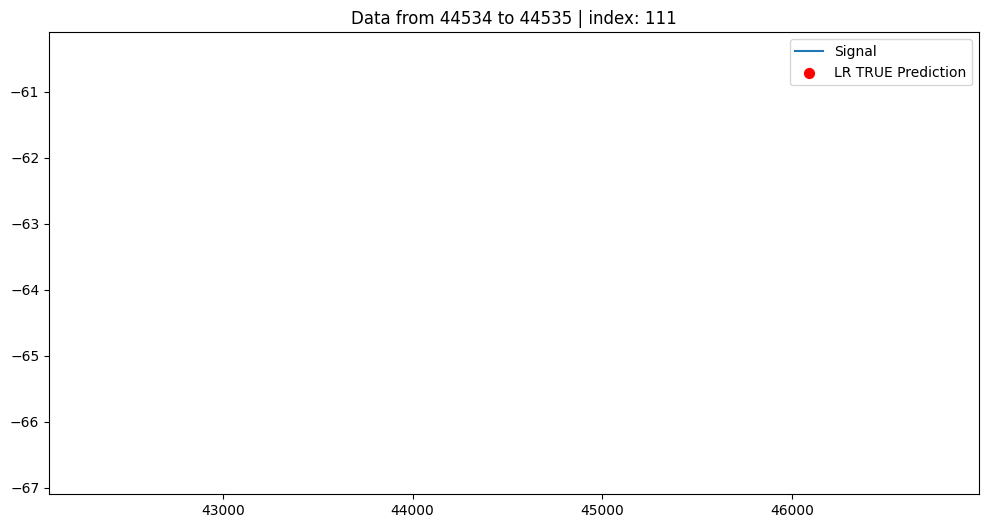

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


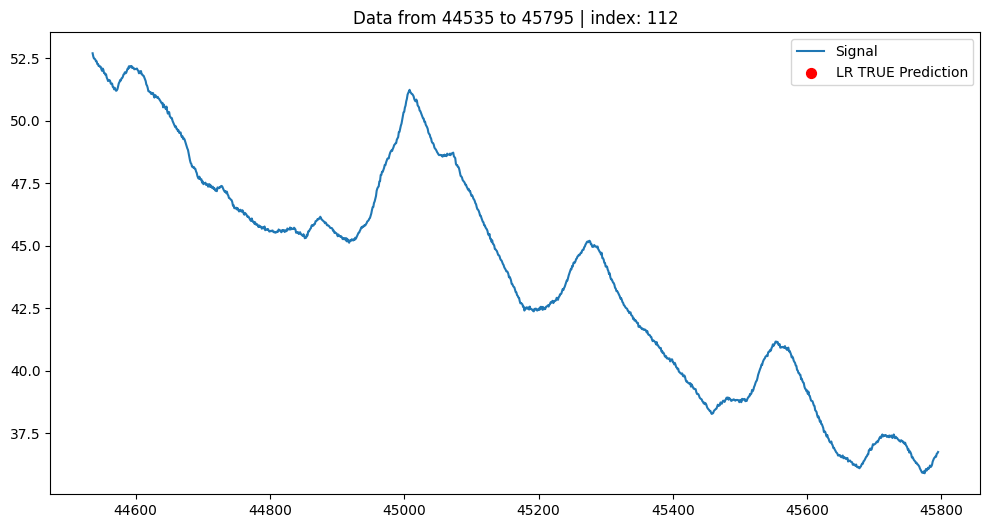

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


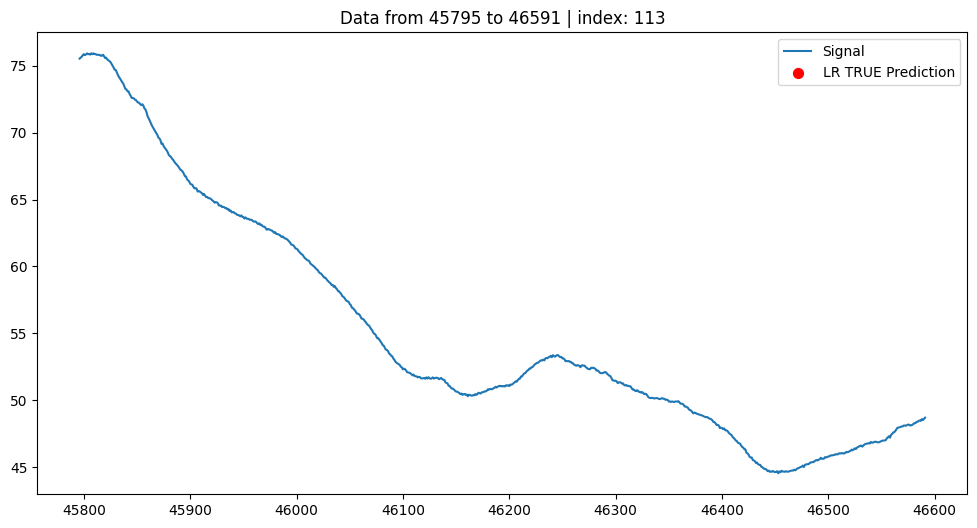

In [2]:
# This code predicts watering points using previously trained logistic regression model and displays its predictions.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

data = pd.read_csv("feeds.csv")

size = data.shape[0]
jump_val = 10
jump_points = []

field = "field1"

# Detect jump segments
for i in range(size - 1):
    loc = data[field].iloc[i]
    nxt = data[field].iloc[i + 1]
    if abs(loc - nxt) > jump_val:
        jump_points.append(i + 1)

index = 0

for start, end in zip(jump_points[:-1], jump_points[1:]):
    loc_data = data.iloc[start:end]

    index += 1

    # Plot the base data
    plt.figure(figsize=(12, 6))
    plt.plot(loc_data["entry_id"], loc_data[field], label="Signal")
    plt.title(f"Data from {start} to {end} | index: {index}")

    # -------------------------------
    # Logistic Regression Prediction
    # -------------------------------
    # Prepare feature matrix.
    X_features = loc_data[[field]].values

    # Predict probabilities or classes
    preds = LR.predict(X_features)
    #print(preds)

    # Plot red dots for predicted TRUE samples
    true_points = loc_data[preds == 1]

    plt.scatter(
        true_points["entry_id"],
        true_points[field],
        color="red",
        s=50,
        label="LR TRUE Prediction"
    )

    plt.legend()
    plt.show()
